In [1]:
# 셀 1: 프로젝트 전체에서 사용할 라이브러리를 불러옵니다.
# - dataclass와 typing: 격자 원소의 자료형과 함수 타입을 명확하게 정의합니다.
# - NumPy, SciPy, Matplotlib, NetworkX, pandas: 수치 계산과 시각화를 준비합니다.
# - Qiskit과 Qiskit Aer: Pauli 연산자와 양자 회로를 정의하고 검증합니다.

from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Iterator, Literal, Sequence, TypedDict

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import qiskit
import qiskit_aer
from scipy import sparse
from qiskit import QuantumCircuit
from qiskit.quantum_info import Pauli, SparsePauliOp, StabilizerState
from qiskit_aer import AerSimulator


L=6: 72 data qubits on a periodic 6 x 6 lattice


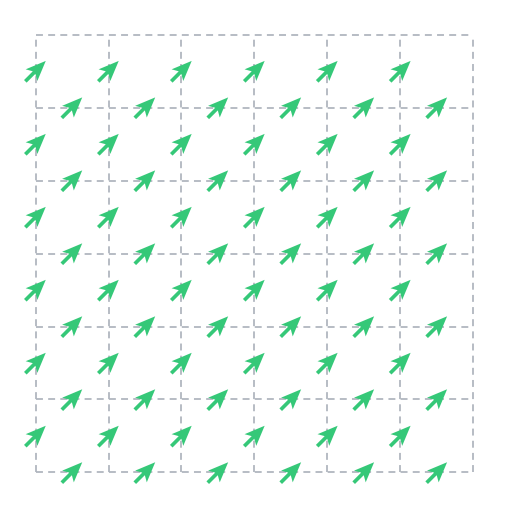

In [2]:
# 셀 2: 주기적 경계조건을 갖는 L x L toric lattice를 정의하고 그립니다.
# - EdgeId, PlaquetteId, StarId: edge, plaquette, star의 좌표 식별자를 정의합니다.
# - ToricLattice: L^2개의 star와 plaquette, 2L^2개의 edge data qubit을 생성합니다.
# - 좌표에 modulo L을 적용하여 격자의 왼쪽-오른쪽과 위-아래를 연결합니다.
# - plot_toric_lattice: check는 숨기고 edge에 놓인 data qubit 위치만 표시합니다.
# - 실행 시 L을 입력받고 격자 크기와 data qubit 개수를 검증합니다.

@dataclass(frozen=True, order=True)
class EdgeId:
    orientation: Literal["H", "V"]
    x: int
    y: int


@dataclass(frozen=True, order=True)
class PlaquetteId:
    x: int
    y: int


@dataclass(frozen=True, order=True)
class StarId:
    x: int
    y: int


@dataclass(frozen=True)
class ToricLattice:
    L: int

    def __post_init__(self) -> None:
        if self.L < 2:
            raise ValueError("L must be an integer greater than or equal to 2.")

    @property
    def stars(self) -> tuple[StarId, ...]:
        return tuple(StarId(x, y) for y in range(self.L) for x in range(self.L))

    @property
    def plaquettes(self) -> tuple[PlaquetteId, ...]:
        return tuple(PlaquetteId(x, y) for y in range(self.L) for x in range(self.L))

    @property
    def edges(self) -> tuple[EdgeId, ...]:
        horizontal = tuple(EdgeId("H", x, y) for y in range(self.L) for x in range(self.L))
        vertical = tuple(EdgeId("V", x, y) for y in range(self.L) for x in range(self.L))
        return horizontal + vertical

    def edge_stars(self, edge: EdgeId) -> tuple[StarId, StarId]:
        x, y, L = edge.x, edge.y, self.L
        if edge.orientation == "H":
            return StarId(x, y), StarId((x + 1) % L, y)
        return StarId(x, y), StarId(x, (y + 1) % L)


def plot_toric_lattice(lattice: ToricLattice) -> None:
    L = lattice.L
    figure_size = min(10, max(5, 0.75 * L))
    fig, ax = plt.subplots(figsize=(figure_size, figure_size))

    grid_style = {
        "color": "#aeb4bd",
        "linestyle": (0, (4, 3)),
        "linewidth": 1.25,
        "zorder": 1,
    }
    for coordinate in range(L + 1):
        ax.plot([0, L], [coordinate, coordinate], **grid_style)
        ax.plot([coordinate, coordinate], [0, L], **grid_style)

    edge_midpoints = []
    for edge in lattice.edges:
        if edge.orientation == "H":
            edge_midpoints.append((edge.x + 0.5, edge.y))
        else:
            edge_midpoints.append((edge.x, edge.y + 0.5))

    edge_x, edge_y = np.asarray(edge_midpoints).T
    arrow_dx = np.full(len(edge_midpoints), 0.28)
    arrow_dy = np.full(len(edge_midpoints), 0.28)
    ax.quiver(
        edge_x,
        edge_y,
        arrow_dx,
        arrow_dy,
        angles="xy",
        scale_units="xy",
        scale=1,
        pivot="mid",
        color="#35c878",
        width=0.0075,
        headwidth=4.5,
        headlength=5.5,
        headaxislength=4.5,
        zorder=3,
    )

    ax.set_xlim(-0.35, L + 0.35)
    ax.set_ylim(-0.35, L + 0.35)
    ax.set_aspect("equal")
    ax.axis("off")
    fig.tight_layout(pad=0.4)
    plt.show()


L = int(input("Enter lattice size L (integer >= 2): "))
lattice = ToricLattice(L)

assert len(lattice.stars) == L**2
assert len(lattice.plaquettes) == L**2
assert len(lattice.edges) == 2 * L**2
assert len(set(lattice.edges)) == len(lattice.edges)

print(f"L={L}: {len(lattice.edges)} data qubits on a periodic {L} x {L} lattice")
plot_toric_lattice(lattice)


In [3]:
# 셀 3: toric code의 stabilizer와 logical Pauli 연산자를 정의합니다.
# - plaquette_boundary_edges와 star_incident_edges: 각 check가 작용하는 4개 edge를 찾습니다.
# - pauli_from_edges: edge support를 Qiskit Pauli 문자열로 변환합니다.
# - plaquette에는 Z stabilizer, star에는 X stabilizer를 하나씩 생성합니다.
# - 토러스를 감는 두 방향의 logical X/Z 연산자를 정의하고 교환 관계를 검증합니다.

def plaquette_boundary_edges(
    lattice: ToricLattice, plaquette: PlaquetteId
) -> tuple[EdgeId, EdgeId, EdgeId, EdgeId]:
    x, y, L = plaquette.x, plaquette.y, lattice.L
    return (
        EdgeId("H", x, y),
        EdgeId("V", (x + 1) % L, y),
        EdgeId("H", x, (y + 1) % L),
        EdgeId("V", x, y),
    )


def star_incident_edges(
    lattice: ToricLattice, star: StarId
) -> tuple[EdgeId, EdgeId, EdgeId, EdgeId]:
    x, y, L = star.x, star.y, lattice.L
    return (
        EdgeId("H", x, y),
        EdgeId("V", x, y),
        EdgeId("H", (x - 1) % L, y),
        EdgeId("V", x, (y - 1) % L),
    )


def pauli_from_edges(
    support: Iterable[EdgeId],
    pauli_type: Literal["X", "Z"],
    edge_to_qiskit_index: dict[EdgeId, int],
) -> Pauli:
    support = tuple(support)
    if len(set(support)) != len(support):
        raise ValueError("Pauli support contains duplicate edges.")

    num_qubits = len(edge_to_qiskit_index)
    label = ["I"] * num_qubits
    for edge in support:
        qubit_index = edge_to_qiskit_index[edge]
        # Qiskit labels place qubit 0 at the rightmost character.
        label[num_qubits - 1 - qubit_index] = pauli_type
    return Pauli("".join(label))


qiskit_index_to_edge = tuple(lattice.edges)
edge_to_qiskit_index = {
    edge: index for index, edge in enumerate(qiskit_index_to_edge)
}
num_data_qubits = len(qiskit_index_to_edge)

plaquette_supports = {
    plaquette: plaquette_boundary_edges(lattice, plaquette)
    for plaquette in lattice.plaquettes
}
star_supports = {
    star: star_incident_edges(lattice, star)
    for star in lattice.stars
}

plaquette_operators = {
    plaquette: pauli_from_edges(support, "Z", edge_to_qiskit_index)
    for plaquette, support in plaquette_supports.items()
}
star_operators = {
    star: pauli_from_edges(support, "X", edge_to_qiskit_index)
    for star, support in star_supports.items()
}

# Z_x and Z_y wind along the two primal directions.
# X_x and X_y are the corresponding conjugate dual cycles.
logical_supports = {
    "logical_Z_x": tuple(EdgeId("H", x, 0) for x in range(L)),
    "logical_X_x": tuple(EdgeId("H", 0, y) for y in range(L)),
    "logical_Z_y": tuple(EdgeId("V", 0, y) for y in range(L)),
    "logical_X_y": tuple(EdgeId("V", x, 0) for x in range(L)),
}

logical_Z_x = pauli_from_edges(
    logical_supports["logical_Z_x"], "Z", edge_to_qiskit_index
)
logical_X_x = pauli_from_edges(
    logical_supports["logical_X_x"], "X", edge_to_qiskit_index
)
logical_Z_y = pauli_from_edges(
    logical_supports["logical_Z_y"], "Z", edge_to_qiskit_index
)
logical_X_y = pauli_from_edges(
    logical_supports["logical_X_y"], "X", edge_to_qiskit_index
)
logical_operators = {
    "logical_X_x": logical_X_x,
    "logical_Z_x": logical_Z_x,
    "logical_X_y": logical_X_y,
    "logical_Z_y": logical_Z_y,
}

assert all(len(set(support)) == 4 for support in plaquette_supports.values())
assert all(len(set(support)) == 4 for support in star_supports.values())
assert all(
    plaquette.commutes(star)
    for plaquette in plaquette_operators.values()
    for star in star_operators.values()
)
for logical in logical_operators.values():
    assert all(logical.commutes(operator) for operator in plaquette_operators.values())
    assert all(logical.commutes(operator) for operator in star_operators.values())

assert not logical_X_x.commutes(logical_Z_x)
assert not logical_X_y.commutes(logical_Z_y)
assert logical_X_x.commutes(logical_Z_y)
assert logical_X_y.commutes(logical_Z_x)

print(
    f"Defined {len(plaquette_operators)} plaquette Z operators and "
    f"{len(star_operators)} star X operators on {num_data_qubits} data qubits."
)
print("Verified logical pairs: (X_x, Z_x) and (X_y, Z_y).")


Defined 36 plaquette Z operators and 36 star X operators on 72 data qubits.
Verified logical pairs: (X_x, Z_x) and (X_y, Z_y).


In [4]:
# 셀 4: stabilizer의 독립성 및 toric code가 encode하는 logical qubit 수를 검증합니다.
# - binary_support_matrix: stabilizer support를 GF(2) 이진 행렬로 변환합니다.
# - gf2_rank: mod 2 가우스 소거법으로 독립 stabilizer의 개수를 계산합니다.
# - pauli_product: 모든 plaquette 또는 star 연산자의 전체 곱을 계산합니다.
# - 각 rank가 L^2 - 1이고 전체 곱이 identity이며 k=2임을 확인합니다.

def binary_support_matrix(
    supports: Iterable[Iterable[EdgeId]],
    edge_to_index: dict[EdgeId, int],
) -> np.ndarray:
    support_rows = [tuple(support) for support in supports]
    matrix = np.zeros((len(support_rows), len(edge_to_index)), dtype=np.uint8)
    for row, support in enumerate(support_rows):
        for edge in support:
            matrix[row, edge_to_index[edge]] = 1
    return matrix


def gf2_rank(matrix: np.ndarray) -> int:
    reduced = np.asarray(matrix, dtype=np.uint8).copy() % 2
    num_rows, num_columns = reduced.shape
    rank = 0

    for column in range(num_columns):
        pivot_candidates = np.flatnonzero(reduced[rank:, column])
        if pivot_candidates.size == 0:
            continue

        pivot_row = rank + int(pivot_candidates[0])
        if pivot_row != rank:
            reduced[[rank, pivot_row]] = reduced[[pivot_row, rank]]

        for row in range(num_rows):
            if row != rank and reduced[row, column]:
                reduced[row] ^= reduced[rank]

        rank += 1
        if rank == num_rows:
            break

    return rank


def pauli_product(operators: Iterable[Pauli], num_qubits: int) -> Pauli:
    product = Pauli("I" * num_qubits)
    for operator in operators:
        product = product.compose(operator)
    return product


plaquette_check_matrix = binary_support_matrix(
    plaquette_supports.values(), edge_to_qiskit_index
)
star_check_matrix = binary_support_matrix(
    star_supports.values(), edge_to_qiskit_index
)

plaquette_rank = gf2_rank(plaquette_check_matrix)
star_rank = gf2_rank(star_check_matrix)

# Binary symplectic column order is [X | Z].
zero_block = np.zeros_like(plaquette_check_matrix)
stabilizer_symplectic_matrix = np.block(
    [
        [zero_block, plaquette_check_matrix],
        [star_check_matrix, zero_block],
    ]
).astype(np.uint8)
stabilizer_rank = gf2_rank(stabilizer_symplectic_matrix)
num_encoded_logical_qubits = num_data_qubits - stabilizer_rank

identity_pauli = Pauli("I" * num_data_qubits)
plaquette_global_product = pauli_product(
    plaquette_operators.values(), num_data_qubits
)
star_global_product = pauli_product(star_operators.values(), num_data_qubits)

assert np.all(np.bitwise_xor.reduce(plaquette_check_matrix, axis=0) == 0)
assert np.all(np.bitwise_xor.reduce(star_check_matrix, axis=0) == 0)
assert plaquette_global_product == identity_pauli
assert star_global_product == identity_pauli
assert plaquette_rank == L**2 - 1
assert star_rank == L**2 - 1
assert stabilizer_rank == 2 * L**2 - 2
assert num_encoded_logical_qubits == 2

print(
    f"GF(2) ranks: plaquette={plaquette_rank}, star={star_rank}, "
    f"total={stabilizer_rank}."
)
print(
    "Global plaquette/star products are identity; "
    f"the code encodes k={num_encoded_logical_qubits} logical qubits."
)


GF(2) ranks: plaquette=35, star=35, total=70.
Global plaquette/star products are identity; the code encodes k=2 logical qubits.


In [5]:
# 셀 5: edge, star, plaquette 사이의 양방향 연결 관계를 구성하고 검증합니다.
# - star_to_edges와 plaquette_to_edges: 각 check가 포함하는 4개 edge를 저장합니다.
# - edge_to_stars와 edge_to_plaquettes: 각 edge에 인접한 2개 check를 저장합니다.
# - 모든 연결 관계가 서로 일치하는지와 check별 edge 개수가 정확한지 검사합니다.
# - 경계 edge가 modulo L에 의해 반대쪽 check로 연결되는지도 명시적으로 검사합니다.

def edge_incident_plaquettes(
    lattice: ToricLattice, edge: EdgeId
) -> tuple[PlaquetteId, PlaquetteId]:
    x, y, L = edge.x, edge.y, lattice.L
    if edge.orientation == "H":
        return PlaquetteId(x, y), PlaquetteId(x, (y - 1) % L)
    if edge.orientation == "V":
        return PlaquetteId(x, y), PlaquetteId((x - 1) % L, y)
    raise ValueError(f"Unknown edge orientation: {edge.orientation}")


star_to_edges = {star: tuple(edges) for star, edges in star_supports.items()}
plaquette_to_edges = {
    plaquette: tuple(edges) for plaquette, edges in plaquette_supports.items()
}
edge_to_stars = {edge: lattice.edge_stars(edge) for edge in lattice.edges}
edge_to_plaquettes = {
    edge: edge_incident_plaquettes(lattice, edge) for edge in lattice.edges
}

assert set(edge_to_stars) == set(lattice.edges), "Missing edge-to-star entries."
assert set(edge_to_plaquettes) == set(lattice.edges), (
    "Missing edge-to-plaquette entries."
)
assert set(star_to_edges) == set(lattice.stars), "Missing star-to-edge entries."
assert set(plaquette_to_edges) == set(lattice.plaquettes), (
    "Missing plaquette-to-edge entries."
)

for edge in lattice.edges:
    adjacent_stars = edge_to_stars[edge]
    adjacent_plaquettes = edge_to_plaquettes[edge]
    assert len(adjacent_stars) == 2 and len(set(adjacent_stars)) == 2, (
        f"{edge} must touch exactly two distinct stars: {adjacent_stars}"
    )
    assert len(adjacent_plaquettes) == 2 and len(set(adjacent_plaquettes)) == 2, (
        f"{edge} must touch exactly two distinct plaquettes: {adjacent_plaquettes}"
    )

for star, incident_edges in star_to_edges.items():
    assert len(incident_edges) == 4 and len(set(incident_edges)) == 4, (
        f"{star} must touch exactly four distinct edges: {incident_edges}"
    )
    for edge in incident_edges:
        assert star in edge_to_stars[edge], (
            f"Non-reciprocal star incidence: {star} -> {edge}"
        )

for edge, adjacent_stars in edge_to_stars.items():
    for star in adjacent_stars:
        assert edge in star_to_edges[star], (
            f"Non-reciprocal edge incidence: {edge} -> {star}"
        )

for plaquette, boundary_edges in plaquette_to_edges.items():
    assert len(boundary_edges) == 4 and len(set(boundary_edges)) == 4, (
        f"{plaquette} must have four distinct boundary edges: {boundary_edges}"
    )
    for edge in boundary_edges:
        assert plaquette in edge_to_plaquettes[edge], (
            f"Non-reciprocal plaquette incidence: {plaquette} -> {edge}"
        )

for edge, adjacent_plaquettes in edge_to_plaquettes.items():
    for plaquette in adjacent_plaquettes:
        assert edge in plaquette_to_edges[plaquette], (
            f"Non-reciprocal edge incidence: {edge} -> {plaquette}"
        )

for y in range(L):
    horizontal_wrap = EdgeId("H", L - 1, y)
    assert edge_to_stars[horizontal_wrap] == (
        StarId(L - 1, y),
        StarId(0, y),
    ), f"Incorrect horizontal star wrap at y={y}."

    vertical_left_boundary = EdgeId("V", 0, y)
    assert edge_to_plaquettes[vertical_left_boundary] == (
        PlaquetteId(0, y),
        PlaquetteId(L - 1, y),
    ), f"Incorrect horizontal plaquette wrap at y={y}."

for x in range(L):
    vertical_wrap = EdgeId("V", x, L - 1)
    assert edge_to_stars[vertical_wrap] == (
        StarId(x, L - 1),
        StarId(x, 0),
    ), f"Incorrect vertical star wrap at x={x}."

    horizontal_bottom_boundary = EdgeId("H", x, 0)
    assert edge_to_plaquettes[horizontal_bottom_boundary] == (
        PlaquetteId(x, 0),
        PlaquetteId(x, L - 1),
    ), f"Incorrect vertical plaquette wrap at x={x}."

print(
    f"Verified reciprocal incidence for {len(lattice.edges)} edges, "
    f"{len(lattice.stars)} stars, and {len(lattice.plaquettes)} plaquettes."
)
print("Periodic wrapping is correct in both lattice directions.")


Verified reciprocal incidence for 72 edges, 36 stars, and 36 plaquettes.
Periodic wrapping is correct in both lattice directions.


In [6]:
# 셀 6: data qubit의 X 오류와 그로 인해 발생하는 plaquette syndrome을 정의합니다.
# - x_error_mask_from_edges: 오류 edge 목록을 길이 2L^2의 GF(2) mask로 변환합니다.
# - sample_x_error_mask: 명시적인 난수 생성기로 확률 p_x의 독립 X 오류를 샘플링합니다.
# - calculate_plaquette_syndrome: 오류 edge에 인접한 plaquette syndrome을 토글합니다.
# - 행렬식 H_Z e mod 2 계산과 비교할 수 있는 별도의 syndrome 함수를 정의합니다.
# - syndrome이 1인 defect plaquette를 추출하고 zero-error 상태를 검증합니다.

def x_error_mask_from_edges(
    error_edges: Iterable[EdgeId],
    edge_to_index: dict[EdgeId, int],
) -> np.ndarray:
    """Convert an X-error edge collection to a GF(2) qubit mask."""
    mask = np.zeros(len(edge_to_index), dtype=bool)
    for edge in error_edges:
        mask[edge_to_index[edge]] ^= True
    return mask


def sample_x_error_mask(
    num_qubits: int,
    p_x: float,
    rng: np.random.Generator,
) -> np.ndarray:
    """Sample independent X errors using an explicit random generator."""
    if num_qubits <= 0:
        raise ValueError("num_qubits must be positive.")
    if not 0.0 <= p_x <= 1.0:
        raise ValueError("p_x must lie in [0, 1].")
    return rng.random(num_qubits) < p_x


def calculate_plaquette_syndrome(
    x_error_mask: np.ndarray,
    qiskit_index_to_edge: Sequence[EdgeId],
    edge_to_plaquettes: dict[EdgeId, tuple[PlaquetteId, PlaquetteId]],
    plaquette_ids: Sequence[PlaquetteId],
) -> np.ndarray:
    """Compute the plaquette syndrome by toggling adjacent checks."""
    mask = np.asarray(x_error_mask, dtype=bool)
    expected_shape = (len(qiskit_index_to_edge),)
    if mask.shape != expected_shape:
        raise ValueError(
            f"x_error_mask must have shape {expected_shape}, got {mask.shape}."
        )

    plaquette_to_index = {plaquette: index for index, plaquette in enumerate(plaquette_ids)}
    syndrome = np.zeros(len(plaquette_ids), dtype=bool)
    for qubit_index in np.flatnonzero(mask):
        edge = qiskit_index_to_edge[int(qubit_index)]
        for plaquette in edge_to_plaquettes[edge]:
            syndrome[plaquette_to_index[plaquette]] ^= True
    return syndrome


def calculate_plaquette_syndrome_by_matrix(
    x_error_mask: np.ndarray,
    plaquette_check_matrix: np.ndarray,
) -> np.ndarray:
    """Compute the same syndrome as H_Z e (mod 2)."""
    mask = np.asarray(x_error_mask, dtype=bool)
    expected_shape = (plaquette_check_matrix.shape[1],)
    if mask.shape != expected_shape:
        raise ValueError(
            f"x_error_mask must have shape {expected_shape}, got {mask.shape}."
        )
    return (plaquette_check_matrix @ mask.astype(np.uint8) % 2).astype(bool)


def defect_plaquettes_from_syndrome(
    syndrome: np.ndarray,
    plaquette_ids: Sequence[PlaquetteId],
) -> tuple[PlaquetteId, ...]:
    """Return plaquette IDs whose syndrome bit is one."""
    syndrome_bits = np.asarray(syndrome, dtype=bool)
    expected_shape = (len(plaquette_ids),)
    if syndrome_bits.shape != expected_shape:
        raise ValueError(
            f"syndrome must have shape {expected_shape}, got {syndrome_bits.shape}."
        )
    return tuple(
        plaquette_ids[int(index)] for index in np.flatnonzero(syndrome_bits)
    )


plaquette_ids = tuple(lattice.plaquettes)
zero_x_error_mask = x_error_mask_from_edges((), edge_to_qiskit_index)
zero_syndrome = calculate_plaquette_syndrome(
    zero_x_error_mask,
    qiskit_index_to_edge,
    edge_to_plaquettes,
    plaquette_ids,
)
zero_syndrome_by_matrix = calculate_plaquette_syndrome_by_matrix(
    zero_x_error_mask,
    plaquette_check_matrix,
)
zero_defects = defect_plaquettes_from_syndrome(zero_syndrome, plaquette_ids)

assert np.array_equal(zero_syndrome, zero_syndrome_by_matrix)
assert len(zero_defects) == 0
assert int(zero_syndrome.sum()) % 2 == 0

print("X-error masks and classical plaquette-syndrome functions are ready.")
print("Zero-error syndrome verified: 0 defects.")


X-error masks and classical plaquette-syndrome functions are ready.
Zero-error syndrome verified: 0 defects.


In [7]:
# 셀 7: 대표적인 X-error 패턴을 만들고 plaquette defect가 예상대로 나타나는지 검사합니다.
# - 단일 edge 오류는 서로 인접한 2개의 plaquette defect를 만듭니다.
# - 연결된 열린 error chain은 중간 syndrome이 상쇄되어 양 끝에만 defect를 만듭니다.
# - star 주위를 도는 닫힌 dual loop는 경계가 없으므로 defect를 만들지 않습니다.
# - 고정 seed로 무작위 X 오류를 샘플링하고 두 syndrome 계산법이 일치하는지 확인합니다.

class XErrorAnalysis(TypedDict):
    pattern: str
    mask: np.ndarray
    error_edges: tuple[EdgeId, ...]
    syndrome: np.ndarray
    defects: tuple[PlaquetteId, ...]


def analyze_x_error_mask(
    pattern_name: str,
    x_error_mask: np.ndarray,
) -> XErrorAnalysis:
    """Evaluate one X-error mask with both syndrome implementations."""
    mask = np.asarray(x_error_mask, dtype=bool)
    syndrome_by_incidence = calculate_plaquette_syndrome(
        mask,
        qiskit_index_to_edge,
        edge_to_plaquettes,
        plaquette_ids,
    )
    syndrome_by_matrix = calculate_plaquette_syndrome_by_matrix(
        mask,
        plaquette_check_matrix,
    )
    assert np.array_equal(syndrome_by_incidence, syndrome_by_matrix)

    error_edges = tuple(
        qiskit_index_to_edge[int(index)] for index in np.flatnonzero(mask)
    )
    defects = defect_plaquettes_from_syndrome(
        syndrome_by_incidence,
        plaquette_ids,
    )
    assert len(defects) % 2 == 0

    return {
        "pattern": pattern_name,
        "mask": mask.copy(),
        "error_edges": error_edges,
        "syndrome": syndrome_by_incidence,
        "defects": defects,
    }


single_error_edges = (EdgeId("H", 0, 0),)
single_error_result = analyze_x_error_mask(
    "single edge",
    x_error_mask_from_edges(single_error_edges, edge_to_qiskit_index),
)
expected_single_defects = {
    PlaquetteId(0, 0),
    PlaquetteId(0, (L - 1) % L),
}
assert set(single_error_result["defects"]) == expected_single_defects

open_chain_edges = (EdgeId("H", 0, 0), EdgeId("V", 0, 0))
open_chain_result = analyze_x_error_mask(
    "open chain",
    x_error_mask_from_edges(open_chain_edges, edge_to_qiskit_index),
)
expected_open_chain_defects = {
    PlaquetteId(0, (L - 1) % L),
    PlaquetteId((L - 1) % L, 0),
}
assert set(open_chain_result["defects"]) == expected_open_chain_defects

closed_loop_edges = star_supports[StarId(0, 0)]
closed_loop_result = analyze_x_error_mask(
    "closed dual loop",
    x_error_mask_from_edges(closed_loop_edges, edge_to_qiskit_index),
)
assert len(closed_loop_result["defects"]) == 0

random_seed = 20260716
x_error_probability = 0.20
random_number_generator = np.random.default_rng(random_seed)
random_x_error_mask = sample_x_error_mask(
    num_data_qubits,
    x_error_probability,
    random_number_generator,
)
random_error_result = analyze_x_error_mask(
    "seeded random sample",
    random_x_error_mask,
)

error_pattern_results = [
    single_error_result,
    open_chain_result,
    closed_loop_result,
    random_error_result,
]
error_pattern_summary = pd.DataFrame(
    [
        {
            "pattern": result["pattern"],
            "num_X_errors": int(result["mask"].sum()),
            "num_defects": len(result["defects"]),
        }
        for result in error_pattern_results
    ]
)

print(error_pattern_summary.to_string(index=False))
print(
    f"Random sample parameters: seed={random_seed}, "
    f"p_x={x_error_probability:.2f}."
)


             pattern  num_X_errors  num_defects
         single edge             1            2
          open chain             2            2
    closed dual loop             4            0
seeded random sample            12           16
Random sample parameters: seed=20260716, p_x=0.20.


In [8]:
# 셀 8: 작은 L=2 격자에서 classical plaquette syndrome을 Qiskit 회로로 교차검증합니다.
# - plaquette마다 ancilla 하나를 두고 네 data qubit의 Z parity를 CNOT으로 측정합니다.
# - Qiskit bitstring의 역순 표기를 canonical plaquette 순서로 다시 변환합니다.
# - zero, single edge, open chain, closed dual loop의 측정값을 두 classical 계산과 비교합니다.
# - 이 회로는 소규모 검증 전용이며 확장 가능한 syndrome 계산은 앞 셀의 이진 연산을 사용합니다.

from qiskit import transpile


def build_qiskit_plaquette_syndrome_circuit(
    x_error_mask: np.ndarray,
    edge_to_index: dict[EdgeId, int],
    plaquette_to_edges: dict[PlaquetteId, tuple[EdgeId, ...]],
    plaquette_ids: Sequence[PlaquetteId],
) -> QuantumCircuit:
    """Build an ideal ancilla circuit that measures every Z plaquette."""
    mask = np.asarray(x_error_mask, dtype=bool)
    num_data = len(edge_to_index)
    num_checks = len(plaquette_ids)
    if mask.shape != (num_data,):
        raise ValueError(
            f"x_error_mask must have shape {(num_data,)}, got {mask.shape}."
        )

    circuit = QuantumCircuit(num_data + num_checks, num_checks)
    for data_index in np.flatnonzero(mask):
        circuit.x(int(data_index))

    for plaquette_index, plaquette in enumerate(plaquette_ids):
        ancilla_index = num_data + plaquette_index
        for edge in plaquette_to_edges[plaquette]:
            circuit.cx(edge_to_index[edge], ancilla_index)
        circuit.measure(ancilla_index, plaquette_index)

    return circuit


def syndrome_from_qiskit_count_key(
    count_key: str,
    num_plaquettes: int,
) -> np.ndarray:
    """Decode Qiskit's left-to-right c[n-1]...c[0] count key."""
    bits = count_key.replace(" ", "")
    if len(bits) != num_plaquettes or set(bits) - {"0", "1"}:
        raise ValueError(
            f"Expected a {num_plaquettes}-bit count key, got {count_key!r}."
        )
    return np.asarray(
        [bits[-1 - index] == "1" for index in range(num_plaquettes)],
        dtype=bool,
    )


def run_qiskit_syndrome_circuit(
    circuit: QuantumCircuit,
    num_plaquettes: int,
    simulator: AerSimulator,
    shots: int = 128,
    seed_simulator: int = 20260716,
) -> np.ndarray:
    """Execute an ideal deterministic syndrome circuit and decode its result."""
    if shots <= 0:
        raise ValueError("shots must be positive.")

    compiled_circuit = transpile(circuit, simulator, optimization_level=0)
    result = simulator.run(
        compiled_circuit,
        shots=shots,
        seed_simulator=seed_simulator,
    ).result()
    counts = result.get_counts()
    if len(counts) != 1 or sum(counts.values()) != shots:
        raise AssertionError(f"Expected one deterministic outcome, got {counts}.")

    count_key = next(iter(counts))
    return syndrome_from_qiskit_count_key(count_key, num_plaquettes)


qiskit_validation_L = 2
qiskit_validation_lattice = ToricLattice(qiskit_validation_L)
qiskit_validation_edges = tuple(qiskit_validation_lattice.edges)
qiskit_validation_edge_to_index = {
    edge: index for index, edge in enumerate(qiskit_validation_edges)
}
qiskit_validation_plaquette_ids = tuple(qiskit_validation_lattice.plaquettes)
qiskit_validation_plaquette_to_edges = {
    plaquette: plaquette_boundary_edges(qiskit_validation_lattice, plaquette)
    for plaquette in qiskit_validation_plaquette_ids
}
qiskit_validation_edge_to_plaquettes = {
    edge: edge_incident_plaquettes(qiskit_validation_lattice, edge)
    for edge in qiskit_validation_edges
}
qiskit_validation_check_matrix = binary_support_matrix(
    qiskit_validation_plaquette_to_edges.values(),
    qiskit_validation_edge_to_index,
)

qiskit_validation_patterns = {
    "zero error": (),
    "single edge": (EdgeId("H", 0, 0),),
    "open chain": (EdgeId("H", 0, 0), EdgeId("V", 0, 0)),
    "closed dual loop": star_incident_edges(
        qiskit_validation_lattice,
        StarId(0, 0),
    ),
}
qiskit_validation_simulator = AerSimulator(method="stabilizer")
qiskit_validation_rows = []

for pattern_name, error_edges in qiskit_validation_patterns.items():
    error_mask = x_error_mask_from_edges(
        error_edges,
        qiskit_validation_edge_to_index,
    )
    classical_syndrome = calculate_plaquette_syndrome(
        error_mask,
        qiskit_validation_edges,
        qiskit_validation_edge_to_plaquettes,
        qiskit_validation_plaquette_ids,
    )
    matrix_syndrome = calculate_plaquette_syndrome_by_matrix(
        error_mask,
        qiskit_validation_check_matrix,
    )
    syndrome_circuit = build_qiskit_plaquette_syndrome_circuit(
        error_mask,
        qiskit_validation_edge_to_index,
        qiskit_validation_plaquette_to_edges,
        qiskit_validation_plaquette_ids,
    )
    qiskit_syndrome = run_qiskit_syndrome_circuit(
        syndrome_circuit,
        len(qiskit_validation_plaquette_ids),
        qiskit_validation_simulator,
    )

    assert np.array_equal(classical_syndrome, matrix_syndrome)
    assert np.array_equal(classical_syndrome, qiskit_syndrome)
    defects = defect_plaquettes_from_syndrome(
        qiskit_syndrome,
        qiskit_validation_plaquette_ids,
    )
    qiskit_validation_rows.append(
        {
            "pattern": pattern_name,
            "num_X_errors": int(error_mask.sum()),
            "num_defects": len(defects),
            "classical_equals_qiskit": True,
        }
    )

qiskit_validation_summary = pd.DataFrame(qiskit_validation_rows)
print(qiskit_validation_summary.to_string(index=False))
print("Qiskit L=2 syndrome validation passed for all test patterns.")


         pattern  num_X_errors  num_defects  classical_equals_qiskit
      zero error             0            0                     True
     single edge             1            2                     True
      open chain             2            2                     True
closed dual loop             4            0                     True
Qiskit L=2 syndrome validation passed for all test patterns.


In [9]:
# 셀 9: lossless dual lattice에서 두 plaquette defect 사이의 최단 correction path를 정의합니다.
# - 각 physical edge를 양쪽 plaquette를 잇는 dual edge로 바꾸되 L=2의 평행 edge도 보존합니다.
# - 정렬된 adjacency와 BFS를 사용하여 동률인 최단 경로 중 하나를 항상 결정적으로 선택합니다.
# - 반환값에는 지나간 plaquette 순서와 실제 physical edge 순서를 함께 저장합니다.
# - 주기적 Manhattan 거리, path의 syndrome 경계, wrap-around edge를 교차검증합니다.

from collections import deque


@dataclass(frozen=True)
class PlaquettePath:
    plaquettes: tuple[PlaquetteId, ...]
    edges: tuple[EdgeId, ...]

    def __post_init__(self) -> None:
        if len(self.plaquettes) != len(self.edges) + 1:
            raise ValueError(
                "A path must contain exactly one more plaquette than edge."
            )

    @property
    def start(self) -> PlaquetteId:
        return self.plaquettes[0]

    @property
    def end(self) -> PlaquetteId:
        return self.plaquettes[-1]

    @property
    def distance(self) -> int:
        return len(self.edges)


def build_lossless_dual_adjacency(
    plaquette_ids: Sequence[PlaquetteId],
    edges: Sequence[EdgeId],
    edge_to_plaquettes: dict[EdgeId, tuple[PlaquetteId, PlaquetteId]],
) -> dict[PlaquetteId, tuple[tuple[PlaquetteId, EdgeId], ...]]:
    """Build a deterministic dual adjacency that retains physical edge IDs."""
    mutable_adjacency: dict[
        PlaquetteId, list[tuple[PlaquetteId, EdgeId]]
    ] = {plaquette: [] for plaquette in plaquette_ids}

    for edge in edges:
        first, second = edge_to_plaquettes[edge]
        if first == second:
            raise ValueError(f"Lossless edge {edge} cannot be a dual self-loop.")
        mutable_adjacency[first].append((second, edge))
        mutable_adjacency[second].append((first, edge))

    return {
        plaquette: tuple(
            sorted(
                neighbors,
                key=lambda step: (
                    step[0].x,
                    step[0].y,
                    step[1].orientation,
                    step[1].x,
                    step[1].y,
                ),
            )
        )
        for plaquette, neighbors in mutable_adjacency.items()
    }


def toric_manhattan_distance(
    start: PlaquetteId,
    end: PlaquetteId,
    L: int,
) -> int:
    """Return the unit-edge shortest distance on an L x L torus."""
    if L < 2:
        raise ValueError("L must be at least 2.")
    for plaquette in (start, end):
        if not (0 <= plaquette.x < L and 0 <= plaquette.y < L):
            raise ValueError(f"Plaquette {plaquette} lies outside the lattice.")

    delta_x = abs(start.x - end.x)
    delta_y = abs(start.y - end.y)
    return min(delta_x, L - delta_x) + min(delta_y, L - delta_y)


def shortest_lossless_dual_path(
    start: PlaquetteId,
    end: PlaquetteId,
    dual_adjacency: dict[
        PlaquetteId, tuple[tuple[PlaquetteId, EdgeId], ...]
    ],
) -> PlaquettePath:
    """Find one deterministic unit-weight shortest path with BFS."""
    if start not in dual_adjacency or end not in dual_adjacency:
        raise KeyError(f"Unknown path endpoint: {start} -> {end}.")
    if start == end:
        return PlaquettePath((start,), ())

    predecessor: dict[
        PlaquetteId, tuple[PlaquetteId, EdgeId] | None
    ] = {start: None}
    queue: deque[PlaquetteId] = deque([start])

    while queue and end not in predecessor:
        current = queue.popleft()
        for neighbor, edge in dual_adjacency[current]:
            if neighbor in predecessor:
                continue
            predecessor[neighbor] = (current, edge)
            queue.append(neighbor)
            if neighbor == end:
                break

    if end not in predecessor:
        raise ValueError(f"No dual path exists from {start} to {end}.")

    reversed_plaquettes = [end]
    reversed_edges: list[EdgeId] = []
    current = end
    while current != start:
        predecessor_step = predecessor[current]
        if predecessor_step is None:
            raise RuntimeError("Broken predecessor chain during path reconstruction.")
        previous, edge = predecessor_step
        reversed_edges.append(edge)
        reversed_plaquettes.append(previous)
        current = previous

    return PlaquettePath(
        tuple(reversed(reversed_plaquettes)),
        tuple(reversed(reversed_edges)),
    )


lossless_dual_adjacency = build_lossless_dual_adjacency(
    plaquette_ids,
    qiskit_index_to_edge,
    edge_to_plaquettes,
)

assert set(lossless_dual_adjacency) == set(plaquette_ids)
assert all(len(neighbors) == 4 for neighbors in lossless_dual_adjacency.values())
for plaquette, neighbors in lossless_dual_adjacency.items():
    for neighbor, edge in neighbors:
        assert (plaquette, edge) in lossless_dual_adjacency[neighbor]

path_test_pairs: list[tuple[str, PlaquetteId, PlaquetteId]] = [
    ("empty path", PlaquetteId(0, 0), PlaquetteId(0, 0)),
    ("horizontal wrap", PlaquetteId(0, 0), PlaquetteId(L - 1, 0)),
    ("vertical wrap", PlaquetteId(0, 0), PlaquetteId(0, L - 1)),
    ("separated pair", PlaquetteId(0, 0), PlaquetteId(L // 2, L // 2)),
]
shortest_path_rows = []

for case_name, start, end in path_test_pairs:
    path = shortest_lossless_dual_path(start, end, lossless_dual_adjacency)
    expected_distance = toric_manhattan_distance(start, end, L)
    assert path.start == start and path.end == end
    assert path.distance == expected_distance

    for left, right, edge in zip(
        path.plaquettes[:-1], path.plaquettes[1:], path.edges, strict=True
    ):
        assert set(edge_to_plaquettes[edge]) == {left, right}

    path_mask = x_error_mask_from_edges(path.edges, edge_to_qiskit_index)
    path_syndrome = calculate_plaquette_syndrome(
        path_mask,
        qiskit_index_to_edge,
        edge_to_plaquettes,
        plaquette_ids,
    )
    path_defects = defect_plaquettes_from_syndrome(
        path_syndrome,
        plaquette_ids,
    )
    expected_defects = set() if start == end else {start, end}
    assert set(path_defects) == expected_defects

    edge_description = (
        "(empty)"
        if not path.edges
        else " -> ".join(
            f"{edge.orientation}({edge.x},{edge.y})" for edge in path.edges
        )
    )
    shortest_path_rows.append(
        {
            "case": case_name,
            "start": f"P({start.x},{start.y})",
            "end": f"P({end.x},{end.y})",
            "distance": path.distance,
            "physical_edges": edge_description,
        }
    )

shortest_path_summary = pd.DataFrame(shortest_path_rows)
print(shortest_path_summary.to_string(index=False))
print("Deterministic lossless torus shortest-path checks passed.")


           case  start    end  distance                                           physical_edges
     empty path P(0,0) P(0,0)         0                                                  (empty)
horizontal wrap P(0,0) P(5,0)         1                                                   V(0,0)
  vertical wrap P(0,0) P(0,5)         1                                                   H(0,0)
 separated pair P(0,0) P(3,3)         6 H(0,1) -> H(0,2) -> H(0,3) -> V(1,3) -> V(2,3) -> V(3,3)
Deterministic lossless torus shortest-path checks passed.


In [10]:
# 셀 10: syndrome defect들을 노드로 하는 weighted complete graph를 구성합니다.
# - 모든 defect 쌍에 셀 9의 결정적 최단 path를 하나씩 연결합니다.
# - lossless physical edge weight는 log((1-p_x)/p_x)로 계산합니다.
# - pair weight는 최단 path의 physical edge 수와 single-edge weight의 곱입니다.
# - graph edge에 weight, distance, plaquette path, physical correction edge를 모두 저장합니다.
# - 이 셀은 MWPM 입력 graph까지만 만들며 실제 perfect matching은 다음 셀에서 수행합니다.

import math


def log_likelihood_weight(p_error: float) -> float:
    """Return log((1-p)/p) for one independent physical error location."""
    if p_error == 0.0:
        return math.inf
    if not 0.0 < p_error < 0.5:
        raise ValueError("Lossless MWPM requires 0 <= p_error < 0.5.")
    return math.log1p(-p_error) - math.log(p_error)


def build_weighted_defect_complete_graph(
    defects: Sequence[PlaquetteId],
    dual_adjacency: dict[
        PlaquetteId, tuple[tuple[PlaquetteId, EdgeId], ...]
    ],
    p_error: float,
) -> nx.Graph:
    """Build the weighted graph on which lossless MWPM will run."""
    ordered_defects = tuple(sorted(defects, key=lambda p: (p.y, p.x)))
    if len(set(ordered_defects)) != len(ordered_defects):
        raise ValueError("Defect IDs must be unique.")
    if len(ordered_defects) % 2 != 0:
        raise ValueError("A toric syndrome must contain an even number of defects.")
    unknown_defects = set(ordered_defects) - set(dual_adjacency)
    if unknown_defects:
        raise KeyError(f"Unknown defect IDs: {sorted(unknown_defects)}.")

    physical_edge_weight = log_likelihood_weight(p_error)
    defect_graph = nx.Graph()
    defect_graph.graph["p_error"] = p_error
    defect_graph.graph["physical_edge_weight"] = physical_edge_weight
    defect_graph.graph["ordered_defects"] = ordered_defects

    for stable_index, defect in enumerate(ordered_defects):
        defect_graph.add_node(defect, stable_index=stable_index)

    for first_index, first in enumerate(ordered_defects):
        for second in ordered_defects[first_index + 1 :]:
            path = shortest_lossless_dual_path(first, second, dual_adjacency)
            pair_weight = path.distance * physical_edge_weight
            defect_graph.add_edge(
                first,
                second,
                weight=pair_weight,
                distance=path.distance,
                path=path,
                plaquette_path=path.plaquettes,
                physical_edges=path.edges,
            )

    expected_num_edges = len(ordered_defects) * (len(ordered_defects) - 1) // 2
    if defect_graph.number_of_edges() != expected_num_edges:
        raise AssertionError("Defect graph is not complete.")
    return defect_graph


assert math.isinf(log_likelihood_weight(0.0))
assert np.isclose(log_likelihood_weight(0.20), math.log(4.0))

empty_defect_graph = build_weighted_defect_complete_graph(
    (),
    lossless_dual_adjacency,
    x_error_probability,
)
assert empty_defect_graph.number_of_nodes() == 0
assert empty_defect_graph.number_of_edges() == 0

manual_defects = (
    PlaquetteId(0, 0),
    PlaquetteId(L - 1, 0),
    PlaquetteId(0, L - 1),
    PlaquetteId(L - 1, L - 1),
)
manual_defect_graph = build_weighted_defect_complete_graph(
    manual_defects,
    lossless_dual_adjacency,
    x_error_probability,
)
assert manual_defect_graph.number_of_nodes() == 4
assert manual_defect_graph.number_of_edges() == 6
horizontal_wrap_data = manual_defect_graph.get_edge_data(
    PlaquetteId(0, 0),
    PlaquetteId(L - 1, 0),
)
assert horizontal_wrap_data is not None
assert horizontal_wrap_data["distance"] == 1
assert np.isclose(
    horizontal_wrap_data["weight"],
    log_likelihood_weight(x_error_probability),
)

sample_defects = tuple(random_error_result["defects"])
lossless_defect_complete_graph = build_weighted_defect_complete_graph(
    sample_defects,
    lossless_dual_adjacency,
    x_error_probability,
)
assert lossless_defect_complete_graph.number_of_nodes() == len(sample_defects)
assert lossless_defect_complete_graph.number_of_edges() == (
    len(sample_defects) * (len(sample_defects) - 1) // 2
)

defect_pair_rows = []
for first, second, edge_data in lossless_defect_complete_graph.edges(data=True):
    path = edge_data["path"]
    assert isinstance(path, PlaquettePath)
    assert path.start == first and path.end == second
    assert edge_data["distance"] == path.distance
    assert np.isclose(
        edge_data["weight"],
        path.distance * log_likelihood_weight(x_error_probability),
    )
    defect_pair_rows.append(
        {
            "defect_pair": f"P({first.x},{first.y})--P({second.x},{second.y})",
            "distance": path.distance,
            "pair_weight": float(edge_data["weight"]),
            "physical_edges": " -> ".join(
                f"{edge.orientation}({edge.x},{edge.y})" for edge in path.edges
            ),
        }
    )

defect_pair_summary = pd.DataFrame(
    defect_pair_rows,
    columns=["defect_pair", "distance", "pair_weight", "physical_edges"],
)
print(
    f"Sample syndrome: {len(sample_defects)} defects, "
    f"{lossless_defect_complete_graph.number_of_edges()} complete-graph edges."
)
if defect_pair_summary.empty:
    print("No defect pairs are present.")
else:
    print(defect_pair_summary.head(12).to_string(index=False))
    if len(defect_pair_summary) > 12:
        print(f"Showing 12 of {len(defect_pair_summary)} defect pairs.")
print("Weighted lossless defect complete-graph checks passed.")


Sample syndrome: 16 defects, 120 complete-graph edges.
   defect_pair  distance  pair_weight                                 physical_edges
P(0,0)--P(2,0)         2     2.772589                               V(1,0) -> V(2,0)
P(0,0)--P(1,1)         2     2.772589                               H(0,1) -> V(1,1)
P(0,0)--P(2,1)         3     4.158883                     H(0,1) -> V(1,1) -> V(2,1)
P(0,0)--P(3,1)         4     5.545177           H(0,1) -> V(1,1) -> V(2,1) -> V(3,1)
P(0,0)--P(5,1)         2     2.772589                               H(0,1) -> V(0,1)
P(0,0)--P(0,2)         2     2.772589                               H(0,1) -> H(0,2)
P(0,0)--P(3,2)         5     6.931472 H(0,1) -> H(0,2) -> V(1,2) -> V(2,2) -> V(3,2)
P(0,0)--P(5,2)         3     4.158883                     H(0,1) -> H(0,2) -> V(0,2)
P(0,0)--P(0,3)         3     4.158883                     H(0,1) -> H(0,2) -> H(0,3)
P(0,0)--P(2,3)         5     6.931472 H(0,1) -> H(0,2) -> H(0,3) -> V(1,3) -> V(2,3)
P(0,0)--P(

In [11]:
# 셀 11: weighted defect complete graph에 NetworkX Blossom MWPM을 적용합니다.
# - complete graph의 최소-weight maximum-cardinality matching을 계산합니다.
# - 각 pair의 두 endpoint를 canonical plaquette 순서로 정렬해 결과를 재현 가능하게 만듭니다.
# - 모든 defect가 정확히 한 번 포함되는 perfect matching인지 검증합니다.
# - matched pair, pair별 최단 path, 총 matching weight, decoder 버전을 결과에 저장합니다.
# - pair path들의 physical edge XOR 결합은 다음 셀에서 수행합니다.


@dataclass(frozen=True)
class LosslessMatchingResult:
    matched_pairs: tuple[tuple[PlaquetteId, PlaquetteId], ...]
    pair_paths: tuple[PlaquettePath, ...]
    total_weight: float
    decoder_name: str
    decoder_version: str

    def __post_init__(self) -> None:
        if len(self.matched_pairs) != len(self.pair_paths):
            raise ValueError("Each matched pair must have exactly one path.")


def plaquette_order_key(plaquette: PlaquetteId) -> tuple[int, int]:
    """Use the lattice's row-major (y, x) order for deterministic output."""
    return plaquette.y, plaquette.x


def canonical_plaquette_pair(
    first: PlaquetteId,
    second: PlaquetteId,
) -> tuple[PlaquetteId, PlaquetteId]:
    """Return one undirected pair in deterministic endpoint order."""
    if plaquette_order_key(first) <= plaquette_order_key(second):
        return first, second
    return second, first


def run_lossless_mwpm(defect_graph: nx.Graph) -> LosslessMatchingResult:
    """Run deterministic-input NetworkX MWPM on an even complete graph."""
    ordered_defects = tuple(
        sorted(
            (
                node
                for node in defect_graph.nodes
                if isinstance(node, PlaquetteId)
            ),
            key=plaquette_order_key,
        )
    )
    if len(ordered_defects) != defect_graph.number_of_nodes():
        raise TypeError("Every defect-graph node must be a PlaquetteId.")
    if len(ordered_defects) % 2 != 0:
        raise ValueError("MWPM requires an even number of defects.")

    expected_num_edges = len(ordered_defects) * (len(ordered_defects) - 1) // 2
    if defect_graph.number_of_edges() != expected_num_edges:
        raise ValueError("MWPM input must be a complete defect graph.")

    for first, second, edge_data in defect_graph.edges(data=True):
        if "weight" not in edge_data:
            raise KeyError(f"Missing pair weight for {first}--{second}.")
        weight = float(edge_data["weight"])
        if not math.isfinite(weight) or weight < 0.0:
            raise ValueError(
                f"MWPM pair weight must be finite and nonnegative, got {weight}."
            )

    if not ordered_defects:
        return LosslessMatchingResult(
            matched_pairs=(),
            pair_paths=(),
            total_weight=0.0,
            decoder_name="networkx.min_weight_matching",
            decoder_version=str(nx.__version__),
        )

    raw_matching = nx.algorithms.matching.min_weight_matching(
        defect_graph,
        weight="weight",
    )
    canonical_pairs = []
    for raw_first, raw_second in raw_matching:
        if not isinstance(raw_first, PlaquetteId) or not isinstance(
            raw_second, PlaquetteId
        ):
            raise TypeError("Matching returned a non-plaquette node.")
        canonical_pairs.append(canonical_plaquette_pair(raw_first, raw_second))
    matched_pairs = tuple(
        sorted(
            canonical_pairs,
            key=lambda pair: (
                plaquette_order_key(pair[0]),
                plaquette_order_key(pair[1]),
            ),
        )
    )

    matched_nodes = tuple(node for pair in matched_pairs for node in pair)
    if len(matched_pairs) != len(ordered_defects) // 2:
        raise AssertionError("Matching does not contain enough pairs.")
    if len(set(matched_nodes)) != len(matched_nodes):
        raise AssertionError("A defect was matched more than once.")
    if set(matched_nodes) != set(ordered_defects):
        raise AssertionError("Matching does not cover every defect.")

    pair_paths = []
    total_weight = 0.0
    for first, second in matched_pairs:
        edge_data = defect_graph.get_edge_data(first, second)
        if edge_data is None:
            raise RuntimeError(f"Missing matched edge {first}--{second}.")
        path = edge_data.get("path")
        if not isinstance(path, PlaquettePath):
            raise TypeError(f"Matched edge {first}--{second} has no valid path.")
        if path.start != first or path.end != second:
            raise AssertionError("Stored pair path has inconsistent endpoints.")
        pair_paths.append(path)
        total_weight += float(edge_data["weight"])

    return LosslessMatchingResult(
        matched_pairs=matched_pairs,
        pair_paths=tuple(pair_paths),
        total_weight=total_weight,
        decoder_name="networkx.min_weight_matching",
        decoder_version=str(nx.__version__),
    )


empty_matching_result = run_lossless_mwpm(empty_defect_graph)
assert empty_matching_result.matched_pairs == ()
assert empty_matching_result.pair_paths == ()
assert empty_matching_result.total_weight == 0.0

manual_matching_result = run_lossless_mwpm(manual_defect_graph)
assert len(manual_matching_result.matched_pairs) == 2
assert np.isclose(
    manual_matching_result.total_weight,
    2.0 * log_likelihood_weight(x_error_probability),
)

sample_matching_result = run_lossless_mwpm(lossless_defect_complete_graph)
repeated_matching_result = run_lossless_mwpm(lossless_defect_complete_graph)
assert sample_matching_result == repeated_matching_result

reordered_defect_graph = build_weighted_defect_complete_graph(
    tuple(reversed(sample_defects)),
    lossless_dual_adjacency,
    x_error_probability,
)
reordered_matching_result = run_lossless_mwpm(reordered_defect_graph)
assert sample_matching_result == reordered_matching_result

matching_rows = []
for (first, second), path in zip(
    sample_matching_result.matched_pairs,
    sample_matching_result.pair_paths,
    strict=True,
):
    edge_data = lossless_defect_complete_graph.get_edge_data(first, second)
    assert edge_data is not None
    matching_rows.append(
        {
            "matched_pair": f"P({first.x},{first.y})--P({second.x},{second.y})",
            "distance": path.distance,
            "pair_weight": float(edge_data["weight"]),
            "physical_edges": " -> ".join(
                f"{edge.orientation}({edge.x},{edge.y})" for edge in path.edges
            ),
        }
    )

matching_summary = pd.DataFrame(
    matching_rows,
    columns=["matched_pair", "distance", "pair_weight", "physical_edges"],
)
if matching_summary.empty:
    print("Empty syndrome: MWPM returned the empty matching.")
else:
    print(matching_summary.to_string(index=False))
print(
    f"Total matching weight: {sample_matching_result.total_weight:.6f}; "
    f"decoder={sample_matching_result.decoder_name} "
    f"{sample_matching_result.decoder_version}."
)
print("Deterministic lossless MWPM checks passed.")


  matched_pair  distance  pair_weight             physical_edges
P(0,0)--P(0,5)         1     1.386294                     H(0,0)
P(2,0)--P(2,3)         3     4.158883 H(2,1) -> H(2,2) -> H(2,3)
P(1,1)--P(2,1)         1     1.386294                     V(2,1)
P(3,1)--P(3,2)         1     1.386294                     H(3,2)
P(5,1)--P(5,2)         1     1.386294                     H(5,2)
P(0,2)--P(0,3)         1     1.386294                     H(0,3)
P(1,4)--P(1,5)         1     1.386294                     H(1,5)
P(3,4)--P(4,4)         1     1.386294                     V(4,4)
Total matching weight: 13.862944; decoder=networkx.min_weight_matching 3.6.1.
Deterministic lossless MWPM checks passed.


In [12]:
# 셀 12: MWPM이 선택한 pair path들을 XOR하여 physical correction chain E_prime을 만듭니다.
# - 여러 path에 같은 physical edge가 나오면 GF(2)에서 두 번 토글되어 제거됩니다.
# - correction syndrome이 실제 error chain E의 syndrome과 정확히 같은지 검사합니다.
# - actual error와 correction을 XOR하여 combined cycle C = E xor E_prime을 만듭니다.
# - C의 syndrome이 비어 있는 closed cycle인지 확인하고 다음 homology 셀에 전달합니다.


@dataclass(frozen=True)
class LosslessCorrectionResult:
    actual_error_edges: tuple[EdgeId, ...]
    target_defects: tuple[PlaquetteId, ...]
    physical_correction_edges: tuple[EdgeId, ...]
    correction_defects: tuple[PlaquetteId, ...]
    combined_cycle_edges: tuple[EdgeId, ...]
    combined_cycle_defects: tuple[PlaquetteId, ...]

    def __post_init__(self) -> None:
        if self.correction_defects != self.target_defects:
            raise ValueError("Correction boundary does not match the target syndrome.")
        if self.combined_cycle_defects:
            raise ValueError("E xor E_prime must have an empty syndrome boundary.")


def edge_ids_from_mask(
    edge_mask: np.ndarray,
    index_to_edge: Sequence[EdgeId],
) -> tuple[EdgeId, ...]:
    """Convert a binary edge mask to canonical physical-edge order."""
    mask = np.asarray(edge_mask, dtype=bool)
    expected_shape = (len(index_to_edge),)
    if mask.shape != expected_shape:
        raise ValueError(f"edge_mask must have shape {expected_shape}, got {mask.shape}.")
    return tuple(
        index_to_edge[int(index)] for index in np.flatnonzero(mask)
    )


def xor_edge_chains(
    edge_chains: Iterable[Iterable[EdgeId]],
    edge_to_index: dict[EdgeId, int],
    index_to_edge: Sequence[EdgeId],
) -> tuple[EdgeId, ...]:
    """Return the symmetric difference of physical-edge chains."""
    if len(edge_to_index) != len(index_to_edge):
        raise ValueError("edge index mappings have inconsistent sizes.")
    if set(edge_to_index) != set(index_to_edge):
        raise ValueError("edge index mappings contain different edge IDs.")

    xor_mask = np.zeros(len(index_to_edge), dtype=bool)
    for edge_chain in edge_chains:
        for edge in edge_chain:
            xor_mask[edge_to_index[edge]] ^= True
    return edge_ids_from_mask(xor_mask, index_to_edge)


def reconstruct_lossless_physical_correction(
    matching_result: LosslessMatchingResult,
    actual_error_edges: Iterable[EdgeId],
    edge_to_index: dict[EdgeId, int],
    index_to_edge: Sequence[EdgeId],
    edge_to_plaquettes: dict[EdgeId, tuple[PlaquetteId, PlaquetteId]],
    plaquette_ids: Sequence[PlaquetteId],
) -> LosslessCorrectionResult:
    """Reconstruct E_prime and verify partial(E_prime) = partial(E)."""
    actual_error_mask = x_error_mask_from_edges(actual_error_edges, edge_to_index)
    canonical_actual_edges = edge_ids_from_mask(actual_error_mask, index_to_edge)
    actual_syndrome = calculate_plaquette_syndrome(
        actual_error_mask,
        index_to_edge,
        edge_to_plaquettes,
        plaquette_ids,
    )
    target_defects = defect_plaquettes_from_syndrome(
        actual_syndrome,
        plaquette_ids,
    )

    correction_edges = xor_edge_chains(
        (path.edges for path in matching_result.pair_paths),
        edge_to_index,
        index_to_edge,
    )
    correction_mask = x_error_mask_from_edges(correction_edges, edge_to_index)
    correction_syndrome = calculate_plaquette_syndrome(
        correction_mask,
        index_to_edge,
        edge_to_plaquettes,
        plaquette_ids,
    )
    if not np.array_equal(correction_syndrome, actual_syndrome):
        raise AssertionError("partial(E_prime) does not equal partial(E).")
    correction_defects = defect_plaquettes_from_syndrome(
        correction_syndrome,
        plaquette_ids,
    )

    combined_cycle_edges = xor_edge_chains(
        (canonical_actual_edges, correction_edges),
        edge_to_index,
        index_to_edge,
    )
    combined_cycle_mask = x_error_mask_from_edges(
        combined_cycle_edges,
        edge_to_index,
    )
    combined_cycle_syndrome = calculate_plaquette_syndrome(
        combined_cycle_mask,
        index_to_edge,
        edge_to_plaquettes,
        plaquette_ids,
    )
    combined_cycle_defects = defect_plaquettes_from_syndrome(
        combined_cycle_syndrome,
        plaquette_ids,
    )
    if combined_cycle_defects:
        raise AssertionError("E xor E_prime is not a closed cycle.")

    return LosslessCorrectionResult(
        actual_error_edges=canonical_actual_edges,
        target_defects=target_defects,
        physical_correction_edges=correction_edges,
        correction_defects=correction_defects,
        combined_cycle_edges=combined_cycle_edges,
        combined_cycle_defects=combined_cycle_defects,
    )


cancellation_test_edge = EdgeId("H", 0, 0)
assert xor_edge_chains(
    ((cancellation_test_edge,), (cancellation_test_edge,)),
    edge_to_qiskit_index,
    qiskit_index_to_edge,
) == ()

empty_correction_result = reconstruct_lossless_physical_correction(
    empty_matching_result,
    (),
    edge_to_qiskit_index,
    qiskit_index_to_edge,
    edge_to_plaquettes,
    plaquette_ids,
)
assert empty_correction_result.physical_correction_edges == ()
assert empty_correction_result.combined_cycle_edges == ()

single_correction_error_edges = (EdgeId("H", 0, 0),)
single_correction_error_mask = x_error_mask_from_edges(
    single_correction_error_edges,
    edge_to_qiskit_index,
)
single_correction_syndrome = calculate_plaquette_syndrome(
    single_correction_error_mask,
    qiskit_index_to_edge,
    edge_to_plaquettes,
    plaquette_ids,
)
single_correction_defects = defect_plaquettes_from_syndrome(
    single_correction_syndrome,
    plaquette_ids,
)
single_correction_graph = build_weighted_defect_complete_graph(
    single_correction_defects,
    lossless_dual_adjacency,
    x_error_probability,
)
single_correction_matching = run_lossless_mwpm(single_correction_graph)
single_correction_result = reconstruct_lossless_physical_correction(
    single_correction_matching,
    single_correction_error_edges,
    edge_to_qiskit_index,
    qiskit_index_to_edge,
    edge_to_plaquettes,
    plaquette_ids,
)
assert single_correction_result.physical_correction_edges == (
    EdgeId("H", 0, 0),
)
assert single_correction_result.combined_cycle_edges == ()

sample_correction_result = reconstruct_lossless_physical_correction(
    sample_matching_result,
    random_error_result["error_edges"],
    edge_to_qiskit_index,
    qiskit_index_to_edge,
    edge_to_plaquettes,
    plaquette_ids,
)
assert sample_correction_result.target_defects == sample_defects
assert sample_correction_result.correction_defects == sample_defects
assert sample_correction_result.combined_cycle_defects == ()

correction_summary = pd.DataFrame(
    [
        {
            "actual_X_errors": len(sample_correction_result.actual_error_edges),
            "target_defects": len(sample_correction_result.target_defects),
            "matched_pairs": len(sample_matching_result.matched_pairs),
            "correction_edges": len(
                sample_correction_result.physical_correction_edges
            ),
            "combined_cycle_edges": len(
                sample_correction_result.combined_cycle_edges
            ),
            "combined_cycle_defects": len(
                sample_correction_result.combined_cycle_defects
            ),
        }
    ]
)
print(correction_summary.to_string(index=False))
print(
    "E_prime physical edges:",
    sample_correction_result.physical_correction_edges,
)
print(
    "C = E xor E_prime edges:",
    sample_correction_result.combined_cycle_edges,
)
print("Physical correction reconstruction and boundary checks passed.")


 actual_X_errors  target_defects  matched_pairs  correction_edges  combined_cycle_edges  combined_cycle_defects
              12              16              8                10                     8                       0
E_prime physical edges: (EdgeId(orientation='H', x=0, y=0), EdgeId(orientation='H', x=2, y=1), EdgeId(orientation='H', x=2, y=2), EdgeId(orientation='H', x=3, y=2), EdgeId(orientation='H', x=5, y=2), EdgeId(orientation='H', x=0, y=3), EdgeId(orientation='H', x=2, y=3), EdgeId(orientation='H', x=1, y=5), EdgeId(orientation='V', x=2, y=1), EdgeId(orientation='V', x=4, y=4))
C = E xor E_prime edges: (EdgeId(orientation='H', x=0, y=2), EdgeId(orientation='H', x=2, y=2), EdgeId(orientation='H', x=0, y=3), EdgeId(orientation='H', x=1, y=3), EdgeId(orientation='V', x=1, y=1), EdgeId(orientation='V', x=2, y=1), EdgeId(orientation='V', x=2, y=2), EdgeId(orientation='V', x=1, y=3))
Physical correction reconstruction and boundary checks passed.


In [13]:
# 셀 13: closed physical-edge chain의 torus winding parity와 logical 성공 여부를 계산합니다.
# - w_x는 dual chain이 좌우 periodic seam을 가로지른 횟수의 mod-2 parity입니다.
# - w_y는 dual chain이 위아래 periodic seam을 가로지른 횟수의 mod-2 parity입니다.
# - 각 physical edge에 두 test cut의 crossing label을 미리 저장하여 wrap edge를 명시합니다.
# - (w_x, w_y) = (0, 0)이면 homologically trivial, 그 외에는 logical X failure입니다.
# - contractible 및 noncontractible loop들을 검증한 뒤 현재 C = E xor E_prime을 판정합니다.


@dataclass(frozen=True)
class EdgeCutCrossing:
    crosses_x_cut: bool
    crosses_y_cut: bool


@dataclass(frozen=True)
class TorusHomology:
    w_x: int
    w_y: int

    def __post_init__(self) -> None:
        if self.w_x not in (0, 1) or self.w_y not in (0, 1):
            raise ValueError("Winding parities must be binary.")

    @property
    def is_trivial(self) -> bool:
        return self.w_x == 0 and self.w_y == 0

    @property
    def logical_failure(self) -> bool:
        return not self.is_trivial


def build_dual_test_cut_labels(
    lattice: ToricLattice,
) -> dict[EdgeId, EdgeCutCrossing]:
    """Label physical edges that cross the two selected dual seams."""
    return {
        edge: EdgeCutCrossing(
            crosses_x_cut=edge.orientation == "V" and edge.x == 0,
            crosses_y_cut=edge.orientation == "H" and edge.y == 0,
        )
        for edge in lattice.edges
    }


def classify_torus_homology(
    closed_chain_edges: Iterable[EdgeId],
    edge_cut_crossings: dict[EdgeId, EdgeCutCrossing],
) -> TorusHomology:
    """Calculate the two test-cut intersection parities over GF(2)."""
    w_x = 0
    w_y = 0
    for edge in closed_chain_edges:
        crossing = edge_cut_crossings[edge]
        w_x ^= int(crossing.crosses_x_cut)
        w_y ^= int(crossing.crosses_y_cut)
    return TorusHomology(w_x=w_x, w_y=w_y)


dual_test_cut_labels = build_dual_test_cut_labels(lattice)
assert set(dual_test_cut_labels) == set(lattice.edges)

x_cut_edges = tuple(
    edge
    for edge in lattice.edges
    if dual_test_cut_labels[edge].crosses_x_cut
)
y_cut_edges = tuple(
    edge
    for edge in lattice.edges
    if dual_test_cut_labels[edge].crosses_y_cut
)
assert x_cut_edges == tuple(EdgeId("V", 0, y) for y in range(L))
assert y_cut_edges == tuple(EdgeId("H", x, 0) for x in range(L))
assert all(
    not (crossing.crosses_x_cut and crossing.crosses_y_cut)
    for crossing in dual_test_cut_labels.values()
)

for edge in x_cut_edges:
    assert set(edge_to_plaquettes[edge]) == {
        PlaquetteId(0, edge.y),
        PlaquetteId(L - 1, edge.y),
    }
for edge in y_cut_edges:
    assert set(edge_to_plaquettes[edge]) == {
        PlaquetteId(edge.x, 0),
        PlaquetteId(edge.x, L - 1),
    }

contractible_star_loop = star_supports[StarId(0, 0)]
contractible_double_star_loop = xor_edge_chains(
    (star_supports[StarId(0, 0)], star_supports[StarId(1, 0)]),
    edge_to_qiskit_index,
    qiskit_index_to_edge,
)
horizontal_dual_loop = tuple(EdgeId("V", x, 0) for x in range(L))
parallel_horizontal_dual_loop = tuple(
    EdgeId("V", x, 1) for x in range(L)
)
vertical_dual_loop = tuple(EdgeId("H", 0, y) for y in range(L))
two_equivalent_horizontal_loops = xor_edge_chains(
    (horizontal_dual_loop, parallel_horizontal_dual_loop),
    edge_to_qiskit_index,
    qiskit_index_to_edge,
)
composite_xy_loop = xor_edge_chains(
    (horizontal_dual_loop, vertical_dual_loop),
    edge_to_qiskit_index,
    qiskit_index_to_edge,
)

homology_test_cases: list[
    tuple[str, tuple[EdgeId, ...], TorusHomology]
] = [
    ("empty chain", (), TorusHomology(0, 0)),
    ("single-star boundary", contractible_star_loop, TorusHomology(0, 0)),
    (
        "double-star boundary",
        contractible_double_star_loop,
        TorusHomology(0, 0),
    ),
    ("horizontal dual loop", horizontal_dual_loop, TorusHomology(1, 0)),
    ("vertical dual loop", vertical_dual_loop, TorusHomology(0, 1)),
    (
        "two equivalent horizontal loops",
        two_equivalent_horizontal_loops,
        TorusHomology(0, 0),
    ),
    ("composite x+y loop", composite_xy_loop, TorusHomology(1, 1)),
]
homology_test_rows = []

for case_name, chain_edges, expected_homology in homology_test_cases:
    chain_mask = x_error_mask_from_edges(chain_edges, edge_to_qiskit_index)
    chain_syndrome = calculate_plaquette_syndrome(
        chain_mask,
        qiskit_index_to_edge,
        edge_to_plaquettes,
        plaquette_ids,
    )
    chain_defects = defect_plaquettes_from_syndrome(
        chain_syndrome,
        plaquette_ids,
    )
    assert chain_defects == (), f"{case_name} is not a closed chain."

    measured_homology = classify_torus_homology(
        chain_edges,
        dual_test_cut_labels,
    )
    assert measured_homology == expected_homology
    homology_test_rows.append(
        {
            "case": case_name,
            "num_edges": len(chain_edges),
            "w_x": measured_homology.w_x,
            "w_y": measured_homology.w_y,
            "is_trivial": measured_homology.is_trivial,
        }
    )

sample_homology = classify_torus_homology(
    sample_correction_result.combined_cycle_edges,
    dual_test_cut_labels,
)
sample_logical_success = sample_homology.is_trivial

homology_test_summary = pd.DataFrame(homology_test_rows)
print(homology_test_summary.to_string(index=False))
print(
    f"Sample combined cycle: (w_x, w_y)=({sample_homology.w_x}, "
    f"{sample_homology.w_y}), logical_success={sample_logical_success}."
)
print("Torus homology and logical-failure checks passed.")


                           case  num_edges  w_x  w_y  is_trivial
                    empty chain          0    0    0        True
           single-star boundary          4    0    0        True
           double-star boundary          6    0    0        True
           horizontal dual loop          6    1    0       False
             vertical dual loop          6    0    1       False
two equivalent horizontal loops         12    0    0        True
             composite x+y loop         12    1    1       False
Sample combined cycle: (w_x, w_y)=(0, 0), logical_success=True.
Torus homology and logical-failure checks passed.


In [14]:
# 셀 14: 작은 L=2 torus에서 MWPM correction을 physical-chain 완전탐색과 비교합니다.
# - L=2의 8개 physical edge에 대한 2^8=256개 binary chain을 모두 열거합니다.
# - 각 even plaquette syndrome에 대해 최소 correction edge 수와 최소해 degeneracy를 구합니다.
# - 같은 syndrome을 MWPM으로 decode하여 correction edge 수와 총 weight를 비교합니다.
# - 이 셀은 decoder 정확성 검증이며 Monte Carlo 또는 threshold 추정은 수행하지 않습니다.


@dataclass(frozen=True)
class BruteForceCorrectionResult:
    target_syndrome: tuple[int, ...]
    minimum_num_edges: int
    minimum_weight: float
    canonical_correction_edges: tuple[EdgeId, ...]
    num_minimum_corrections: int


def brute_force_minimum_correction(
    target_syndrome: np.ndarray,
    plaquette_check_matrix: np.ndarray,
    index_to_edge: Sequence[EdgeId],
    p_error: float,
    max_enumerated_edges: int = 20,
) -> BruteForceCorrectionResult:
    """Enumerate every binary edge chain and retain all minimum solutions."""
    target = np.asarray(target_syndrome, dtype=bool)
    expected_syndrome_shape = (plaquette_check_matrix.shape[0],)
    if target.shape != expected_syndrome_shape:
        raise ValueError(
            f"target_syndrome must have shape {expected_syndrome_shape}, "
            f"got {target.shape}."
        )

    num_edges = plaquette_check_matrix.shape[1]
    if num_edges != len(index_to_edge):
        raise ValueError("check matrix and edge ordering have different sizes.")
    if num_edges > max_enumerated_edges:
        raise ValueError(
            f"Refusing to enumerate 2^{num_edges} chains; "
            f"limit is {max_enumerated_edges} edges."
        )

    minimum_num_edges = num_edges + 1
    canonical_mask: np.ndarray | None = None
    num_minimum_corrections = 0

    for chain_integer in range(1 << num_edges):
        candidate_mask = np.fromiter(
            (bool((chain_integer >> index) & 1) for index in range(num_edges)),
            dtype=bool,
            count=num_edges,
        )
        candidate_syndrome = calculate_plaquette_syndrome_by_matrix(
            candidate_mask,
            plaquette_check_matrix,
        )
        if not np.array_equal(candidate_syndrome, target):
            continue

        candidate_num_edges = int(candidate_mask.sum())
        if candidate_num_edges < minimum_num_edges:
            minimum_num_edges = candidate_num_edges
            canonical_mask = candidate_mask.copy()
            num_minimum_corrections = 1
        elif candidate_num_edges == minimum_num_edges:
            num_minimum_corrections += 1

    if canonical_mask is None:
        raise ValueError("No physical correction has the requested syndrome.")

    physical_edge_weight = log_likelihood_weight(p_error)
    return BruteForceCorrectionResult(
        target_syndrome=tuple(int(bit) for bit in target),
        minimum_num_edges=minimum_num_edges,
        minimum_weight=minimum_num_edges * physical_edge_weight,
        canonical_correction_edges=edge_ids_from_mask(
            canonical_mask,
            index_to_edge,
        ),
        num_minimum_corrections=num_minimum_corrections,
    )


brute_force_L = 2
brute_force_lattice = ToricLattice(brute_force_L)
brute_force_edges = tuple(brute_force_lattice.edges)
brute_force_edge_to_index = {
    edge: index for index, edge in enumerate(brute_force_edges)
}
brute_force_plaquette_ids = tuple(brute_force_lattice.plaquettes)
brute_force_plaquette_to_edges = {
    plaquette: plaquette_boundary_edges(brute_force_lattice, plaquette)
    for plaquette in brute_force_plaquette_ids
}
brute_force_edge_to_plaquettes = {
    edge: edge_incident_plaquettes(brute_force_lattice, edge)
    for edge in brute_force_edges
}
brute_force_check_matrix = binary_support_matrix(
    brute_force_plaquette_to_edges.values(),
    brute_force_edge_to_index,
)
brute_force_dual_adjacency = build_lossless_dual_adjacency(
    brute_force_plaquette_ids,
    brute_force_edges,
    brute_force_edge_to_plaquettes,
)

num_brute_force_checks = len(brute_force_plaquette_ids)
valid_even_syndromes = tuple(
    np.fromiter(
        (
            bool((syndrome_integer >> index) & 1)
            for index in range(num_brute_force_checks)
        ),
        dtype=bool,
        count=num_brute_force_checks,
    )
    for syndrome_integer in range(1 << num_brute_force_checks)
    if syndrome_integer.bit_count() % 2 == 0
)
assert len(valid_even_syndromes) == 2 ** (num_brute_force_checks - 1)

brute_force_comparison_rows = []
for target_syndrome in valid_even_syndromes:
    brute_force_result = brute_force_minimum_correction(
        target_syndrome,
        brute_force_check_matrix,
        brute_force_edges,
        x_error_probability,
    )
    target_defects = defect_plaquettes_from_syndrome(
        target_syndrome,
        brute_force_plaquette_ids,
    )
    defect_graph = build_weighted_defect_complete_graph(
        target_defects,
        brute_force_dual_adjacency,
        x_error_probability,
    )
    matching_result = run_lossless_mwpm(defect_graph)
    correction_result = reconstruct_lossless_physical_correction(
        matching_result,
        brute_force_result.canonical_correction_edges,
        brute_force_edge_to_index,
        brute_force_edges,
        brute_force_edge_to_plaquettes,
        brute_force_plaquette_ids,
    )

    mwpm_num_edges = len(correction_result.physical_correction_edges)
    assert correction_result.correction_defects == target_defects
    assert mwpm_num_edges == brute_force_result.minimum_num_edges
    assert np.isclose(
        matching_result.total_weight,
        brute_force_result.minimum_weight,
    )
    brute_force_comparison_rows.append(
        {
            "syndrome": "".join(
                str(bit) for bit in brute_force_result.target_syndrome
            ),
            "num_defects": len(target_defects),
            "brute_min_edges": brute_force_result.minimum_num_edges,
            "mwpm_edges": mwpm_num_edges,
            "num_minimum_corrections": (
                brute_force_result.num_minimum_corrections
            ),
            "weights_equal": True,
        }
    )

brute_force_comparison_summary = pd.DataFrame(brute_force_comparison_rows)
print(brute_force_comparison_summary.to_string(index=False))
print(
    f"Checked all {len(valid_even_syndromes)} valid L=2 syndromes against "
    f"all {1 << len(brute_force_edges)} physical edge chains."
)
print("Brute-force and MWPM minimum-correction checks passed.")


syndrome  num_defects  brute_min_edges  mwpm_edges  num_minimum_corrections  weights_equal
    0000            0                0           0                        1           True
    1100            2                1           1                        2           True
    1010            2                1           1                        2           True
    0110            2                2           2                        8           True
    1001            2                2           2                        8           True
    0101            2                1           1                        2           True
    0011            2                1           1                        2           True
    1111            4                2           2                        8           True
Checked all 8 valid L=2 syndromes against all 256 physical edge chains.
Brute-force and MWPM minimum-correction checks passed.


In [15]:
# 셀 15: detectable physical-qubit loss를 Boolean erasure mask로 정의하고 샘플링합니다.
# - loss_mask[i] = True는 해당 physical edge qubit의 위치가 알려진 채 소실됐다는 뜻입니다.
# - loss는 Pauli chain이 아니므로 같은 lost edge가 중복 입력돼도 XOR로 복구되지 않습니다.
# - computational X 오류는 (~loss_mask)인 surviving edge에서만 p_comp로 샘플링합니다.
# - loss와 X 오류 mask가 절대 겹치지 않는지, 극단 확률과 재현성을 검증합니다.
# - 아래 고정-seed demo는 기능 검증용이며 threshold Monte Carlo 샘플이 아닙니다.


def loss_mask_from_edges(
    lost_edges: Iterable[EdgeId],
    edge_to_index: dict[EdgeId, int],
) -> np.ndarray:
    """Convert known erasure locations to a Boolean set mask."""
    loss_mask = np.zeros(len(edge_to_index), dtype=bool)
    for edge in lost_edges:
        loss_mask[edge_to_index[edge]] = True
    return loss_mask


def sample_loss_mask(
    num_edges: int,
    p_loss: float,
    rng: np.random.Generator,
) -> np.ndarray:
    """Independently sample a known loss location on every physical edge."""
    if num_edges <= 0:
        raise ValueError("num_edges must be positive.")
    if not 0.0 <= p_loss <= 1.0:
        raise ValueError("p_loss must lie in [0, 1].")
    return rng.random(num_edges) < p_loss


def surviving_edge_mask(loss_mask: np.ndarray) -> np.ndarray:
    """Return the complement of a one-dimensional nonempty loss mask."""
    loss = np.asarray(loss_mask, dtype=bool)
    if loss.ndim != 1 or loss.size == 0:
        raise ValueError("loss_mask must be a nonempty one-dimensional array.")
    return np.logical_not(loss)


def sample_x_errors_on_surviving_edges(
    loss_mask: np.ndarray,
    p_comp: float,
    rng: np.random.Generator,
) -> np.ndarray:
    """Sample the X component only on physical qubits that survived loss."""
    loss = np.asarray(loss_mask, dtype=bool)
    if loss.ndim != 1 or loss.size == 0:
        raise ValueError("loss_mask must be a nonempty one-dimensional array.")
    if not 0.0 <= p_comp < 0.5:
        raise ValueError("baseline p_comp must lie in [0, 0.5).")

    sampled_x_errors = rng.random(loss.size) < p_comp
    return np.logical_and(np.logical_not(loss), sampled_x_errors)


def sample_loss_conditioned_x_trial(
    num_edges: int,
    p_loss: float,
    p_comp: float,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """Sample one loss mask followed by one surviving-edge X-error mask."""
    loss_mask = sample_loss_mask(num_edges, p_loss, rng)
    x_error_mask = sample_x_errors_on_surviving_edges(
        loss_mask,
        p_comp,
        rng,
    )
    if np.any(np.logical_and(loss_mask, x_error_mask)):
        raise AssertionError("A lost physical edge cannot carry an X error.")
    return loss_mask, x_error_mask


duplicate_loss_edge = EdgeId("H", 0, 0)
duplicate_loss_mask = loss_mask_from_edges(
    (duplicate_loss_edge, duplicate_loss_edge),
    edge_to_qiskit_index,
)
assert int(duplicate_loss_mask.sum()) == 1

zero_loss_test = sample_loss_mask(
    num_data_qubits,
    0.0,
    np.random.default_rng(15001),
)
full_loss_test = sample_loss_mask(
    num_data_qubits,
    1.0,
    np.random.default_rng(15002),
)
assert not zero_loss_test.any()
assert full_loss_test.all()
assert not sample_x_errors_on_surviving_edges(
    full_loss_test,
    0.20,
    np.random.default_rng(15003),
).any()

demo_loss_seed = 20260720
demo_loss_probability = 0.10
demo_comp_probability = 0.08
demo_loss_rng = np.random.default_rng(demo_loss_seed)
demo_loss_mask, demo_loss_conditioned_x_error_mask = (
    sample_loss_conditioned_x_trial(
        num_data_qubits,
        demo_loss_probability,
        demo_comp_probability,
        demo_loss_rng,
    )
)
demo_surviving_edge_mask = surviving_edge_mask(demo_loss_mask)
demo_lost_edges = edge_ids_from_mask(demo_loss_mask, qiskit_index_to_edge)
demo_surviving_edges = edge_ids_from_mask(
    demo_surviving_edge_mask,
    qiskit_index_to_edge,
)
demo_loss_conditioned_x_error_edges = edge_ids_from_mask(
    demo_loss_conditioned_x_error_mask,
    qiskit_index_to_edge,
)

repeated_demo_loss_mask, repeated_demo_x_error_mask = (
    sample_loss_conditioned_x_trial(
        num_data_qubits,
        demo_loss_probability,
        demo_comp_probability,
        np.random.default_rng(demo_loss_seed),
    )
)
assert np.array_equal(demo_loss_mask, repeated_demo_loss_mask)
assert np.array_equal(
    demo_loss_conditioned_x_error_mask,
    repeated_demo_x_error_mask,
)
assert np.array_equal(
    np.logical_or(demo_loss_mask, demo_surviving_edge_mask),
    np.ones(num_data_qubits, dtype=bool),
)
assert not np.any(
    np.logical_and(demo_loss_mask, demo_loss_conditioned_x_error_mask)
)

loss_sample_summary = pd.DataFrame(
    [
        {
            "L": L,
            "physical_edges": num_data_qubits,
            "p_loss_demo": demo_loss_probability,
            "p_comp_demo": demo_comp_probability,
            "lost_edges": len(demo_lost_edges),
            "surviving_edges": len(demo_surviving_edges),
            "surviving_X_errors": len(
                demo_loss_conditioned_x_error_edges
            ),
            "loss_error_overlap": int(
                np.logical_and(
                    demo_loss_mask,
                    demo_loss_conditioned_x_error_mask,
                ).sum()
            ),
        }
    ]
)
print(loss_sample_summary.to_string(index=False))
print("Known lost edges:", demo_lost_edges)
print("X-error edges among survivors:", demo_loss_conditioned_x_error_edges)
print("Fixed-seed loss demo passed; this is not a threshold estimate.")


 L  physical_edges  p_loss_demo  p_comp_demo  lost_edges  surviving_edges  surviving_X_errors  loss_error_overlap
 6              72          0.1         0.08           8               64                   3                   0
Known lost edges: (EdgeId(orientation='H', x=3, y=0), EdgeId(orientation='H', x=4, y=0), EdgeId(orientation='H', x=2, y=2), EdgeId(orientation='H', x=2, y=3), EdgeId(orientation='H', x=4, y=3), EdgeId(orientation='V', x=0, y=4), EdgeId(orientation='V', x=1, y=4), EdgeId(orientation='V', x=3, y=4))
X-error edges among survivors: (EdgeId(orientation='H', x=3, y=2), EdgeId(orientation='V', x=1, y=0), EdgeId(orientation='V', x=4, y=0))
Fixed-seed loss demo passed; this is not a threshold estimate.


In [16]:
# 셀 16: lost physical edge로 연결된 plaquette들을 union-find로 합쳐 superplaquette를 만듭니다.
# - 각 lost edge의 양쪽 plaquette는 같은 connected component로 union됩니다.
# - 모든 original plaquette는 정확히 하나의 superplaquette component에 포함됩니다.
# - component와 member를 canonical (y, x) 순서로 정렬하여 stable ID를 부여합니다.
# - lost edge 입력 순서가 달라도 component ID와 mapping이 동일한지 검증합니다.
# - 이 셀은 component partition까지만 만들고 effective boundary support는 다음 셀에서 계산합니다.


@dataclass(frozen=True, order=True)
class SuperPlaquetteId:
    index: int


@dataclass(frozen=True)
class SuperPlaquetteComponent:
    id: SuperPlaquetteId
    members: tuple[PlaquetteId, ...]

    def __post_init__(self) -> None:
        if not self.members:
            raise ValueError("A superplaquette component cannot be empty.")
        if tuple(sorted(self.members, key=plaquette_order_key)) != self.members:
            raise ValueError("Superplaquette members must use canonical order.")

    @property
    def representative(self) -> PlaquetteId:
        return self.members[0]


class PlaquetteUnionFind:
    """Deterministic disjoint-set union over original plaquette IDs."""

    def __init__(self, plaquette_ids: Sequence[PlaquetteId]) -> None:
        ordered_plaquettes = tuple(
            sorted(plaquette_ids, key=plaquette_order_key)
        )
        if len(set(ordered_plaquettes)) != len(ordered_plaquettes):
            raise ValueError("Plaquette IDs must be unique.")
        if not ordered_plaquettes:
            raise ValueError("At least one plaquette is required.")
        self._parent = {plaquette: plaquette for plaquette in ordered_plaquettes}

    def find(self, plaquette: PlaquetteId) -> PlaquetteId:
        if plaquette not in self._parent:
            raise KeyError(f"Unknown plaquette: {plaquette}.")
        parent = self._parent[plaquette]
        if parent != plaquette:
            self._parent[plaquette] = self.find(parent)
        return self._parent[plaquette]

    def union(self, first: PlaquetteId, second: PlaquetteId) -> None:
        first_root = self.find(first)
        second_root = self.find(second)
        if first_root == second_root:
            return
        if plaquette_order_key(second_root) < plaquette_order_key(first_root):
            first_root, second_root = second_root, first_root
        self._parent[second_root] = first_root

    def components(self) -> tuple[tuple[PlaquetteId, ...], ...]:
        grouped_members: dict[PlaquetteId, list[PlaquetteId]] = {}
        for plaquette in sorted(self._parent, key=plaquette_order_key):
            root = self.find(plaquette)
            grouped_members.setdefault(root, []).append(plaquette)
        components = tuple(
            tuple(sorted(members, key=plaquette_order_key))
            for members in grouped_members.values()
        )
        return tuple(
            sorted(components, key=lambda members: plaquette_order_key(members[0]))
        )


def build_superplaquette_components(
    plaquette_ids: Sequence[PlaquetteId],
    lost_edges: Iterable[EdgeId],
    edge_to_plaquettes: dict[EdgeId, tuple[PlaquetteId, PlaquetteId]],
) -> tuple[
    tuple[SuperPlaquetteComponent, ...],
    dict[PlaquetteId, SuperPlaquetteId],
]:
    """Return deterministic superplaquette components and reverse mapping."""
    union_find = PlaquetteUnionFind(plaquette_ids)
    canonical_lost_edges = tuple(sorted(set(lost_edges)))
    for lost_edge in canonical_lost_edges:
        if lost_edge not in edge_to_plaquettes:
            raise KeyError(f"Unknown lost edge: {lost_edge}.")
        first, second = edge_to_plaquettes[lost_edge]
        union_find.union(first, second)

    components = tuple(
        SuperPlaquetteComponent(
            id=SuperPlaquetteId(index),
            members=members,
        )
        for index, members in enumerate(union_find.components())
    )
    plaquette_to_superplaquette = {
        plaquette: component.id
        for component in components
        for plaquette in component.members
    }

    if set(plaquette_to_superplaquette) != set(plaquette_ids):
        raise AssertionError("Superplaquettes do not partition all plaquettes.")
    if sum(len(component.members) for component in components) != len(plaquette_ids):
        raise AssertionError("A plaquette appears in more than one component.")
    for lost_edge in canonical_lost_edges:
        first, second = edge_to_plaquettes[lost_edge]
        if plaquette_to_superplaquette[first] != plaquette_to_superplaquette[second]:
            raise AssertionError(f"Lost edge {lost_edge} did not merge its plaquettes.")

    return components, plaquette_to_superplaquette


no_loss_components, no_loss_plaquette_mapping = (
    build_superplaquette_components(
        plaquette_ids,
        (),
        edge_to_plaquettes,
    )
)
assert len(no_loss_components) == L**2
assert all(len(component.members) == 1 for component in no_loss_components)

single_lost_edge = EdgeId("H", 0, 0)
single_loss_components, single_loss_plaquette_mapping = (
    build_superplaquette_components(
        plaquette_ids,
        (single_lost_edge,),
        edge_to_plaquettes,
    )
)
single_loss_pair = edge_to_plaquettes[single_lost_edge]
assert len(single_loss_components) == L**2 - 1
assert (
    single_loss_plaquette_mapping[single_loss_pair[0]]
    == single_loss_plaquette_mapping[single_loss_pair[1]]
)

connected_loss_chain = (EdgeId("H", 0, 0), EdgeId("V", 0, 0))
connected_components, connected_plaquette_mapping = (
    build_superplaquette_components(
        plaquette_ids,
        connected_loss_chain,
        edge_to_plaquettes,
    )
)
connected_superplaquette_id = connected_plaquette_mapping[PlaquetteId(0, 0)]
connected_component = next(
    component
    for component in connected_components
    if component.id == connected_superplaquette_id
)
assert len(connected_component.members) == 3

disconnected_loss_edges = (EdgeId("H", 0, 0), EdgeId("H", 1, 0))
disconnected_components, disconnected_plaquette_mapping = (
    build_superplaquette_components(
        plaquette_ids,
        disconnected_loss_edges,
        edge_to_plaquettes,
    )
)
assert (
    disconnected_plaquette_mapping[PlaquetteId(0, 0)]
    != disconnected_plaquette_mapping[PlaquetteId(1, 0)]
)
assert sorted(
    len(component.members)
    for component in disconnected_components
    if len(component.members) > 1
) == [2, 2]

all_loss_components, all_loss_plaquette_mapping = (
    build_superplaquette_components(
        plaquette_ids,
        lattice.edges,
        edge_to_plaquettes,
    )
)
assert len(all_loss_components) == 1
assert len(all_loss_components[0].members) == L**2

demo_superplaquette_components, demo_plaquette_to_superplaquette = (
    build_superplaquette_components(
        plaquette_ids,
        demo_lost_edges,
        edge_to_plaquettes,
    )
)
reversed_demo_components, reversed_demo_mapping = (
    build_superplaquette_components(
        plaquette_ids,
        reversed(demo_lost_edges),
        edge_to_plaquettes,
    )
)
assert demo_superplaquette_components == reversed_demo_components
assert demo_plaquette_to_superplaquette == reversed_demo_mapping

superplaquette_component_rows = [
    {
        "superplaquette": f"SP{component.id.index}",
        "representative": (
            f"P({component.representative.x},{component.representative.y})"
        ),
        "num_members": len(component.members),
        "members": ", ".join(
            f"P({member.x},{member.y})" for member in component.members
        ),
    }
    for component in demo_superplaquette_components
]
superplaquette_component_summary = pd.DataFrame(superplaquette_component_rows)
print(superplaquette_component_summary.head(20).to_string(index=False))
if len(superplaquette_component_summary) > 20:
    print(f"Showing 20 of {len(superplaquette_component_summary)} components.")
print(
    f"{len(demo_lost_edges)} known losses merged {L**2} plaquettes into "
    f"{len(demo_superplaquette_components)} deterministic superplaquettes."
)
print("Union-find superplaquette partition checks passed.")


superplaquette representative  num_members                members
           SP0         P(0,0)            1                 P(0,0)
           SP1         P(1,0)            1                 P(1,0)
           SP2         P(2,0)            1                 P(2,0)
           SP3         P(3,0)            2         P(3,0), P(3,5)
           SP4         P(4,0)            2         P(4,0), P(4,5)
           SP5         P(5,0)            1                 P(5,0)
           SP6         P(0,1)            1                 P(0,1)
           SP7         P(1,1)            1                 P(1,1)
           SP8         P(2,1)            3 P(2,1), P(2,2), P(2,3)
           SP9         P(3,1)            1                 P(3,1)
          SP10         P(4,1)            1                 P(4,1)
          SP11         P(5,1)            1                 P(5,1)
          SP12         P(0,2)            1                 P(0,2)
          SP13         P(1,2)            1                 P(1,2)
          

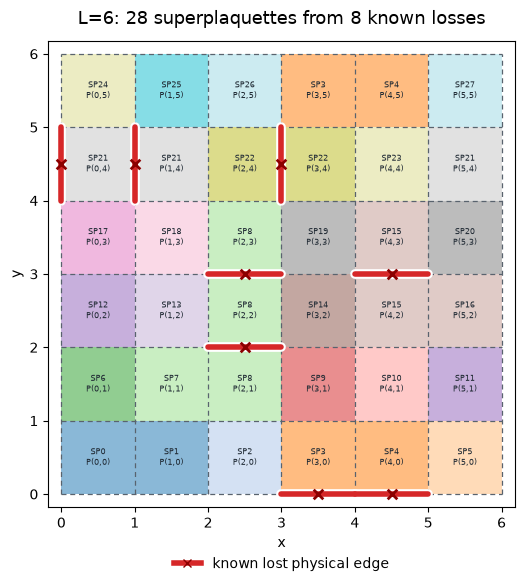

In [17]:
# 셀 17: union-find로 생성된 superplaquette component를 격자 위에 시각화합니다.
# - 같은 superplaquette에 속한 original plaquette들은 같은 색과 같은 SP 번호로 표시합니다.
# - known lost physical edge는 굵은 빨간 선과 x marker로 표시합니다.
# - opposite periodic boundary에 같은 색이 보이면 wrap loss로 하나의 component가 된 것입니다.
# - 이 그림은 디버그용이며 stabilizer support 자체는 다음 셀에서 별도로 계산합니다.

from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle


def plot_superplaquette_components(
    lattice: ToricLattice,
    components: Sequence[SuperPlaquetteComponent],
    plaquette_to_superplaquette: dict[PlaquetteId, SuperPlaquetteId],
    lost_edges: Sequence[EdgeId],
    edge_to_plaquettes: dict[EdgeId, tuple[PlaquetteId, PlaquetteId]],
) -> tuple[Figure, Axes]:
    """Plot colored superplaquette regions and known erasure locations."""
    expected_plaquettes = set(lattice.plaquettes)
    if set(plaquette_to_superplaquette) != expected_plaquettes:
        raise ValueError("plaquette-to-superplaquette mapping is incomplete.")
    component_ids = {component.id for component in components}
    if set(plaquette_to_superplaquette.values()) != component_ids:
        raise ValueError("component IDs and reverse mapping are inconsistent.")
    for lost_edge in lost_edges:
        first, second = edge_to_plaquettes[lost_edge]
        if plaquette_to_superplaquette[first] != plaquette_to_superplaquette[second]:
            raise ValueError(f"Lost edge {lost_edge} crosses two superplaquettes.")

    figure_size = min(12.0, max(6.0, 0.9 * lattice.L))
    fig, ax = plt.subplots(figsize=(figure_size, figure_size))
    color_map = plt.get_cmap("tab20", max(1, len(components)))
    component_colors = {
        component.id: color_map(component.id.index)
        for component in components
    }

    show_cell_labels = lattice.L <= 10
    label_size = max(6.0, min(10.0, 36.0 / lattice.L))
    for plaquette in lattice.plaquettes:
        superplaquette_id = plaquette_to_superplaquette[plaquette]
        ax.add_patch(
            Rectangle(
                (plaquette.x, plaquette.y),
                1.0,
                1.0,
                facecolor=component_colors[superplaquette_id],
                edgecolor="none",
                alpha=0.52,
                zorder=1,
            )
        )
        if show_cell_labels:
            ax.text(
                plaquette.x + 0.5,
                plaquette.y + 0.5,
                (
                    f"SP{superplaquette_id.index}\n"
                    f"P({plaquette.x},{plaquette.y})"
                ),
                ha="center",
                va="center",
                fontsize=label_size,
                color="#1f2933",
                zorder=4,
            )

    for coordinate in range(lattice.L + 1):
        ax.plot(
            [0, lattice.L],
            [coordinate, coordinate],
            color="#59636e",
            linewidth=0.9,
            linestyle=(0, (4, 3)),
            zorder=2,
        )
        ax.plot(
            [coordinate, coordinate],
            [0, lattice.L],
            color="#59636e",
            linewidth=0.9,
            linestyle=(0, (4, 3)),
            zorder=2,
        )

    for lost_edge in lost_edges:
        if lost_edge.orientation == "H":
            x_coordinates = [lost_edge.x, lost_edge.x + 1]
            y_coordinates = [lost_edge.y, lost_edge.y]
            marker_x = lost_edge.x + 0.5
            marker_y = lost_edge.y
        else:
            x_coordinates = [lost_edge.x, lost_edge.x]
            y_coordinates = [lost_edge.y, lost_edge.y + 1]
            marker_x = lost_edge.x
            marker_y = lost_edge.y + 0.5

        ax.plot(
            x_coordinates,
            y_coordinates,
            color="white",
            linewidth=7.0,
            solid_capstyle="round",
            zorder=5,
        )
        ax.plot(
            x_coordinates,
            y_coordinates,
            color="#d62728",
            linewidth=4.0,
            solid_capstyle="round",
            zorder=6,
        )
        ax.scatter(
            [marker_x],
            [marker_y],
            marker="x",
            s=48,
            linewidths=2.0,
            color="#8b0000",
            zorder=7,
        )

    lost_edge_legend = Line2D(
        [0],
        [0],
        color="#d62728",
        marker="x",
        markeredgecolor="#8b0000",
        linewidth=4.0,
        label="known lost physical edge",
    )
    ax.legend(
        handles=[lost_edge_legend],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.08),
        frameon=False,
    )
    ax.set_title(
        f"L={lattice.L}: {len(components)} superplaquettes from "
        f"{len(lost_edges)} known losses",
        fontsize=13,
        pad=12,
    )
    ax.set_xlim(-0.18, lattice.L + 0.18)
    ax.set_ylim(-0.18, lattice.L + 0.18)
    ax.set_xticks(range(lattice.L + 1))
    ax.set_yticks(range(lattice.L + 1))
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    fig.tight_layout(pad=1.2)
    plt.show()
    return fig, ax


superplaquette_figure, superplaquette_axes = plot_superplaquette_components(
    lattice,
    demo_superplaquette_components,
    demo_plaquette_to_superplaquette,
    demo_lost_edges,
    edge_to_plaquettes,
)


In [18]:
# 셀 18: 각 superplaquette component의 effective Z-stabilizer boundary support를 계산합니다.
# - member plaquette support들을 GF(2) XOR하여 내부 physical edge를 모두 상쇄합니다.
# - lost internal edge는 stabilizer support에서 제거하고 component 내부 정보로 따로 저장합니다.
# - surviving external edge만 effective boundary에 남기고 surviving internal edge도 별도 보존합니다.
# - Qiskit Pauli product와 binary support가 일치하고 전체 superplaquette 곱이 identity인지 검사합니다.
# - surviving internal edge는 다음 physical multigraph에서 syndrome-invisible self-loop가 됩니다.


@dataclass(frozen=True)
class SuperPlaquette:
    id: SuperPlaquetteId
    members: tuple[PlaquetteId, ...]
    surviving_boundary_edges: tuple[EdgeId, ...]
    lost_internal_edges: tuple[EdgeId, ...]
    surviving_internal_edges: tuple[EdgeId, ...]

    def __post_init__(self) -> None:
        if not self.members:
            raise ValueError("A superplaquette cannot have no members.")
        edge_groups = (
            self.surviving_boundary_edges,
            self.lost_internal_edges,
            self.surviving_internal_edges,
        )
        if any(len(group) != len(set(group)) for group in edge_groups):
            raise ValueError("Superplaquette edge groups must contain unique IDs.")
        if any(
            set(edge_groups[first]) & set(edge_groups[second])
            for first in range(len(edge_groups))
            for second in range(first + 1, len(edge_groups))
        ):
            raise ValueError("Superplaquette edge groups must be disjoint.")


def build_superplaquette_boundary_supports(
    components: Sequence[SuperPlaquetteComponent],
    plaquette_to_edges: dict[PlaquetteId, tuple[EdgeId, ...]],
    edge_to_plaquettes: dict[EdgeId, tuple[PlaquetteId, PlaquetteId]],
    lost_edges: Iterable[EdgeId],
    edge_to_index: dict[EdgeId, int],
    index_to_edge: Sequence[EdgeId],
) -> tuple[SuperPlaquette, ...]:
    """Build effective supports by XORing constituent plaquette checks."""
    lost_edge_set = set(lost_edges)
    unknown_lost_edges = lost_edge_set - set(index_to_edge)
    if unknown_lost_edges:
        raise KeyError(f"Unknown lost edge IDs: {sorted(unknown_lost_edges)}.")

    superplaquettes = []
    for component in components:
        member_set = set(component.members)
        xor_support = xor_edge_chains(
            (plaquette_to_edges[member] for member in component.members),
            edge_to_index,
            index_to_edge,
        )

        surviving_boundary_edges = []
        lost_internal_edges = []
        surviving_internal_edges = []
        for edge in index_to_edge:
            first, second = edge_to_plaquettes[edge]
            num_adjacent_members = int(first in member_set) + int(
                second in member_set
            )
            if num_adjacent_members == 1:
                if edge in lost_edge_set:
                    raise AssertionError(
                        f"Lost edge {edge} cannot cross a component boundary."
                    )
                surviving_boundary_edges.append(edge)
            elif num_adjacent_members == 2:
                if edge in lost_edge_set:
                    lost_internal_edges.append(edge)
                else:
                    surviving_internal_edges.append(edge)

        if tuple(surviving_boundary_edges) != xor_support:
            raise AssertionError(
                f"XOR support and geometric boundary disagree for {component.id}."
            )
        if set(xor_support) & lost_edge_set:
            raise AssertionError("A lost edge remained in superplaquette support.")

        superplaquettes.append(
            SuperPlaquette(
                id=component.id,
                members=component.members,
                surviving_boundary_edges=tuple(surviving_boundary_edges),
                lost_internal_edges=tuple(lost_internal_edges),
                surviving_internal_edges=tuple(surviving_internal_edges),
            )
        )

    all_lost_internal_edges = tuple(
        edge
        for superplaquette in superplaquettes
        for edge in superplaquette.lost_internal_edges
    )
    if len(all_lost_internal_edges) != len(set(all_lost_internal_edges)):
        raise AssertionError("A lost edge belongs to multiple superplaquettes.")
    if set(all_lost_internal_edges) != lost_edge_set:
        raise AssertionError("Not every lost edge was retained as internal metadata.")

    global_boundary = xor_edge_chains(
        (
            superplaquette.surviving_boundary_edges
            for superplaquette in superplaquettes
        ),
        edge_to_index,
        index_to_edge,
    )
    if global_boundary:
        raise AssertionError("Product of all superplaquette supports is not identity.")
    return tuple(superplaquettes)


no_loss_superplaquettes = build_superplaquette_boundary_supports(
    no_loss_components,
    plaquette_to_edges,
    edge_to_plaquettes,
    (),
    edge_to_qiskit_index,
    qiskit_index_to_edge,
)
assert all(
    len(superplaquette.surviving_boundary_edges) == 4
    for superplaquette in no_loss_superplaquettes
)
assert all(
    not superplaquette.lost_internal_edges
    for superplaquette in no_loss_superplaquettes
)

single_loss_superplaquettes = build_superplaquette_boundary_supports(
    single_loss_components,
    plaquette_to_edges,
    edge_to_plaquettes,
    (single_lost_edge,),
    edge_to_qiskit_index,
    qiskit_index_to_edge,
)
single_loss_superplaquette_id = single_loss_plaquette_mapping[single_loss_pair[0]]
single_loss_superplaquette = next(
    superplaquette
    for superplaquette in single_loss_superplaquettes
    if superplaquette.id == single_loss_superplaquette_id
)
assert single_lost_edge in single_loss_superplaquette.lost_internal_edges
assert single_lost_edge not in single_loss_superplaquette.surviving_boundary_edges

all_loss_superplaquettes = build_superplaquette_boundary_supports(
    all_loss_components,
    plaquette_to_edges,
    edge_to_plaquettes,
    lattice.edges,
    edge_to_qiskit_index,
    qiskit_index_to_edge,
)
assert len(all_loss_superplaquettes) == 1
assert all_loss_superplaquettes[0].surviving_boundary_edges == ()
assert set(all_loss_superplaquettes[0].lost_internal_edges) == set(lattice.edges)

demo_superplaquettes = build_superplaquette_boundary_supports(
    demo_superplaquette_components,
    plaquette_to_edges,
    edge_to_plaquettes,
    demo_lost_edges,
    edge_to_qiskit_index,
    qiskit_index_to_edge,
)
demo_superplaquette_by_id = {
    superplaquette.id: superplaquette
    for superplaquette in demo_superplaquettes
}

demo_superplaquette_operators = {
    superplaquette.id: pauli_from_edges(
        superplaquette.surviving_boundary_edges,
        "Z",
        edge_to_qiskit_index,
    )
    for superplaquette in demo_superplaquettes
}
for superplaquette in demo_superplaquettes:
    member_product = pauli_product(
        (plaquette_operators[member] for member in superplaquette.members),
        num_data_qubits,
    )
    assert member_product == demo_superplaquette_operators[superplaquette.id]

demo_superplaquette_global_product = pauli_product(
    demo_superplaquette_operators.values(),
    num_data_qubits,
)
assert demo_superplaquette_global_product == identity_pauli

boundary_owners: dict[EdgeId, list[SuperPlaquetteId]] = {
    edge: [] for edge in lattice.edges
}
for superplaquette in demo_superplaquettes:
    for edge in superplaquette.surviving_boundary_edges:
        boundary_owners[edge].append(superplaquette.id)

demo_lost_edge_set = set(demo_lost_edges)
for edge in lattice.edges:
    first, second = edge_to_plaquettes[edge]
    first_superplaquette = demo_plaquette_to_superplaquette[first]
    second_superplaquette = demo_plaquette_to_superplaquette[second]
    owners = boundary_owners[edge]
    if edge in demo_lost_edge_set:
        assert owners == []
        assert first_superplaquette == second_superplaquette
    elif first_superplaquette == second_superplaquette:
        assert owners == []
        assert edge in demo_superplaquette_by_id[
            first_superplaquette
        ].surviving_internal_edges
    else:
        assert set(owners) == {first_superplaquette, second_superplaquette}

superplaquette_support_rows = [
    {
        "superplaquette": f"SP{superplaquette.id.index}",
        "members": len(superplaquette.members),
        "boundary_edges": len(superplaquette.surviving_boundary_edges),
        "lost_internal": len(superplaquette.lost_internal_edges),
        "surviving_internal": len(superplaquette.surviving_internal_edges),
        "boundary_support": ", ".join(
            f"{edge.orientation}({edge.x},{edge.y})"
            for edge in superplaquette.surviving_boundary_edges
        ),
    }
    for superplaquette in demo_superplaquettes
]
superplaquette_support_summary = pd.DataFrame(superplaquette_support_rows)
print(superplaquette_support_summary.head(20).to_string(index=False))
if len(superplaquette_support_summary) > 20:
    print(f"Showing 20 of {len(superplaquette_support_summary)} superplaquettes.")
print("Superplaquette boundary-support and Pauli-product checks passed.")


superplaquette  members  boundary_edges  lost_internal  surviving_internal                                               boundary_support
           SP0        1               4              0                   0                                 H(0,0), H(0,1), V(0,0), V(1,0)
           SP1        1               4              0                   0                                 H(1,0), H(1,1), V(1,0), V(2,0)
           SP2        1               4              0                   0                                 H(2,0), H(2,1), V(2,0), V(3,0)
           SP3        2               6              1                   0                 H(3,1), H(3,5), V(3,0), V(4,0), V(3,5), V(4,5)
           SP4        2               6              1                   0                 H(4,1), H(4,5), V(4,0), V(5,0), V(4,5), V(5,5)
           SP5        1               4              0                   0                                 H(5,0), H(5,1), V(0,0), V(5,0)
           SP6        1           

In [19]:
# 셀 19: surviving physical qubit을 보존하는 superplaquette physical multigraph를 만듭니다.
# - graph node는 superplaquette이고 각 surviving physical edge는 정확히 하나의 multigraph edge가 됩니다.
# - 같은 두 node를 잇는 병렬 physical edge를 아직 합치지 않고 각각의 EdgeId로 유지합니다.
# - 양쪽 plaquette가 같은 superplaquette에 속하면 syndrome-invisible self-loop로 보존합니다.
# - lost edge는 graph에서 제외하고 no-loss, single-loss, all-loss, demo pattern을 검증합니다.


@dataclass(frozen=True)
class PhysicalCheckEdge:
    physical_edge: EdgeId
    u: SuperPlaquetteId
    v: SuperPlaquetteId

    def __post_init__(self) -> None:
        if self.v < self.u:
            raise ValueError("Physical-check edge endpoints must be canonical.")

    @property
    def is_self_loop(self) -> bool:
        return self.u == self.v


@dataclass(frozen=True)
class PhysicalCheckMultigraph:
    graph: nx.MultiGraph
    edge_records: tuple[PhysicalCheckEdge, ...]
    lost_edges: tuple[EdgeId, ...]

    @property
    def surviving_edges(self) -> tuple[EdgeId, ...]:
        return tuple(record.physical_edge for record in self.edge_records)

    @property
    def self_loop_records(self) -> tuple[PhysicalCheckEdge, ...]:
        return tuple(record for record in self.edge_records if record.is_self_loop)

    @property
    def interface_records(self) -> tuple[PhysicalCheckEdge, ...]:
        return tuple(record for record in self.edge_records if not record.is_self_loop)


def build_physical_check_multigraph(
    superplaquettes: Sequence[SuperPlaquette],
    plaquette_to_superplaquette: dict[PlaquetteId, SuperPlaquetteId],
    physical_edges: Sequence[EdgeId],
    edge_to_plaquettes: dict[EdgeId, tuple[PlaquetteId, PlaquetteId]],
    lost_edges: Iterable[EdgeId],
    edge_to_index: dict[EdgeId, int],
) -> PhysicalCheckMultigraph:
    """Retain one multigraph edge for every surviving physical qubit."""
    ordered_physical_edges = tuple(physical_edges)
    if len(ordered_physical_edges) != len(set(ordered_physical_edges)):
        raise ValueError("Physical edge IDs must be unique.")
    if set(ordered_physical_edges) != set(edge_to_plaquettes):
        raise ValueError("Physical edges and plaquette incidence disagree.")
    if set(ordered_physical_edges) != set(edge_to_index):
        raise ValueError("Physical edges and Qiskit indexing disagree.")

    lost_edge_set = set(lost_edges)
    unknown_lost_edges = lost_edge_set - set(ordered_physical_edges)
    if unknown_lost_edges:
        raise KeyError(f"Unknown lost edge IDs: {sorted(unknown_lost_edges)}.")

    superplaquette_by_id = {
        superplaquette.id: superplaquette
        for superplaquette in superplaquettes
    }
    if len(superplaquette_by_id) != len(superplaquettes):
        raise ValueError("Superplaquette IDs must be unique.")
    if set(plaquette_to_superplaquette.values()) != set(superplaquette_by_id):
        raise ValueError("Superplaquette nodes and reverse mapping disagree.")

    graph = nx.MultiGraph()
    for superplaquette in superplaquettes:
        graph.add_node(
            superplaquette.id,
            members=superplaquette.members,
            representative=superplaquette.members[0],
        )

    edge_records = []
    for physical_edge in ordered_physical_edges:
        if physical_edge in lost_edge_set:
            continue
        first_plaquette, second_plaquette = edge_to_plaquettes[physical_edge]
        first_node = plaquette_to_superplaquette[first_plaquette]
        second_node = plaquette_to_superplaquette[second_plaquette]
        u, v = sorted((first_node, second_node))
        record = PhysicalCheckEdge(physical_edge=physical_edge, u=u, v=v)
        edge_records.append(record)
        graph.add_edge(
            u,
            v,
            key=physical_edge,
            physical_edge=physical_edge,
            qiskit_index=edge_to_index[physical_edge],
            is_self_loop=record.is_self_loop,
        )

    graph_physical_edges = tuple(
        attributes["physical_edge"]
        for _, _, _, attributes in graph.edges(keys=True, data=True)
    )
    surviving_edge_set = set(ordered_physical_edges) - lost_edge_set
    if len(graph_physical_edges) != len(surviving_edge_set):
        raise AssertionError("A surviving physical edge was duplicated or omitted.")
    if set(graph_physical_edges) != surviving_edge_set:
        raise AssertionError("Physical multigraph edge accounting failed.")
    if graph.number_of_nodes() != len(superplaquettes):
        raise AssertionError("Physical multigraph node accounting failed.")

    return PhysicalCheckMultigraph(
        graph=graph,
        edge_records=tuple(edge_records),
        lost_edges=tuple(
            edge for edge in ordered_physical_edges if edge in lost_edge_set
        ),
    )


def verify_physical_multigraph_against_supports(
    physical_multigraph: PhysicalCheckMultigraph,
    superplaquettes: Sequence[SuperPlaquette],
) -> None:
    """Cross-check self-loops and interfaces against effective supports."""
    boundary_counts: dict[EdgeId, int] = {}
    expected_self_loop_edges = set()
    for superplaquette in superplaquettes:
        expected_self_loop_edges.update(superplaquette.surviving_internal_edges)
        for edge in superplaquette.surviving_boundary_edges:
            boundary_counts[edge] = boundary_counts.get(edge, 0) + 1

    actual_self_loop_edges = {
        record.physical_edge
        for record in physical_multigraph.self_loop_records
    }
    if actual_self_loop_edges != expected_self_loop_edges:
        raise AssertionError("Self-loops disagree with surviving internal edges.")
    for record in physical_multigraph.interface_records:
        if boundary_counts.get(record.physical_edge, 0) != 2:
            raise AssertionError("An interface edge must bound two superplaquettes.")
    for record in physical_multigraph.self_loop_records:
        if boundary_counts.get(record.physical_edge, 0) != 0:
            raise AssertionError("A self-loop cannot remain on a supercheck boundary.")


no_loss_physical_multigraph = build_physical_check_multigraph(
    no_loss_superplaquettes,
    no_loss_plaquette_mapping,
    lattice.edges,
    edge_to_plaquettes,
    (),
    edge_to_qiskit_index,
)
verify_physical_multigraph_against_supports(
    no_loss_physical_multigraph, no_loss_superplaquettes
)
assert no_loss_physical_multigraph.graph.number_of_nodes() == L**2
assert no_loss_physical_multigraph.graph.number_of_edges() == 2 * L**2
assert not no_loss_physical_multigraph.self_loop_records

single_loss_physical_multigraph = build_physical_check_multigraph(
    single_loss_superplaquettes,
    single_loss_plaquette_mapping,
    lattice.edges,
    edge_to_plaquettes,
    (single_lost_edge,),
    edge_to_qiskit_index,
)
verify_physical_multigraph_against_supports(
    single_loss_physical_multigraph, single_loss_superplaquettes
)
assert single_loss_physical_multigraph.graph.number_of_nodes() == L**2 - 1
assert single_loss_physical_multigraph.graph.number_of_edges() == 2 * L**2 - 1

all_loss_physical_multigraph = build_physical_check_multigraph(
    all_loss_superplaquettes,
    all_loss_plaquette_mapping,
    lattice.edges,
    edge_to_plaquettes,
    lattice.edges,
    edge_to_qiskit_index,
)
verify_physical_multigraph_against_supports(
    all_loss_physical_multigraph, all_loss_superplaquettes
)
assert all_loss_physical_multigraph.graph.number_of_nodes() == 1
assert all_loss_physical_multigraph.graph.number_of_edges() == 0

demo_physical_check_multigraph = build_physical_check_multigraph(
    demo_superplaquettes,
    demo_plaquette_to_superplaquette,
    lattice.edges,
    edge_to_plaquettes,
    demo_lost_edges,
    edge_to_qiskit_index,
)
verify_physical_multigraph_against_supports(
    demo_physical_check_multigraph, demo_superplaquettes
)
assert demo_physical_check_multigraph.surviving_edges == demo_surviving_edges
assert not set(demo_physical_check_multigraph.surviving_edges) & set(
    demo_lost_edges
)

interface_multiplicities: dict[
    tuple[SuperPlaquetteId, SuperPlaquetteId], int
] = {}
for record in demo_physical_check_multigraph.interface_records:
    node_pair = (record.u, record.v)
    interface_multiplicities[node_pair] = (
        interface_multiplicities.get(node_pair, 0) + 1
    )

physical_multigraph_summary = pd.DataFrame(
    [
        {
            "L": L,
            "superplaquette_nodes": (
                demo_physical_check_multigraph.graph.number_of_nodes()
            ),
            "lost_edges": len(demo_physical_check_multigraph.lost_edges),
            "surviving_physical_edges": len(
                demo_physical_check_multigraph.edge_records
            ),
            "interface_edges": len(
                demo_physical_check_multigraph.interface_records
            ),
            "self_loops": len(
                demo_physical_check_multigraph.self_loop_records
            ),
            "parallel_interfaces": sum(
                multiplicity > 1
                for multiplicity in interface_multiplicities.values()
            ),
            "max_interface_multiplicity": max(
                interface_multiplicities.values(), default=0
            ),
        }
    ]
)
demo_self_loop_edges = tuple(
    record.physical_edge
    for record in demo_physical_check_multigraph.self_loop_records
)
print(physical_multigraph_summary.to_string(index=False))
print("Syndrome-invisible surviving self-loops:", demo_self_loop_edges)
print("Physical multigraph edge-accounting checks passed.")


 L  superplaquette_nodes  lost_edges  surviving_physical_edges  interface_edges  self_loops  parallel_interfaces  max_interface_multiplicity
 6                    28           8                        64               64           0                    1                           2
Syndrome-invisible surviving self-loops: ()
Physical multigraph edge-accounting checks passed.


In [20]:
# 셀 20: 병렬 physical interface edge를 weighted superedge로 합쳐 degraded graph를 만듭니다.
# - multiplicity n_l은 같은 두 superplaquette 사이의 surviving physical qubit 개수입니다.
# - Eq. (1)로 odd-error probability p_l을 계산하고 log((1-p_l)/p_l)을 weight로 저장합니다.
# - physical self-loop는 syndrome-invisible이므로 matching graph에서 제외하되 별도 기록으로 보존합니다.
# - closed form을 explicit odd-binomial sum과 비교하고 확률의 경계값 및 단조성을 검증합니다.


def odd_parity_probability(p_comp: float, multiplicity: int) -> float:
    """Return the probability of an odd number of interface errors."""
    if not 0.0 <= p_comp < 0.5:
        raise ValueError("p_comp must lie in [0, 0.5).")
    if (
        isinstance(multiplicity, bool)
        or not isinstance(multiplicity, (int, np.integer))
        or multiplicity <= 0
    ):
        raise ValueError("multiplicity must be a positive integer.")
    return 0.5 * (1.0 - (1.0 - 2.0 * p_comp) ** int(multiplicity))


def explicit_odd_binomial_probability(
    p_comp: float, multiplicity: int
) -> float:
    """Reference Eq. (1) by summing all odd binomial terms."""
    if not 0.0 <= p_comp < 0.5:
        raise ValueError("p_comp must lie in [0, 0.5).")
    if multiplicity <= 0:
        raise ValueError("multiplicity must be positive.")
    return sum(
        math.comb(multiplicity, num_errors)
        * p_comp**num_errors
        * (1.0 - p_comp) ** (multiplicity - num_errors)
        for num_errors in range(1, multiplicity + 1, 2)
    )


@dataclass(frozen=True)
class SuperEdge:
    u: SuperPlaquetteId
    v: SuperPlaquetteId
    physical_edges: tuple[EdgeId, ...]
    multiplicity: int
    odd_error_probability: float
    log_likelihood_weight: float

    def __post_init__(self) -> None:
        if self.v <= self.u:
            raise ValueError("A superedge must join two canonical distinct nodes.")
        if self.multiplicity <= 0:
            raise ValueError("A superedge multiplicity must be positive.")
        if self.multiplicity != len(self.physical_edges):
            raise ValueError("Multiplicity must equal physical-edge count.")
        if len(set(self.physical_edges)) != len(self.physical_edges):
            raise ValueError("A superedge cannot repeat a physical edge.")
        if not 0.0 <= self.odd_error_probability < 0.5:
            raise ValueError("Effective odd-error probability is invalid.")
        expected_weight = log_likelihood_weight(
            self.odd_error_probability
        )
        if math.isinf(expected_weight):
            if not math.isinf(self.log_likelihood_weight):
                raise ValueError("Zero error probability requires infinite weight.")
        elif not math.isclose(
            self.log_likelihood_weight, expected_weight, rel_tol=1e-12
        ):
            raise ValueError("Stored superedge weight is inconsistent.")


@dataclass(frozen=True)
class DegradedSupercheckGraph:
    graph: nx.Graph
    superedges: tuple[SuperEdge, ...]
    physical_self_loops: tuple[PhysicalCheckEdge, ...]
    p_comp: float


def build_degraded_supercheck_graph(
    physical_multigraph: PhysicalCheckMultigraph,
    p_comp: float,
) -> DegradedSupercheckGraph:
    """Collapse parallel interfaces while retaining reconstruction data."""
    if not 0.0 <= p_comp < 0.5:
        raise ValueError("p_comp must lie in [0, 0.5).")

    grouped_physical_edges: dict[
        tuple[SuperPlaquetteId, SuperPlaquetteId], list[EdgeId]
    ] = {}
    for record in physical_multigraph.interface_records:
        node_pair = (record.u, record.v)
        grouped_physical_edges.setdefault(node_pair, []).append(
            record.physical_edge
        )

    graph = nx.Graph()
    for node, attributes in physical_multigraph.graph.nodes(data=True):
        graph.add_node(node, **dict(attributes))

    superedges = []
    for u, v in sorted(
        grouped_physical_edges,
        key=lambda pair: (pair[0].index, pair[1].index),
    ):
        physical_edges = tuple(grouped_physical_edges[(u, v)])
        multiplicity = len(physical_edges)
        effective_probability = odd_parity_probability(
            p_comp, multiplicity
        )
        superedge = SuperEdge(
            u=u,
            v=v,
            physical_edges=physical_edges,
            multiplicity=multiplicity,
            odd_error_probability=effective_probability,
            log_likelihood_weight=log_likelihood_weight(
                effective_probability
            ),
        )
        superedges.append(superedge)
        graph.add_edge(
            u,
            v,
            weight=superedge.log_likelihood_weight,
            multiplicity=superedge.multiplicity,
            odd_error_probability=superedge.odd_error_probability,
            physical_edges=superedge.physical_edges,
            superedge=superedge,
        )

    collapsed_physical_edges = tuple(
        edge for superedge in superedges for edge in superedge.physical_edges
    )
    expected_interface_edges = tuple(
        record.physical_edge
        for record in physical_multigraph.interface_records
    )
    self_loop_edges = tuple(
        record.physical_edge
        for record in physical_multigraph.self_loop_records
    )
    if len(collapsed_physical_edges) != len(expected_interface_edges):
        raise AssertionError("A physical interface edge was duplicated.")
    if set(collapsed_physical_edges) != set(expected_interface_edges):
        raise AssertionError("A physical interface edge was lost in collapse.")
    if set(collapsed_physical_edges) & set(self_loop_edges):
        raise AssertionError("A physical self-loop entered the matching graph.")
    if set(collapsed_physical_edges) | set(self_loop_edges) != set(
        physical_multigraph.surviving_edges
    ):
        raise AssertionError("Degraded graph does not partition surviving edges.")
    if graph.number_of_nodes() != physical_multigraph.graph.number_of_nodes():
        raise AssertionError("Degraded graph changed the supercheck nodes.")
    if graph.number_of_edges() != len(superedges):
        raise AssertionError("Parallel interfaces were not fully collapsed.")
    if nx.number_of_selfloops(graph) != 0:
        raise AssertionError("Matching graph must not contain self-loops.")

    return DegradedSupercheckGraph(
        graph=graph,
        superedges=tuple(superedges),
        physical_self_loops=physical_multigraph.self_loop_records,
        p_comp=p_comp,
    )


for test_probability in (0.0, 0.01, 0.08, 0.20, 0.49):
    for test_multiplicity in range(1, 9):
        closed_form = odd_parity_probability(
            test_probability, test_multiplicity
        )
        explicit_sum = explicit_odd_binomial_probability(
            test_probability, test_multiplicity
        )
        assert np.isclose(closed_form, explicit_sum, atol=1e-14)

assert np.isclose(odd_parity_probability(0.08, 1), 0.08)
assert np.isclose(
    odd_parity_probability(0.08, 2), 2.0 * 0.08 * (1.0 - 0.08)
)
assert odd_parity_probability(0.0, 7) == 0.0
small_probability = 1e-8
assert np.isclose(
    odd_parity_probability(small_probability, 7),
    7 * small_probability,
    rtol=1e-6,
)
monotone_probabilities = [
    odd_parity_probability(0.08, multiplicity)
    for multiplicity in range(1, 9)
]
assert all(
    first < second
    for first, second in zip(
        monotone_probabilities, monotone_probabilities[1:]
    )
)
for invalid_probability in (-0.01, 0.5, 1.0):
    try:
        odd_parity_probability(invalid_probability, 1)
    except ValueError:
        pass
    else:
        raise AssertionError("Invalid p_comp was accepted.")
for invalid_multiplicity in (0, -1):
    try:
        odd_parity_probability(0.08, invalid_multiplicity)
    except ValueError:
        pass
    else:
        raise AssertionError("Invalid multiplicity was accepted.")

no_loss_degraded_graph = build_degraded_supercheck_graph(
    no_loss_physical_multigraph, demo_comp_probability
)
assert sum(
    superedge.multiplicity for superedge in no_loss_degraded_graph.superedges
) == len(no_loss_physical_multigraph.interface_records)
assert not no_loss_degraded_graph.physical_self_loops

single_loss_degraded_graph = build_degraded_supercheck_graph(
    single_loss_physical_multigraph, demo_comp_probability
)
assert single_loss_degraded_graph.physical_self_loops == (
    single_loss_physical_multigraph.self_loop_records
)

all_loss_degraded_graph = build_degraded_supercheck_graph(
    all_loss_physical_multigraph, demo_comp_probability
)
assert all_loss_degraded_graph.graph.number_of_nodes() == 1
assert all_loss_degraded_graph.graph.number_of_edges() == 0

zero_error_degraded_graph = build_degraded_supercheck_graph(
    demo_physical_check_multigraph, 0.0
)
assert all(
    math.isinf(superedge.log_likelihood_weight)
    for superedge in zero_error_degraded_graph.superedges
)

demo_degraded_supercheck_graph = build_degraded_supercheck_graph(
    demo_physical_check_multigraph, demo_comp_probability
)
repeated_demo_degraded_graph = build_degraded_supercheck_graph(
    demo_physical_check_multigraph, demo_comp_probability
)
assert (
    demo_degraded_supercheck_graph.superedges
    == repeated_demo_degraded_graph.superedges
)

degraded_graph_summary = pd.DataFrame(
    [
        {
            "L": L,
            "p_comp_demo": demo_comp_probability,
            "superplaquette_nodes": (
                demo_degraded_supercheck_graph.graph.number_of_nodes()
            ),
            "physical_interface_edges": len(
                demo_physical_check_multigraph.interface_records
            ),
            "degraded_superedges": len(
                demo_degraded_supercheck_graph.superedges
            ),
            "collapsed_parallel_edges": (
                len(demo_physical_check_multigraph.interface_records)
                - len(demo_degraded_supercheck_graph.superedges)
            ),
            "self_loops_excluded": len(
                demo_degraded_supercheck_graph.physical_self_loops
            ),
        }
    ]
)
degraded_superedge_rows = [
    {
        "superedge": f"SP{superedge.u.index}--SP{superedge.v.index}",
        "multiplicity": superedge.multiplicity,
        "p_odd": superedge.odd_error_probability,
        "weight": superedge.log_likelihood_weight,
        "physical_edges": ", ".join(
            f"{edge.orientation}({edge.x},{edge.y})"
            for edge in superedge.physical_edges
        ),
    }
    for superedge in demo_degraded_supercheck_graph.superedges
]
degraded_superedge_summary = pd.DataFrame(
    degraded_superedge_rows,
    columns=[
        "superedge",
        "multiplicity",
        "p_odd",
        "weight",
        "physical_edges",
    ],
)
print(degraded_graph_summary.to_string(index=False))
if degraded_superedge_summary.empty:
    print("No candidate superedges remain.")
else:
    print(degraded_superedge_summary.head(20).to_string(index=False))
    if len(degraded_superedge_summary) > 20:
        print(f"Showing 20 of {len(degraded_superedge_summary)} superedges.")
print("Eq. (1) probability and degraded-graph checks passed.")


 L  p_comp_demo  superplaquette_nodes  physical_interface_edges  degraded_superedges  collapsed_parallel_edges  self_loops_excluded
 6         0.08                    28                        64                   63                         1                    0
superedge  multiplicity  p_odd   weight physical_edges
 SP0--SP1             1 0.0800 2.442347         V(1,0)
 SP0--SP5             1 0.0800 2.442347         V(0,0)
 SP0--SP6             1 0.0800 2.442347         H(0,1)
SP0--SP24             1 0.0800 2.442347         H(0,0)
 SP1--SP2             1 0.0800 2.442347         V(2,0)
 SP1--SP7             1 0.0800 2.442347         H(1,1)
SP1--SP25             1 0.0800 2.442347         H(1,0)
 SP2--SP3             1 0.0800 2.442347         V(3,0)
 SP2--SP8             1 0.0800 2.442347         H(2,1)
SP2--SP26             1 0.0800 2.442347         H(2,0)
 SP3--SP4             2 0.1472 1.756733 V(4,0), V(4,5)
 SP3--SP9             1 0.0800 2.442347         H(3,1)
SP3--SP22            

In [21]:
# 셀 21: degraded supercheck graph를 original L x L plaquette lattice로 복원합니다.
# - restored graph node는 original plaquette이며 각 node가 속한 superplaquette ID를 보존합니다.
# - 같은 superplaquette 내부 adjacency는 weight 0인 algorithmic reconstruction edge가 됩니다.
# - 서로 다른 superplaquette 사이 adjacency는 대응하는 superedge weight와 physical 후보를 가집니다.
# - zero edge는 physical qubit이 아니며 오류 샘플링이나 physical resource count에 포함하지 않습니다.
# - degraded graph와 restored graph의 representative 간 weighted shortest distance가 같은지 검증합니다.


RestoredEdgeKind = Literal[
    "lost_reconstruction",
    "self_loop_reconstruction",
    "interface",
]


@dataclass(frozen=True)
class RestoredGraphEdge:
    source_adjacency: EdgeId
    u: PlaquetteId
    v: PlaquetteId
    kind: RestoredEdgeKind
    weight: float
    superedge: SuperEdge | None
    candidate_physical_edges: tuple[EdgeId, ...]

    def __post_init__(self) -> None:
        if self.u == self.v:
            raise ValueError("A restored adjacency must join two plaquettes.")
        if self.weight < 0.0:
            raise ValueError("Restored edge weight cannot be negative.")
        if self.kind == "interface":
            if self.superedge is None:
                raise ValueError("An interface must reference a superedge.")
            if self.candidate_physical_edges != self.superedge.physical_edges:
                raise ValueError("Interface reconstruction data is inconsistent.")
            if not math.isclose(
                self.weight,
                self.superedge.log_likelihood_weight,
                rel_tol=1e-12,
            ):
                raise ValueError("Interface weight does not match its superedge.")
        else:
            if self.weight != 0.0:
                raise ValueError("Reconstruction edges must have zero weight.")
            if self.superedge is not None or self.candidate_physical_edges:
                raise ValueError(
                    "Zero reconstruction edges cannot be physical corrections."
                )


@dataclass(frozen=True)
class RestoredSquareGraph:
    graph: nx.MultiGraph
    edge_records: tuple[RestoredGraphEdge, ...]
    plaquette_to_superplaquette: dict[
        PlaquetteId, SuperPlaquetteId
    ]

    @property
    def reconstruction_records(self) -> tuple[RestoredGraphEdge, ...]:
        return tuple(
            record for record in self.edge_records if record.kind != "interface"
        )

    @property
    def interface_records(self) -> tuple[RestoredGraphEdge, ...]:
        return tuple(
            record for record in self.edge_records if record.kind == "interface"
        )

    @property
    def lost_reconstruction_records(
        self,
    ) -> tuple[RestoredGraphEdge, ...]:
        return tuple(
            record
            for record in self.edge_records
            if record.kind == "lost_reconstruction"
        )

    @property
    def self_loop_reconstruction_records(
        self,
    ) -> tuple[RestoredGraphEdge, ...]:
        return tuple(
            record
            for record in self.edge_records
            if record.kind == "self_loop_reconstruction"
        )


def build_restored_square_graph(
    plaquette_ids: Sequence[PlaquetteId],
    physical_edges: Sequence[EdgeId],
    edge_to_plaquettes: dict[EdgeId, tuple[PlaquetteId, PlaquetteId]],
    plaquette_to_superplaquette: dict[PlaquetteId, SuperPlaquetteId],
    physical_multigraph: PhysicalCheckMultigraph,
    degraded_graph: DegradedSupercheckGraph,
) -> RestoredSquareGraph:
    """Restore original plaquette adjacencies without creating qubits."""
    ordered_plaquettes = tuple(
        sorted(plaquette_ids, key=plaquette_order_key)
    )
    ordered_physical_edges = tuple(physical_edges)
    if len(ordered_plaquettes) != len(set(ordered_plaquettes)):
        raise ValueError("Plaquette IDs must be unique.")
    if len(ordered_physical_edges) != len(set(ordered_physical_edges)):
        raise ValueError("Physical edge IDs must be unique.")
    if set(plaquette_to_superplaquette) != set(ordered_plaquettes):
        raise ValueError("Plaquette-to-superplaquette mapping is incomplete.")
    if set(ordered_physical_edges) != set(edge_to_plaquettes):
        raise ValueError("Original adjacency map is incomplete.")
    if set(plaquette_to_superplaquette.values()) != set(
        degraded_graph.graph.nodes
    ):
        raise ValueError("Degraded and restored supercheck nodes disagree.")

    superedge_by_pair = {
        (superedge.u, superedge.v): superedge
        for superedge in degraded_graph.superedges
    }
    if len(superedge_by_pair) != len(degraded_graph.superedges):
        raise ValueError("Degraded superedge node pairs must be unique.")

    lost_edge_set = set(physical_multigraph.lost_edges)
    physical_self_loop_set = {
        record.physical_edge
        for record in degraded_graph.physical_self_loops
    }
    interface_physical_edge_set = {
        edge
        for superedge in degraded_graph.superedges
        for edge in superedge.physical_edges
    }
    if (
        lost_edge_set & physical_self_loop_set
        or lost_edge_set & interface_physical_edge_set
        or physical_self_loop_set & interface_physical_edge_set
    ):
        raise AssertionError("Physical edge classes must be disjoint.")
    if (
        lost_edge_set
        | physical_self_loop_set
        | interface_physical_edge_set
    ) != set(ordered_physical_edges):
        raise AssertionError("Physical edge classes do not cover the lattice.")

    graph = nx.MultiGraph()
    graph.graph["contains_sampled_physical_errors"] = False
    for plaquette in ordered_plaquettes:
        graph.add_node(
            plaquette,
            superplaquette=plaquette_to_superplaquette[plaquette],
        )

    edge_records = []
    for source_adjacency in ordered_physical_edges:
        u, v = edge_to_plaquettes[source_adjacency]
        u_superplaquette = plaquette_to_superplaquette[u]
        v_superplaquette = plaquette_to_superplaquette[v]

        if u_superplaquette == v_superplaquette:
            if source_adjacency in lost_edge_set:
                kind: RestoredEdgeKind = "lost_reconstruction"
            elif source_adjacency in physical_self_loop_set:
                kind = "self_loop_reconstruction"
            else:
                raise AssertionError(
                    "Internal adjacency is neither loss nor physical self-loop."
                )
            record = RestoredGraphEdge(
                source_adjacency=source_adjacency,
                u=u,
                v=v,
                kind=kind,
                weight=0.0,
                superedge=None,
                candidate_physical_edges=(),
            )
        else:
            first_node, second_node = sorted(
                (u_superplaquette, v_superplaquette)
            )
            node_pair = (first_node, second_node)
            superedge = superedge_by_pair.get(node_pair)
            if superedge is None:
                raise AssertionError("Missing degraded superedge.")
            if source_adjacency not in superedge.physical_edges:
                raise AssertionError(
                    "Restored interface maps to the wrong superedge."
                )
            record = RestoredGraphEdge(
                source_adjacency=source_adjacency,
                u=u,
                v=v,
                kind="interface",
                weight=superedge.log_likelihood_weight,
                superedge=superedge,
                candidate_physical_edges=superedge.physical_edges,
            )

        edge_records.append(record)
        graph.add_edge(
            u,
            v,
            key=source_adjacency,
            weight=record.weight,
            kind=record.kind,
            source_adjacency=record.source_adjacency,
            superedge=record.superedge,
            candidate_physical_edges=record.candidate_physical_edges,
            is_sampled_physical_location=False,
        )

    restored_graph = RestoredSquareGraph(
        graph=graph,
        edge_records=tuple(edge_records),
        plaquette_to_superplaquette=dict(plaquette_to_superplaquette),
    )
    if graph.number_of_nodes() != len(ordered_plaquettes):
        raise AssertionError("Restored graph node count is incorrect.")
    if graph.number_of_edges() != len(ordered_physical_edges):
        raise AssertionError("Restored graph adjacency count is incorrect.")
    if len(restored_graph.lost_reconstruction_records) != len(lost_edge_set):
        raise AssertionError("Lost reconstruction-edge count is incorrect.")
    if len(restored_graph.self_loop_reconstruction_records) != len(
        physical_self_loop_set
    ):
        raise AssertionError("Self-loop reconstruction count is incorrect.")
    if len(restored_graph.interface_records) != len(
        interface_physical_edge_set
    ):
        raise AssertionError("Restored interface count is incorrect.")

    for superplaquette_id in degraded_graph.graph.nodes:
        members = tuple(
            plaquette
            for plaquette in ordered_plaquettes
            if plaquette_to_superplaquette[plaquette] == superplaquette_id
        )
        zero_subgraph = nx.Graph()
        zero_subgraph.add_nodes_from(members)
        zero_subgraph.add_edges_from(
            (record.u, record.v)
            for record in restored_graph.reconstruction_records
            if plaquette_to_superplaquette[record.u] == superplaquette_id
        )
        if not nx.is_connected(zero_subgraph):
            raise AssertionError(
                f"Zero edges do not connect {superplaquette_id}."
            )

    return restored_graph


def verify_restored_distance_equivalence(
    degraded_graph: DegradedSupercheckGraph,
    restored_graph: RestoredSquareGraph,
    max_pairs: int = 512,
) -> int:
    """Compare supercheck distances with restored representatives."""
    ordered_nodes = tuple(
        sorted(degraded_graph.graph.nodes, key=lambda node: node.index)
    )
    representatives = {
        node: min(
            degraded_graph.graph.nodes[node]["members"],
            key=plaquette_order_key,
        )
        for node in ordered_nodes
    }
    all_node_pairs = [
        (ordered_nodes[first_index], ordered_nodes[second_index])
        for first_index in range(len(ordered_nodes))
        for second_index in range(first_index, len(ordered_nodes))
    ]
    if len(all_node_pairs) <= max_pairs:
        node_pairs = tuple(all_node_pairs)
    else:
        required_pairs = {
            (u, v) if u <= v else (v, u)
            for u, v in degraded_graph.graph.edges
        }
        required_pairs.update((node, node) for node in ordered_nodes)
        for anchor in (ordered_nodes[0], ordered_nodes[-1]):
            required_pairs.update(
                (anchor, node) if anchor <= node else (node, anchor)
                for node in ordered_nodes
            )
        ordered_required_pairs = sorted(
            required_pairs, key=lambda pair: (pair[0].index, pair[1].index)
        )
        node_pairs = tuple(ordered_required_pairs[:max_pairs])

    pairs_by_source: dict[
        SuperPlaquetteId, list[SuperPlaquetteId]
    ] = {}
    for source, target in node_pairs:
        pairs_by_source.setdefault(source, []).append(target)

    for source, targets in pairs_by_source.items():
        degraded_distances = nx.single_source_dijkstra_path_length(
            degraded_graph.graph, source, weight="weight"
        )
        restored_distances = nx.single_source_dijkstra_path_length(
            restored_graph.graph,
            representatives[source],
            weight="weight",
        )
        for target in targets:
            degraded_distance = degraded_distances.get(target, math.inf)
            restored_distance = restored_distances.get(
                representatives[target], math.inf
            )
            if not np.isclose(degraded_distance, restored_distance):
                raise AssertionError(
                    f"Distance mismatch for {source} -> {target}: "
                    f"{degraded_distance} != {restored_distance}."
                )
    return len(node_pairs)


no_loss_restored_graph = build_restored_square_graph(
    plaquette_ids,
    lattice.edges,
    edge_to_plaquettes,
    no_loss_plaquette_mapping,
    no_loss_physical_multigraph,
    no_loss_degraded_graph,
)
assert not no_loss_restored_graph.reconstruction_records
verify_restored_distance_equivalence(
    no_loss_degraded_graph, no_loss_restored_graph
)

single_loss_restored_graph = build_restored_square_graph(
    plaquette_ids,
    lattice.edges,
    edge_to_plaquettes,
    single_loss_plaquette_mapping,
    single_loss_physical_multigraph,
    single_loss_degraded_graph,
)
assert len(single_loss_restored_graph.lost_reconstruction_records) == 1
verify_restored_distance_equivalence(
    single_loss_degraded_graph, single_loss_restored_graph
)

all_loss_restored_graph = build_restored_square_graph(
    plaquette_ids,
    lattice.edges,
    edge_to_plaquettes,
    all_loss_plaquette_mapping,
    all_loss_physical_multigraph,
    all_loss_degraded_graph,
)
assert len(all_loss_restored_graph.reconstruction_records) == 2 * L**2
assert not all_loss_restored_graph.interface_records
verify_restored_distance_equivalence(
    all_loss_degraded_graph, all_loss_restored_graph
)

demo_restored_square_graph = build_restored_square_graph(
    plaquette_ids,
    lattice.edges,
    edge_to_plaquettes,
    demo_plaquette_to_superplaquette,
    demo_physical_check_multigraph,
    demo_degraded_supercheck_graph,
)
demo_distance_pairs_checked = verify_restored_distance_equivalence(
    demo_degraded_supercheck_graph, demo_restored_square_graph
)
assert demo_restored_square_graph.graph.number_of_nodes() == L**2
assert demo_restored_square_graph.graph.number_of_edges() == 2 * L**2
assert not demo_restored_square_graph.graph.graph[
    "contains_sampled_physical_errors"
]

restored_graph_summary = pd.DataFrame(
    [
        {
            "L": L,
            "original_plaquette_nodes": (
                demo_restored_square_graph.graph.number_of_nodes()
            ),
            "restored_adjacencies": (
                demo_restored_square_graph.graph.number_of_edges()
            ),
            "lost_zero_edges": len(
                demo_restored_square_graph.lost_reconstruction_records
            ),
            "self_loop_zero_edges": len(
                demo_restored_square_graph.self_loop_reconstruction_records
            ),
            "weighted_interface_edges": len(
                demo_restored_square_graph.interface_records
            ),
            "distinct_superedges": len(
                demo_degraded_supercheck_graph.superedges
            ),
            "distance_pairs_checked": demo_distance_pairs_checked,
        }
    ]
)
restored_zero_edge_rows = [
    {
        "source_adjacency": (
            f"{record.source_adjacency.orientation}"
            f"({record.source_adjacency.x},{record.source_adjacency.y})"
        ),
        "kind": record.kind,
        "plaquettes": (
            f"P({record.u.x},{record.u.y})--P({record.v.x},{record.v.y})"
        ),
        "superplaquette": (
            f"SP{demo_plaquette_to_superplaquette[record.u].index}"
        ),
        "weight": record.weight,
        "physical_correction_candidates": len(
            record.candidate_physical_edges
        ),
    }
    for record in demo_restored_square_graph.reconstruction_records
]
restored_zero_edge_summary = pd.DataFrame(
    restored_zero_edge_rows,
    columns=[
        "source_adjacency",
        "kind",
        "plaquettes",
        "superplaquette",
        "weight",
        "physical_correction_candidates",
    ],
)
print(restored_graph_summary.to_string(index=False))
if restored_zero_edge_summary.empty:
    print("No zero-weight reconstruction edges are present.")
else:
    print(restored_zero_edge_summary.head(20).to_string(index=False))
    if len(restored_zero_edge_summary) > 20:
        print(
            f"Showing 20 of {len(restored_zero_edge_summary)} zero edges."
        )
print("Restored-square-graph distance and edge-role checks passed.")


 L  original_plaquette_nodes  restored_adjacencies  lost_zero_edges  self_loop_zero_edges  weighted_interface_edges  distinct_superedges  distance_pairs_checked
 6                        36                    72                8                     0                        64                   63                     406
source_adjacency                kind     plaquettes superplaquette  weight  physical_correction_candidates
          H(3,0) lost_reconstruction P(3,0)--P(3,5)            SP3     0.0                               0
          H(4,0) lost_reconstruction P(4,0)--P(4,5)            SP4     0.0                               0
          H(2,2) lost_reconstruction P(2,2)--P(2,1)            SP8     0.0                               0
          H(2,3) lost_reconstruction P(2,3)--P(2,2)            SP8     0.0                               0
          H(4,3) lost_reconstruction P(4,3)--P(4,2)           SP15     0.0                               0
          V(0,4) lost_reconstruction

In [22]:
# 셀 22: loss-conditioned superplaquette syndrome과 deterministic weighted path를 계산합니다.
# - surviving X-error edge가 만나는 두 superplaquette를 GF(2)로 toggle하여 defect를 찾습니다.
# - physical self-loop error는 같은 supercheck를 두 번 toggle하므로 syndrome에서 상쇄됩니다.
# - incidence, effective boundary, constituent plaquette parity의 세 계산이 같은 syndrome인지 검증합니다.
# - Dijkstra는 zero-cycle ambiguity가 없는 positive-weight degraded graph에서 수행합니다.
# - path는 superedge와 physical 후보 묶음을 보존하지만 실제 correction edge 선택은 아직 하지 않습니다.

import heapq


def calculate_superplaquette_syndrome(
    x_error_mask: np.ndarray,
    index_to_edge: Sequence[EdgeId],
    physical_multigraph: PhysicalCheckMultigraph,
    superplaquette_ids: Sequence[SuperPlaquetteId],
) -> np.ndarray:
    """Compute partial(E) on the physical supercheck multigraph."""
    mask = np.asarray(x_error_mask, dtype=bool)
    expected_shape = (len(index_to_edge),)
    if mask.shape != expected_shape:
        raise ValueError(
            f"x_error_mask must have shape {expected_shape}, got {mask.shape}."
        )
    ordered_ids = tuple(
        sorted(superplaquette_ids, key=lambda node: node.index)
    )
    if len(ordered_ids) != len(set(ordered_ids)):
        raise ValueError("Superplaquette IDs must be unique.")
    if tuple(superplaquette_ids) != ordered_ids:
        raise ValueError("Superplaquette IDs must use canonical index order.")
    if set(ordered_ids) != set(physical_multigraph.graph.nodes):
        raise ValueError("Syndrome IDs and physical graph nodes disagree.")

    node_to_index = {node: index for index, node in enumerate(ordered_ids)}
    record_by_physical_edge = {
        record.physical_edge: record
        for record in physical_multigraph.edge_records
    }
    lost_edge_set = set(physical_multigraph.lost_edges)
    syndrome = np.zeros(len(ordered_ids), dtype=bool)
    for qubit_index in np.flatnonzero(mask):
        physical_edge = index_to_edge[int(qubit_index)]
        if physical_edge in lost_edge_set:
            raise ValueError(
                f"Lost edge {physical_edge} cannot carry an X error."
            )
        record = record_by_physical_edge.get(physical_edge)
        if record is None:
            raise AssertionError("Surviving error edge is missing from graph.")
        syndrome[node_to_index[record.u]] ^= True
        syndrome[node_to_index[record.v]] ^= True

    if int(syndrome.sum()) % 2 != 0:
        raise AssertionError("A toric supercheck syndrome must be even.")
    return syndrome


def calculate_superplaquette_syndrome_by_boundary(
    x_error_mask: np.ndarray,
    superplaquettes: Sequence[SuperPlaquette],
    edge_to_index: dict[EdgeId, int],
) -> np.ndarray:
    """Cross-check syndrome using each effective boundary support."""
    mask = np.asarray(x_error_mask, dtype=bool)
    if mask.shape != (len(edge_to_index),):
        raise ValueError("x_error_mask and edge index have different sizes.")
    ordered_superplaquettes = tuple(
        sorted(superplaquettes, key=lambda check: check.id.index)
    )
    return np.asarray(
        [
            sum(
                bool(mask[edge_to_index[edge]])
                for edge in superplaquette.surviving_boundary_edges
            )
            % 2
            == 1
            for superplaquette in ordered_superplaquettes
        ],
        dtype=bool,
    )


def aggregate_plaquette_syndrome_to_superplaquettes(
    plaquette_syndrome: np.ndarray,
    plaquette_ids: Sequence[PlaquetteId],
    plaquette_to_superplaquette: dict[PlaquetteId, SuperPlaquetteId],
    superplaquette_ids: Sequence[SuperPlaquetteId],
) -> np.ndarray:
    """XOR original check outcomes inside every superplaquette."""
    syndrome_bits = np.asarray(plaquette_syndrome, dtype=bool)
    if syndrome_bits.shape != (len(plaquette_ids),):
        raise ValueError("plaquette_syndrome has an invalid shape.")
    ordered_ids = tuple(
        sorted(superplaquette_ids, key=lambda node: node.index)
    )
    node_to_index = {node: index for index, node in enumerate(ordered_ids)}
    aggregated = np.zeros(len(ordered_ids), dtype=bool)
    for plaquette_index, plaquette in enumerate(plaquette_ids):
        if syndrome_bits[plaquette_index]:
            superplaquette_id = plaquette_to_superplaquette[plaquette]
            aggregated[node_to_index[superplaquette_id]] ^= True
    return aggregated


def defect_superplaquettes_from_syndrome(
    syndrome: np.ndarray,
    superplaquette_ids: Sequence[SuperPlaquetteId],
) -> tuple[SuperPlaquetteId, ...]:
    """Return canonically ordered defective superplaquettes."""
    syndrome_bits = np.asarray(syndrome, dtype=bool)
    expected_shape = (len(superplaquette_ids),)
    if syndrome_bits.shape != expected_shape:
        raise ValueError(
            f"syndrome must have shape {expected_shape}, got {syndrome_bits.shape}."
        )
    return tuple(
        superplaquette_ids[int(index)]
        for index in np.flatnonzero(syndrome_bits)
    )


@dataclass(frozen=True)
class WeightedSuperplaquettePath:
    nodes: tuple[SuperPlaquetteId, ...]
    superedges: tuple[SuperEdge, ...]
    total_weight: float

    def __post_init__(self) -> None:
        if not self.nodes:
            raise ValueError("A weighted path must contain a node.")
        if len(self.nodes) != len(self.superedges) + 1:
            raise ValueError("Path node and superedge counts are inconsistent.")
        for left, right, superedge in zip(
            self.nodes[:-1],
            self.nodes[1:],
            self.superedges,
            strict=True,
        ):
            if {left, right} != {superedge.u, superedge.v}:
                raise ValueError("A path superedge has incorrect endpoints.")
        expected_weight = sum(
            superedge.log_likelihood_weight
            for superedge in self.superedges
        )
        if not np.isclose(self.total_weight, expected_weight):
            raise ValueError("Path weight does not equal its superedge sum.")

    @property
    def start(self) -> SuperPlaquetteId:
        return self.nodes[0]

    @property
    def end(self) -> SuperPlaquetteId:
        return self.nodes[-1]


def shortest_weighted_superplaquette_path(
    start: SuperPlaquetteId,
    end: SuperPlaquetteId,
    degraded_graph: DegradedSupercheckGraph,
    tie_tolerance: float = 1e-12,
) -> WeightedSuperplaquettePath:
    """Return one deterministic minimum-weight degraded-graph path."""
    graph = degraded_graph.graph
    if start not in graph or end not in graph:
        raise KeyError(f"Unknown superplaquette endpoint: {start} -> {end}.")
    if tie_tolerance < 0.0:
        raise ValueError("tie_tolerance must be nonnegative.")
    if start == end:
        return WeightedSuperplaquettePath((start,), (), 0.0)

    for first, second, attributes in graph.edges(data=True):
        weight = float(attributes.get("weight", math.nan))
        if not math.isfinite(weight) or weight <= 0.0:
            raise ValueError(
                f"Dijkstra requires finite positive weight on {first}--{second}."
            )
        if not isinstance(attributes.get("superedge"), SuperEdge):
            raise TypeError("A degraded graph edge has no SuperEdge record.")

    distances: dict[SuperPlaquetteId, float] = {start: 0.0}
    path_keys: dict[SuperPlaquetteId, tuple[int, ...]] = {
        start: (start.index,)
    }
    predecessor: dict[
        SuperPlaquetteId, tuple[SuperPlaquetteId, SuperEdge]
    ] = {}
    queue: list[
        tuple[float, tuple[int, ...], SuperPlaquetteId]
    ] = [(0.0, (start.index,), start)]

    while queue:
        current_distance, current_key, current = heapq.heappop(queue)
        if current_distance > distances[current] + tie_tolerance:
            continue
        if current_key != path_keys[current]:
            continue
        if current == end:
            break

        neighbor_nodes: list[SuperPlaquetteId] = []
        for neighbor in graph.neighbors(current):
            if not isinstance(neighbor, SuperPlaquetteId):
                raise TypeError("Degraded graph contains a non-supercheck node.")
            neighbor_nodes.append(neighbor)
        for neighbor in sorted(neighbor_nodes, key=lambda node: node.index):
            attributes = graph.get_edge_data(current, neighbor)
            if attributes is None:
                raise RuntimeError("Missing degraded edge attributes.")
            superedge = attributes.get("superedge")
            if not isinstance(superedge, SuperEdge):
                raise TypeError("Invalid degraded SuperEdge record.")
            candidate_distance = (
                current_distance + superedge.log_likelihood_weight
            )
            candidate_key = current_key + (neighbor.index,)
            best_distance = distances.get(neighbor, math.inf)
            best_key = path_keys.get(neighbor)
            strictly_better = (
                candidate_distance < best_distance - tie_tolerance
            )
            tied_and_canonical = (
                math.isclose(
                    candidate_distance,
                    best_distance,
                    rel_tol=0.0,
                    abs_tol=tie_tolerance,
                )
                and (best_key is None or candidate_key < best_key)
            )
            if strictly_better or tied_and_canonical:
                distances[neighbor] = candidate_distance
                path_keys[neighbor] = candidate_key
                predecessor[neighbor] = (current, superedge)
                heapq.heappush(
                    queue,
                    (candidate_distance, candidate_key, neighbor),
                )

    if end not in distances:
        raise ValueError(f"No weighted path exists from {start} to {end}.")

    reversed_nodes = [end]
    reversed_superedges = []
    current = end
    while current != start:
        previous, superedge = predecessor[current]
        reversed_superedges.append(superedge)
        reversed_nodes.append(previous)
        current = previous

    path = WeightedSuperplaquettePath(
        nodes=tuple(reversed(reversed_nodes)),
        superedges=tuple(reversed(reversed_superedges)),
        total_weight=distances[end],
    )
    networkx_distance = nx.shortest_path_length(
        graph, start, end, weight="weight"
    )
    if not np.isclose(path.total_weight, networkx_distance):
        raise AssertionError("Deterministic Dijkstra weight is not minimal.")
    return path


demo_superplaquette_ids = tuple(
    superplaquette.id for superplaquette in demo_superplaquettes
)
demo_superplaquette_syndrome = calculate_superplaquette_syndrome(
    demo_loss_conditioned_x_error_mask,
    qiskit_index_to_edge,
    demo_physical_check_multigraph,
    demo_superplaquette_ids,
)
demo_boundary_syndrome = calculate_superplaquette_syndrome_by_boundary(
    demo_loss_conditioned_x_error_mask,
    demo_superplaquettes,
    edge_to_qiskit_index,
)
demo_original_plaquette_syndrome = calculate_plaquette_syndrome(
    demo_loss_conditioned_x_error_mask,
    qiskit_index_to_edge,
    edge_to_plaquettes,
    plaquette_ids,
)
demo_aggregated_syndrome = aggregate_plaquette_syndrome_to_superplaquettes(
    demo_original_plaquette_syndrome,
    plaquette_ids,
    demo_plaquette_to_superplaquette,
    demo_superplaquette_ids,
)
assert np.array_equal(
    demo_superplaquette_syndrome, demo_boundary_syndrome
)
assert np.array_equal(
    demo_superplaquette_syndrome, demo_aggregated_syndrome
)
demo_superplaquette_defects = defect_superplaquettes_from_syndrome(
    demo_superplaquette_syndrome, demo_superplaquette_ids
)
assert len(demo_superplaquette_defects) % 2 == 0

zero_superplaquette_syndrome = calculate_superplaquette_syndrome(
    zero_x_error_mask,
    qiskit_index_to_edge,
    no_loss_physical_multigraph,
    tuple(superplaquette.id for superplaquette in no_loss_superplaquettes),
)
assert not zero_superplaquette_syndrome.any()

single_interface_record = no_loss_physical_multigraph.interface_records[0]
single_interface_error_mask = x_error_mask_from_edges(
    (single_interface_record.physical_edge,), edge_to_qiskit_index
)
single_interface_syndrome = calculate_superplaquette_syndrome(
    single_interface_error_mask,
    qiskit_index_to_edge,
    no_loss_physical_multigraph,
    tuple(superplaquette.id for superplaquette in no_loss_superplaquettes),
)
single_interface_defects = defect_superplaquettes_from_syndrome(
    single_interface_syndrome,
    tuple(superplaquette.id for superplaquette in no_loss_superplaquettes),
)
assert set(single_interface_defects) == {
    single_interface_record.u, single_interface_record.v
}

self_loop_loss_pattern = (
    EdgeId("V", 1, 0),
    EdgeId("H", 1, 1),
    EdgeId("V", 1, 1),
)
self_loop_components, self_loop_mapping = build_superplaquette_components(
    plaquette_ids, self_loop_loss_pattern, edge_to_plaquettes
)
self_loop_superplaquettes = build_superplaquette_boundary_supports(
    self_loop_components,
    plaquette_to_edges,
    edge_to_plaquettes,
    self_loop_loss_pattern,
    edge_to_qiskit_index,
    qiskit_index_to_edge,
)
self_loop_physical_multigraph = build_physical_check_multigraph(
    self_loop_superplaquettes,
    self_loop_mapping,
    lattice.edges,
    edge_to_plaquettes,
    self_loop_loss_pattern,
    edge_to_qiskit_index,
)
assert self_loop_physical_multigraph.self_loop_records
test_self_loop_edge = (
    self_loop_physical_multigraph.self_loop_records[0].physical_edge
)
self_loop_error_mask = x_error_mask_from_edges(
    (test_self_loop_edge,), edge_to_qiskit_index
)
self_loop_syndrome = calculate_superplaquette_syndrome(
    self_loop_error_mask,
    qiskit_index_to_edge,
    self_loop_physical_multigraph,
    tuple(
        superplaquette.id for superplaquette in self_loop_superplaquettes
    ),
)
assert not self_loop_syndrome.any()

demo_defect_pair_paths: dict[
    tuple[SuperPlaquetteId, SuperPlaquetteId],
    WeightedSuperplaquettePath,
] = {}
for first_index, first in enumerate(demo_superplaquette_defects):
    for second in demo_superplaquette_defects[first_index + 1 :]:
        path = shortest_weighted_superplaquette_path(
            first, second, demo_degraded_supercheck_graph
        )
        repeated_path = shortest_weighted_superplaquette_path(
            first, second, demo_degraded_supercheck_graph
        )
        assert path == repeated_path
        demo_defect_pair_paths[(first, second)] = path

path_validation_pairs = 0
for first_index, first in enumerate(demo_superplaquette_ids):
    for second in demo_superplaquette_ids[first_index:]:
        if path_validation_pairs >= 128:
            break
        path = shortest_weighted_superplaquette_path(
            first, second, demo_degraded_supercheck_graph
        )
        assert path.start == first and path.end == second
        path_validation_pairs += 1
    if path_validation_pairs >= 128:
        break

superplaquette_syndrome_summary = pd.DataFrame(
    [
        {
            "L": L,
            "lost_edges": len(demo_lost_edges),
            "surviving_X_errors": len(
                demo_loss_conditioned_x_error_edges
            ),
            "superplaquette_nodes": len(demo_superplaquette_ids),
            "defects": len(demo_superplaquette_defects),
            "weighted_defect_pairs": len(demo_defect_pair_paths),
            "path_pairs_validated": path_validation_pairs,
        }
    ]
)
weighted_path_rows = [
    {
        "defect_pair": f"SP{first.index}--SP{second.index}",
        "weight": path.total_weight,
        "num_superedges": len(path.superedges),
        "superplaquette_path": " -> ".join(
            f"SP{node.index}" for node in path.nodes
        ),
        "physical_candidate_groups": " -> ".join(
            "{"
            + ",".join(
                f"{edge.orientation}({edge.x},{edge.y})"
                for edge in superedge.physical_edges
            )
            + "}"
            for superedge in path.superedges
        ),
    }
    for (first, second), path in demo_defect_pair_paths.items()
]
weighted_path_summary = pd.DataFrame(
    weighted_path_rows,
    columns=[
        "defect_pair",
        "weight",
        "num_superedges",
        "superplaquette_path",
        "physical_candidate_groups",
    ],
)
print(superplaquette_syndrome_summary.to_string(index=False))
print(
    "Defective superplaquettes:",
    tuple(f"SP{node.index}" for node in demo_superplaquette_defects),
)
if weighted_path_summary.empty:
    print("No weighted defect-pair paths are required.")
else:
    print(weighted_path_summary.head(20).to_string(index=False))
    if len(weighted_path_summary) > 20:
        print(f"Showing 20 of {len(weighted_path_summary)} defect pairs.")
print("Supercheck syndrome and deterministic Dijkstra checks passed.")


 L  lost_edges  surviving_X_errors  superplaquette_nodes  defects  weighted_defect_pairs  path_pairs_validated
 6           8                   3                    28        6                     15                   128
Defective superplaquettes: ('SP0', 'SP1', 'SP3', 'SP4', 'SP9', 'SP14')
defect_pair   weight  num_superedges              superplaquette_path                           physical_candidate_groups
   SP0--SP1 2.442347               1                       SP0 -> SP1                                            {V(1,0)}
   SP0--SP3 6.641427               3         SP0 -> SP5 -> SP4 -> SP3             {V(0,0)} -> {V(5,0)} -> {V(4,0),V(4,5)}
   SP0--SP4 4.884694               2                SP0 -> SP5 -> SP4                                {V(0,0)} -> {V(5,0)}
   SP0--SP9 9.083774               4  SP0 -> SP5 -> SP4 -> SP3 -> SP9 {V(0,0)} -> {V(5,0)} -> {V(4,0),V(4,5)} -> {H(3,1)}
  SP0--SP14 9.769388               4 SP0 -> SP1 -> SP2 -> SP8 -> SP14        {V(1,0)} -> {V(2,0)}

In [23]:
# 셀 23: weighted superplaquette defect complete graph를 만들고 Blossom MWPM을 실행합니다.
# - 모든 defect pair에 셀 22의 deterministic shortest path와 pair weight를 저장합니다.
# - NetworkX min_weight_matching으로 모든 defect를 정확히 한 번 pairing합니다.
# - 작은 syndrome은 모든 perfect matching을 열거해 최소 비용과 pairing tie 수를 교차검증합니다.
# - tie 수는 진단 정보일 뿐이며 shortest-path degeneracy correction에는 아직 사용하지 않습니다.
# - 선택된 superedge path의 실제 physical correction edge 복원은 다음 셀에서 수행합니다.


def canonical_superplaquette_pair(
    first: SuperPlaquetteId,
    second: SuperPlaquetteId,
) -> tuple[SuperPlaquetteId, SuperPlaquetteId]:
    """Return one undirected supercheck pair in stable ID order."""
    if first <= second:
        return first, second
    return second, first


def build_weighted_superplaquette_defect_graph(
    defects: Sequence[SuperPlaquetteId],
    degraded_graph: DegradedSupercheckGraph,
) -> nx.Graph:
    """Build the metric closure used as loss-aware MWPM input."""
    ordered_defects = tuple(sorted(defects, key=lambda node: node.index))
    if len(ordered_defects) != len(set(ordered_defects)):
        raise ValueError("Defect IDs must be unique.")
    if len(ordered_defects) % 2 != 0:
        raise ValueError("A toric supercheck syndrome must be even.")
    unknown_defects = set(ordered_defects) - set(
        degraded_graph.graph.nodes
    )
    if unknown_defects:
        raise KeyError(f"Unknown superplaquette defects: {unknown_defects}.")

    defect_graph = nx.Graph()
    defect_graph.graph["ordered_defects"] = ordered_defects
    defect_graph.graph["source_p_comp"] = degraded_graph.p_comp
    for stable_index, defect in enumerate(ordered_defects):
        defect_graph.add_node(defect, stable_index=stable_index)

    for first_index, first in enumerate(ordered_defects):
        for second in ordered_defects[first_index + 1 :]:
            path = shortest_weighted_superplaquette_path(
                first, second, degraded_graph
            )
            defect_graph.add_edge(
                first,
                second,
                weight=path.total_weight,
                path=path,
                num_superedges=len(path.superedges),
            )

    expected_num_edges = (
        len(ordered_defects) * (len(ordered_defects) - 1) // 2
    )
    if defect_graph.number_of_edges() != expected_num_edges:
        raise AssertionError("Superplaquette defect graph is not complete.")
    return defect_graph


def exact_minimum_matching_diagnostics(
    defect_graph: nx.Graph,
    max_defects: int = 12,
    tolerance: float = 1e-12,
) -> tuple[float, int] | None:
    """Return exact minimum weight and pairing-tie count for small graphs."""
    ordered_nodes: list[SuperPlaquetteId] = []
    for node in defect_graph.nodes:
        if not isinstance(node, SuperPlaquetteId):
            raise TypeError("Defect graph contains a non-superplaquette node.")
        ordered_nodes.append(node)
    ordered_nodes.sort(key=lambda node: node.index)
    if len(ordered_nodes) % 2 != 0:
        raise ValueError("Perfect matching requires an even node count.")
    if len(ordered_nodes) > max_defects:
        return None

    def enumerate_matching_weights(
        remaining: tuple[SuperPlaquetteId, ...],
    ) -> tuple[float, ...]:
        if not remaining:
            return (0.0,)
        first = remaining[0]
        matching_weights = []
        for partner_index in range(1, len(remaining)):
            partner = remaining[partner_index]
            edge_data = defect_graph.get_edge_data(first, partner)
            if edge_data is None or "weight" not in edge_data:
                raise ValueError("Exact matching requires a complete graph.")
            pair_weight = float(edge_data["weight"])
            unmatched = (
                remaining[1:partner_index]
                + remaining[partner_index + 1 :]
            )
            for suffix_weight in enumerate_matching_weights(unmatched):
                matching_weights.append(pair_weight + suffix_weight)
        return tuple(matching_weights)

    all_weights = enumerate_matching_weights(tuple(ordered_nodes))
    minimum_weight = min(all_weights)
    tie_count = sum(
        math.isclose(
            weight, minimum_weight, rel_tol=0.0, abs_tol=tolerance
        )
        for weight in all_weights
    )
    return minimum_weight, tie_count


@dataclass(frozen=True)
class SuperplaquetteMatchingResult:
    matched_pairs: tuple[
        tuple[SuperPlaquetteId, SuperPlaquetteId], ...
    ]
    pair_paths: tuple[WeightedSuperplaquettePath, ...]
    total_weight: float
    minimum_pairing_tie_count: int | None
    decoder_name: str
    decoder_version: str

    def __post_init__(self) -> None:
        if len(self.matched_pairs) != len(self.pair_paths):
            raise ValueError("Every matched pair must have one path.")
        for pair, path in zip(
            self.matched_pairs, self.pair_paths, strict=True
        ):
            if pair != (path.start, path.end):
                raise ValueError("Matched pair and stored path disagree.")


def run_superplaquette_mwpm(
    defect_graph: nx.Graph,
) -> SuperplaquetteMatchingResult:
    """Run NetworkX Blossom on a complete weighted defect graph."""
    ordered_defects: list[SuperPlaquetteId] = []
    for node in defect_graph.nodes:
        if not isinstance(node, SuperPlaquetteId):
            raise TypeError("Every defect must be a SuperPlaquetteId.")
        ordered_defects.append(node)
    ordered_defects.sort(key=lambda node: node.index)
    if len(ordered_defects) % 2 != 0:
        raise ValueError("MWPM requires an even number of defects.")

    expected_num_edges = (
        len(ordered_defects) * (len(ordered_defects) - 1) // 2
    )
    if defect_graph.number_of_edges() != expected_num_edges:
        raise ValueError("MWPM input must be a complete defect graph.")
    for first, second, edge_data in defect_graph.edges(data=True):
        weight = float(edge_data.get("weight", math.nan))
        if not math.isfinite(weight) or weight < 0.0:
            raise ValueError(
                f"Invalid MWPM weight {weight} on {first}--{second}."
            )
        if not isinstance(edge_data.get("path"), WeightedSuperplaquettePath):
            raise TypeError("A defect pair has no weighted path.")

    exact_diagnostics = exact_minimum_matching_diagnostics(defect_graph)
    if not ordered_defects:
        return SuperplaquetteMatchingResult(
            matched_pairs=(),
            pair_paths=(),
            total_weight=0.0,
            minimum_pairing_tie_count=(
                None if exact_diagnostics is None else exact_diagnostics[1]
            ),
            decoder_name="networkx.min_weight_matching",
            decoder_version=str(nx.__version__),
        )

    raw_matching = nx.algorithms.matching.min_weight_matching(
        defect_graph, weight="weight"
    )
    canonical_pairs = []
    for raw_first, raw_second in raw_matching:
        if not isinstance(raw_first, SuperPlaquetteId) or not isinstance(
            raw_second, SuperPlaquetteId
        ):
            raise TypeError("Matching returned an invalid node type.")
        canonical_pairs.append(
            canonical_superplaquette_pair(raw_first, raw_second)
        )
    matched_pairs = tuple(
        sorted(
            canonical_pairs,
            key=lambda pair: (pair[0].index, pair[1].index),
        )
    )

    matched_nodes = tuple(node for pair in matched_pairs for node in pair)
    if len(matched_pairs) != len(ordered_defects) // 2:
        raise AssertionError("Matching does not contain enough pairs.")
    if len(set(matched_nodes)) != len(matched_nodes):
        raise AssertionError("A defect was matched more than once.")
    if set(matched_nodes) != set(ordered_defects):
        raise AssertionError("Matching does not cover every defect.")

    pair_paths = []
    total_weight = 0.0
    for first, second in matched_pairs:
        edge_data = defect_graph.get_edge_data(first, second)
        if edge_data is None:
            raise RuntimeError("Matched defect edge is missing.")
        path = edge_data.get("path")
        if not isinstance(path, WeightedSuperplaquettePath):
            raise TypeError("Matched defect edge has no valid path.")
        if path.start != first or path.end != second:
            raise AssertionError("Matched path endpoints are inconsistent.")
        pair_paths.append(path)
        total_weight += float(edge_data["weight"])

    if exact_diagnostics is not None and not np.isclose(
        total_weight, exact_diagnostics[0]
    ):
        raise AssertionError("Blossom did not return an exact minimum.")
    return SuperplaquetteMatchingResult(
        matched_pairs=matched_pairs,
        pair_paths=tuple(pair_paths),
        total_weight=total_weight,
        minimum_pairing_tie_count=(
            None if exact_diagnostics is None else exact_diagnostics[1]
        ),
        decoder_name="networkx.min_weight_matching",
        decoder_version=str(nx.__version__),
    )


empty_superplaquette_defect_graph = (
    build_weighted_superplaquette_defect_graph(
        (), demo_degraded_supercheck_graph
    )
)
empty_superplaquette_matching = run_superplaquette_mwpm(
    empty_superplaquette_defect_graph
)
assert empty_superplaquette_matching.matched_pairs == ()
assert empty_superplaquette_matching.pair_paths == ()
assert empty_superplaquette_matching.total_weight == 0.0

try:
    build_weighted_superplaquette_defect_graph(
        (demo_superplaquette_ids[0],), demo_degraded_supercheck_graph
    )
except ValueError:
    pass
else:
    raise AssertionError("An odd toric defect count was accepted.")

demo_superplaquette_defect_graph = (
    build_weighted_superplaquette_defect_graph(
        demo_superplaquette_defects, demo_degraded_supercheck_graph
    )
)
demo_superplaquette_matching = run_superplaquette_mwpm(
    demo_superplaquette_defect_graph
)
repeated_demo_superplaquette_matching = run_superplaquette_mwpm(
    demo_superplaquette_defect_graph
)
assert (
    demo_superplaquette_matching
    == repeated_demo_superplaquette_matching
)

reordered_demo_defect_graph = build_weighted_superplaquette_defect_graph(
    tuple(reversed(demo_superplaquette_defects)),
    demo_degraded_supercheck_graph,
)
reordered_demo_matching = run_superplaquette_mwpm(
    reordered_demo_defect_graph
)
assert demo_superplaquette_matching == reordered_demo_matching

loss_aware_matching_summary = pd.DataFrame(
    [
        {
            "L": L,
            "defects": len(demo_superplaquette_defects),
            "complete_graph_edges": (
                demo_superplaquette_defect_graph.number_of_edges()
            ),
            "matched_pairs": len(
                demo_superplaquette_matching.matched_pairs
            ),
            "total_weight": demo_superplaquette_matching.total_weight,
            "minimum_pairing_ties": (
                demo_superplaquette_matching.minimum_pairing_tie_count
            ),
            "decoder": demo_superplaquette_matching.decoder_name,
            "version": demo_superplaquette_matching.decoder_version,
        }
    ]
)
loss_aware_matching_rows = [
    {
        "matched_pair": f"SP{first.index}--SP{second.index}",
        "pair_weight": path.total_weight,
        "num_superedges": len(path.superedges),
        "superplaquette_path": " -> ".join(
            f"SP{node.index}" for node in path.nodes
        ),
        "physical_candidate_groups": " -> ".join(
            "{"
            + ",".join(
                f"{edge.orientation}({edge.x},{edge.y})"
                for edge in superedge.physical_edges
            )
            + "}"
            for superedge in path.superedges
        ),
    }
    for (first, second), path in zip(
        demo_superplaquette_matching.matched_pairs,
        demo_superplaquette_matching.pair_paths,
        strict=True,
    )
]
loss_aware_matching_table = pd.DataFrame(
    loss_aware_matching_rows,
    columns=[
        "matched_pair",
        "pair_weight",
        "num_superedges",
        "superplaquette_path",
        "physical_candidate_groups",
    ],
)
print(loss_aware_matching_summary.to_string(index=False))
if loss_aware_matching_table.empty:
    print("Empty syndrome: MWPM returned the empty matching.")
else:
    print(loss_aware_matching_table.to_string(index=False))
print(
    "Pairing tie count is diagnostic only; no degeneracy correction was applied."
)
print("Loss-aware superplaquette MWPM checks passed.")


 L  defects  complete_graph_edges  matched_pairs  total_weight  minimum_pairing_ties                      decoder version
 6        6                    15              3      6.641427                     1 networkx.min_weight_matching   3.6.1
matched_pair  pair_weight  num_superedges superplaquette_path physical_candidate_groups
    SP0--SP1     2.442347               1          SP0 -> SP1                  {V(1,0)}
    SP3--SP4     1.756733               1          SP3 -> SP4           {V(4,0),V(4,5)}
   SP9--SP14     2.442347               1         SP9 -> SP14                  {H(3,2)}
Pairing tie count is diagnostic only; no degeneracy correction was applied.
Loss-aware superplaquette MWPM checks passed.


In [24]:
# 셀 24: MWPM supercheck path를 restored path와 physical correction chain E_prime으로 복원합니다.
# - matched superplaquette의 canonical member plaquette 사이에서 restored weighted path를 구합니다.
# - 같은 weight이면 적은 restored step 수, 낮은 Qiskit edge-index sequence 순으로 결정합니다.
# - interface step의 source adjacency만 physical correction edge로 사용하고 zero step은 적용하지 않습니다.
# - zero reconstruction step은 다음 homology 계산을 위해 restored path 안에 그대로 보존합니다.
# - correction에 lost edge가 없고 partial(E_prime)=partial(E)인지 damaged graph에서 검증합니다.


@dataclass(frozen=True)
class RestoredCorrectionPath:
    start_superplaquette: SuperPlaquetteId
    end_superplaquette: SuperPlaquetteId
    plaquettes: tuple[PlaquetteId, ...]
    edge_records: tuple[RestoredGraphEdge, ...]
    total_weight: float

    def __post_init__(self) -> None:
        if not self.plaquettes:
            raise ValueError("A restored correction path needs a plaquette.")
        if len(self.plaquettes) != len(self.edge_records) + 1:
            raise ValueError("Restored path node and edge counts disagree.")
        for left, right, record in zip(
            self.plaquettes[:-1],
            self.plaquettes[1:],
            self.edge_records,
            strict=True,
        ):
            if {left, right} != {record.u, record.v}:
                raise ValueError("A restored path edge has wrong endpoints.")
        expected_weight = sum(record.weight for record in self.edge_records)
        if not np.isclose(self.total_weight, expected_weight):
            raise ValueError("Restored path weight is inconsistent.")

    @property
    def physical_correction_edges(self) -> tuple[EdgeId, ...]:
        return tuple(
            record.source_adjacency
            for record in self.edge_records
            if record.kind == "interface"
        )

    @property
    def zero_reconstruction_records(self) -> tuple[RestoredGraphEdge, ...]:
        return tuple(
            record
            for record in self.edge_records
            if record.kind != "interface"
        )


def canonical_superplaquette_representative(
    superplaquette_id: SuperPlaquetteId,
    restored_graph: RestoredSquareGraph,
) -> PlaquetteId:
    """Choose the first row-major member as restored endpoint."""
    members = tuple(
        plaquette
        for plaquette, owner in restored_graph.plaquette_to_superplaquette.items()
        if owner == superplaquette_id
    )
    if not members:
        raise KeyError(f"Unknown superplaquette ID: {superplaquette_id}.")
    return min(members, key=plaquette_order_key)


def shortest_restored_correction_path(
    start: SuperPlaquetteId,
    end: SuperPlaquetteId,
    degraded_graph: DegradedSupercheckGraph,
    restored_graph: RestoredSquareGraph,
    edge_to_index: dict[EdgeId, int],
    tie_tolerance: float = 1e-12,
) -> RestoredCorrectionPath:
    """Find a deterministic restored path for one matched pair."""
    if start not in degraded_graph.graph or end not in degraded_graph.graph:
        raise KeyError(f"Unknown matched endpoint: {start} -> {end}.")
    if tie_tolerance < 0.0:
        raise ValueError("tie_tolerance must be nonnegative.")
    start_plaquette = canonical_superplaquette_representative(
        start, restored_graph
    )
    end_plaquette = canonical_superplaquette_representative(
        end, restored_graph
    )
    if start == end:
        return RestoredCorrectionPath(
            start, end, (start_plaquette,), (), 0.0
        )

    adjacency: dict[
        PlaquetteId, list[tuple[PlaquetteId, RestoredGraphEdge]]
    ] = {plaquette: [] for plaquette in restored_graph.graph.nodes}
    for record in restored_graph.edge_records:
        if record.source_adjacency not in edge_to_index:
            raise KeyError("Restored adjacency has no stable edge index.")
        adjacency[record.u].append((record.v, record))
        adjacency[record.v].append((record.u, record))
    for plaquette in adjacency:
        adjacency[plaquette].sort(
            key=lambda transition: (
                plaquette_order_key(transition[0]),
                edge_to_index[transition[1].source_adjacency],
            )
        )

    distances: dict[PlaquetteId, float] = {start_plaquette: 0.0}
    step_counts: dict[PlaquetteId, int] = {start_plaquette: 0}
    signatures: dict[PlaquetteId, tuple[int, ...]] = {
        start_plaquette: ()
    }
    predecessor: dict[
        PlaquetteId, tuple[PlaquetteId, RestoredGraphEdge]
    ] = {}
    queue: list[
        tuple[float, int, tuple[int, ...], PlaquetteId]
    ] = [(0.0, 0, (), start_plaquette)]

    while queue:
        current_distance, current_steps, current_signature, current = (
            heapq.heappop(queue)
        )
        if current_distance > distances[current] + tie_tolerance:
            continue
        if current_steps != step_counts[current]:
            continue
        if current_signature != signatures[current]:
            continue

        for neighbor, record in adjacency[current]:
            candidate_distance = current_distance + record.weight
            candidate_steps = current_steps + 1
            candidate_signature = current_signature + (
                edge_to_index[record.source_adjacency],
            )
            best_distance = distances.get(neighbor, math.inf)
            best_steps = step_counts.get(neighbor, 2**63 - 1)
            best_signature = signatures.get(neighbor)
            strictly_better = (
                candidate_distance < best_distance - tie_tolerance
            )
            tied_weight = math.isclose(
                candidate_distance,
                best_distance,
                rel_tol=0.0,
                abs_tol=tie_tolerance,
            )
            better_tie_break = tied_weight and (
                candidate_steps < best_steps
                or (
                    candidate_steps == best_steps
                    and (
                        best_signature is None
                        or candidate_signature < best_signature
                    )
                )
            )
            if strictly_better or better_tie_break:
                distances[neighbor] = candidate_distance
                step_counts[neighbor] = candidate_steps
                signatures[neighbor] = candidate_signature
                predecessor[neighbor] = (current, record)
                heapq.heappush(
                    queue,
                    (
                        candidate_distance,
                        candidate_steps,
                        candidate_signature,
                        neighbor,
                    ),
                )

    if end_plaquette not in distances:
        raise ValueError("Matched endpoints are disconnected after restoration.")

    reversed_plaquettes = [end_plaquette]
    reversed_records = []
    current = end_plaquette
    while current != start_plaquette:
        previous, record = predecessor[current]
        reversed_records.append(record)
        reversed_plaquettes.append(previous)
        current = previous

    path = RestoredCorrectionPath(
        start_superplaquette=start,
        end_superplaquette=end,
        plaquettes=tuple(reversed(reversed_plaquettes)),
        edge_records=tuple(reversed(reversed_records)),
        total_weight=distances[end_plaquette],
    )
    networkx_distance = nx.shortest_path_length(
        restored_graph.graph,
        start_plaquette,
        end_plaquette,
        weight="weight",
    )
    degraded_distance = nx.shortest_path_length(
        degraded_graph.graph, start, end, weight="weight"
    )
    if not np.isclose(path.total_weight, networkx_distance):
        raise AssertionError("Restored path is not minimum weight.")
    if not np.isclose(path.total_weight, degraded_distance):
        raise AssertionError("Restored and degraded path weights differ.")
    for record in path.edge_records:
        if record.kind == "interface" and (
            record.source_adjacency not in record.candidate_physical_edges
        ):
            raise AssertionError("Selected interface is not a valid candidate.")
    return path


@dataclass(frozen=True)
class LossAwareCorrectionResult:
    actual_error_edges: tuple[EdgeId, ...]
    target_defects: tuple[SuperPlaquetteId, ...]
    matched_pairs: tuple[
        tuple[SuperPlaquetteId, SuperPlaquetteId], ...
    ]
    restored_paths: tuple[RestoredCorrectionPath, ...]
    physical_correction_edges: tuple[EdgeId, ...]
    correction_defects: tuple[SuperPlaquetteId, ...]
    combined_physical_edges: tuple[EdgeId, ...]
    combined_supercheck_defects: tuple[SuperPlaquetteId, ...]
    total_weight: float

    def __post_init__(self) -> None:
        if self.correction_defects != self.target_defects:
            raise ValueError("Correction boundary does not match syndrome.")
        if self.combined_supercheck_defects:
            raise ValueError("E xor E_prime is not closed on damaged graph.")
        if len(self.matched_pairs) != len(self.restored_paths):
            raise ValueError("Each matching pair needs one restored path.")


def reconstruct_loss_aware_physical_correction(
    matching_result: SuperplaquetteMatchingResult,
    actual_error_edges: Iterable[EdgeId],
    superplaquettes: Sequence[SuperPlaquette],
    physical_multigraph: PhysicalCheckMultigraph,
    degraded_graph: DegradedSupercheckGraph,
    restored_graph: RestoredSquareGraph,
    edge_to_index: dict[EdgeId, int],
    index_to_edge: Sequence[EdgeId],
) -> LossAwareCorrectionResult:
    """Reconstruct E_prime and verify its damaged-graph boundary."""
    superplaquette_ids = tuple(
        superplaquette.id
        for superplaquette in sorted(
            superplaquettes, key=lambda check: check.id.index
        )
    )
    actual_error_mask = x_error_mask_from_edges(
        actual_error_edges, edge_to_index
    )
    canonical_actual_edges = edge_ids_from_mask(
        actual_error_mask, index_to_edge
    )
    actual_syndrome = calculate_superplaquette_syndrome(
        actual_error_mask,
        index_to_edge,
        physical_multigraph,
        superplaquette_ids,
    )
    target_defects = defect_superplaquettes_from_syndrome(
        actual_syndrome, superplaquette_ids
    )
    matched_nodes = tuple(
        node for pair in matching_result.matched_pairs for node in pair
    )
    if set(matched_nodes) != set(target_defects):
        raise ValueError("Matching result targets the wrong syndrome.")

    restored_paths = []
    for pair, degraded_path in zip(
        matching_result.matched_pairs,
        matching_result.pair_paths,
        strict=True,
    ):
        restored_path = shortest_restored_correction_path(
            pair[0],
            pair[1],
            degraded_graph,
            restored_graph,
            edge_to_index,
        )
        if not np.isclose(
            restored_path.total_weight, degraded_path.total_weight
        ):
            raise AssertionError("Matched degraded/restored costs differ.")
        restored_paths.append(restored_path)

    physical_correction_edges = xor_edge_chains(
        (path.physical_correction_edges for path in restored_paths),
        edge_to_index,
        index_to_edge,
    )
    if set(physical_correction_edges) & set(physical_multigraph.lost_edges):
        raise AssertionError("Physical correction contains a lost edge.")
    correction_mask = x_error_mask_from_edges(
        physical_correction_edges, edge_to_index
    )
    correction_syndrome = calculate_superplaquette_syndrome(
        correction_mask,
        index_to_edge,
        physical_multigraph,
        superplaquette_ids,
    )
    if not np.array_equal(correction_syndrome, actual_syndrome):
        raise AssertionError("partial(E_prime) does not equal partial(E).")
    correction_defects = defect_superplaquettes_from_syndrome(
        correction_syndrome, superplaquette_ids
    )

    combined_physical_edges = xor_edge_chains(
        (canonical_actual_edges, physical_correction_edges),
        edge_to_index,
        index_to_edge,
    )
    combined_mask = x_error_mask_from_edges(
        combined_physical_edges, edge_to_index
    )
    combined_syndrome = calculate_superplaquette_syndrome(
        combined_mask,
        index_to_edge,
        physical_multigraph,
        superplaquette_ids,
    )
    combined_defects = defect_superplaquettes_from_syndrome(
        combined_syndrome, superplaquette_ids
    )
    return LossAwareCorrectionResult(
        actual_error_edges=canonical_actual_edges,
        target_defects=target_defects,
        matched_pairs=matching_result.matched_pairs,
        restored_paths=tuple(restored_paths),
        physical_correction_edges=physical_correction_edges,
        correction_defects=correction_defects,
        combined_physical_edges=combined_physical_edges,
        combined_supercheck_defects=combined_defects,
        total_weight=sum(path.total_weight for path in restored_paths),
    )


empty_loss_aware_correction = reconstruct_loss_aware_physical_correction(
    empty_superplaquette_matching,
    (),
    demo_superplaquettes,
    demo_physical_check_multigraph,
    demo_degraded_supercheck_graph,
    demo_restored_square_graph,
    edge_to_qiskit_index,
    qiskit_index_to_edge,
)
assert not empty_loss_aware_correction.physical_correction_edges
assert not empty_loss_aware_correction.combined_physical_edges

no_loss_superplaquette_ids = tuple(
    superplaquette.id for superplaquette in no_loss_superplaquettes
)
no_loss_single_error_syndrome = calculate_superplaquette_syndrome(
    single_interface_error_mask,
    qiskit_index_to_edge,
    no_loss_physical_multigraph,
    no_loss_superplaquette_ids,
)
no_loss_single_error_defects = defect_superplaquettes_from_syndrome(
    no_loss_single_error_syndrome, no_loss_superplaquette_ids
)
no_loss_single_error_defect_graph = (
    build_weighted_superplaquette_defect_graph(
        no_loss_single_error_defects, no_loss_degraded_graph
    )
)
no_loss_single_error_matching = run_superplaquette_mwpm(
    no_loss_single_error_defect_graph
)
no_loss_single_error_correction = (
    reconstruct_loss_aware_physical_correction(
        no_loss_single_error_matching,
        (single_interface_record.physical_edge,),
        no_loss_superplaquettes,
        no_loss_physical_multigraph,
        no_loss_degraded_graph,
        no_loss_restored_graph,
        edge_to_qiskit_index,
        qiskit_index_to_edge,
    )
)
assert len(no_loss_single_error_correction.physical_correction_edges) == 1
assert not no_loss_single_error_correction.combined_supercheck_defects

demo_loss_aware_correction = reconstruct_loss_aware_physical_correction(
    demo_superplaquette_matching,
    demo_loss_conditioned_x_error_edges,
    demo_superplaquettes,
    demo_physical_check_multigraph,
    demo_degraded_supercheck_graph,
    demo_restored_square_graph,
    edge_to_qiskit_index,
    qiskit_index_to_edge,
)
repeated_demo_loss_aware_correction = (
    reconstruct_loss_aware_physical_correction(
        demo_superplaquette_matching,
        demo_loss_conditioned_x_error_edges,
        demo_superplaquettes,
        demo_physical_check_multigraph,
        demo_degraded_supercheck_graph,
        demo_restored_square_graph,
        edge_to_qiskit_index,
        qiskit_index_to_edge,
    )
)
assert demo_loss_aware_correction == repeated_demo_loss_aware_correction
assert np.isclose(
    demo_loss_aware_correction.total_weight,
    demo_superplaquette_matching.total_weight,
)
assert not set(demo_loss_aware_correction.physical_correction_edges) & set(
    demo_lost_edges
)

loss_aware_correction_summary = pd.DataFrame(
    [
        {
            "L": L,
            "actual_X_errors": len(
                demo_loss_aware_correction.actual_error_edges
            ),
            "target_defects": len(
                demo_loss_aware_correction.target_defects
            ),
            "matched_pairs": len(
                demo_loss_aware_correction.matched_pairs
            ),
            "restored_steps": sum(
                len(path.edge_records)
                for path in demo_loss_aware_correction.restored_paths
            ),
            "zero_steps": sum(
                len(path.zero_reconstruction_records)
                for path in demo_loss_aware_correction.restored_paths
            ),
            "physical_correction_edges": len(
                demo_loss_aware_correction.physical_correction_edges
            ),
            "combined_physical_edges": len(
                demo_loss_aware_correction.combined_physical_edges
            ),
            "combined_defects": len(
                demo_loss_aware_correction.combined_supercheck_defects
            ),
            "total_weight": demo_loss_aware_correction.total_weight,
        }
    ]
)
restored_correction_rows = [
    {
        "matched_pair": (
            f"SP{path.start_superplaquette.index}"
            f"--SP{path.end_superplaquette.index}"
        ),
        "weight": path.total_weight,
        "restored_plaquette_path": " -> ".join(
            f"P({plaquette.x},{plaquette.y})"
            for plaquette in path.plaquettes
        ),
        "restored_edge_roles": " -> ".join(
            f"{record.kind}:{record.source_adjacency.orientation}"
            f"({record.source_adjacency.x},{record.source_adjacency.y})"
            for record in path.edge_records
        ),
        "physical_correction": ", ".join(
            f"{edge.orientation}({edge.x},{edge.y})"
            for edge in path.physical_correction_edges
        ),
    }
    for path in demo_loss_aware_correction.restored_paths
]
restored_correction_table = pd.DataFrame(
    restored_correction_rows,
    columns=[
        "matched_pair",
        "weight",
        "restored_plaquette_path",
        "restored_edge_roles",
        "physical_correction",
    ],
)
print(loss_aware_correction_summary.to_string(index=False))
if restored_correction_table.empty:
    print("No restored correction paths are required.")
else:
    print(restored_correction_table.to_string(index=False))
print("Physical E_prime:", demo_loss_aware_correction.physical_correction_edges)
print(
    "Physical E xor E_prime:",
    demo_loss_aware_correction.combined_physical_edges,
)
print("Loss-aware physical-correction boundary checks passed.")


 L  actual_X_errors  target_defects  matched_pairs  restored_steps  zero_steps  physical_correction_edges  combined_physical_edges  combined_defects  total_weight
 6                3               6              3               3           0                          3                        0                 0      6.641427
matched_pair   weight restored_plaquette_path restored_edge_roles physical_correction
    SP0--SP1 2.442347        P(0,0) -> P(1,0)    interface:V(1,0)              V(1,0)
    SP3--SP4 1.756733        P(3,0) -> P(4,0)    interface:V(4,0)              V(4,0)
   SP9--SP14 2.442347        P(3,1) -> P(3,2)    interface:H(3,2)              H(3,2)
Physical E_prime: (EdgeId(orientation='H', x=3, y=2), EdgeId(orientation='V', x=1, y=0), EdgeId(orientation='V', x=4, y=0))
Physical E xor E_prime: ()
Loss-aware physical-correction boundary checks passed.


In [25]:
# 셀 25: loss-aware correction을 original plaquette lattice의 closed cycle로 복원해 homology를 판정합니다.
# - 실제 오류의 original plaquette defect를 같은 superplaquette의 canonical representative로 옮깁니다.
# - 이 syndrome lift에는 restored graph의 deterministic zero-weight reconstruction path만 사용합니다.
# - lifted actual error와 restored correction을 GF(2)로 합쳐 original lattice에서 닫힌 cycle을 만듭니다.
# - 두 periodic test cut과의 교차 parity (w_x, w_y)로 homology가 trivial한지 계산합니다.
# - loss percolation에 따른 logical recoverability는 다음 셀에서 별도로 판정합니다.


@dataclass(frozen=True)
class ZeroSyndromeLiftPath:
    defect_plaquette: PlaquetteId
    representative: PlaquetteId
    superplaquette: SuperPlaquetteId
    plaquettes: tuple[PlaquetteId, ...]
    edge_records: tuple[RestoredGraphEdge, ...]

    def __post_init__(self) -> None:
        if not self.plaquettes:
            raise ValueError("A syndrome-lift path needs a plaquette.")
        if self.plaquettes[0] != self.defect_plaquette:
            raise ValueError("Lift path starts at the wrong defect.")
        if self.plaquettes[-1] != self.representative:
            raise ValueError("Lift path ends at the wrong representative.")
        if len(self.plaquettes) != len(self.edge_records) + 1:
            raise ValueError("Lift path node and edge counts disagree.")
        for left, right, record in zip(
            self.plaquettes[:-1],
            self.plaquettes[1:],
            self.edge_records,
            strict=True,
        ):
            if record.kind == "interface":
                raise ValueError("A syndrome lift cannot cross an interface.")
            if record.weight != 0.0:
                raise ValueError("A syndrome lift must have zero weight.")
            if {left, right} != {record.u, record.v}:
                raise ValueError("Lift path edge has wrong endpoints.")


def shortest_zero_syndrome_lift_path(
    defect_plaquette: PlaquetteId,
    restored_graph: RestoredSquareGraph,
    edge_to_index: dict[EdgeId, int],
) -> ZeroSyndromeLiftPath:
    """Move one original defect to its canonical representative."""
    plaquette_to_owner = restored_graph.plaquette_to_superplaquette
    if defect_plaquette not in plaquette_to_owner:
        raise KeyError(f"Unknown defect plaquette: {defect_plaquette}.")
    owner = plaquette_to_owner[defect_plaquette]
    representative = canonical_superplaquette_representative(
        owner, restored_graph
    )
    if defect_plaquette == representative:
        return ZeroSyndromeLiftPath(
            defect_plaquette=defect_plaquette,
            representative=representative,
            superplaquette=owner,
            plaquettes=(defect_plaquette,),
            edge_records=(),
        )

    adjacency: dict[
        PlaquetteId, list[tuple[PlaquetteId, RestoredGraphEdge]]
    ] = {
        plaquette: []
        for plaquette, plaquette_owner in plaquette_to_owner.items()
        if plaquette_owner == owner
    }
    for record in restored_graph.reconstruction_records:
        if plaquette_to_owner[record.u] != owner:
            continue
        if plaquette_to_owner[record.v] != owner:
            raise AssertionError("Zero edge crosses a superplaquette.")
        adjacency[record.u].append((record.v, record))
        adjacency[record.v].append((record.u, record))
    for plaquette in adjacency:
        adjacency[plaquette].sort(
            key=lambda transition: (
                edge_to_index[transition[1].source_adjacency],
                plaquette_order_key(transition[0]),
            )
        )

    step_counts = {defect_plaquette: 0}
    signatures: dict[PlaquetteId, tuple[int, ...]] = {
        defect_plaquette: ()
    }
    predecessor: dict[
        PlaquetteId, tuple[PlaquetteId, RestoredGraphEdge]
    ] = {}
    queue: list[tuple[int, tuple[int, ...], PlaquetteId]] = [
        (0, (), defect_plaquette)
    ]

    while queue:
        current_steps, current_signature, current = heapq.heappop(queue)
        if current_steps != step_counts[current]:
            continue
        if current_signature != signatures[current]:
            continue
        if current == representative:
            break
        for neighbor, record in adjacency[current]:
            candidate_steps = current_steps + 1
            candidate_signature = current_signature + (
                edge_to_index[record.source_adjacency],
            )
            best_steps = step_counts.get(neighbor, 2**63 - 1)
            best_signature = signatures.get(neighbor)
            if candidate_steps < best_steps or (
                candidate_steps == best_steps
                and (
                    best_signature is None
                    or candidate_signature < best_signature
                )
            ):
                step_counts[neighbor] = candidate_steps
                signatures[neighbor] = candidate_signature
                predecessor[neighbor] = (current, record)
                heapq.heappush(
                    queue,
                    (candidate_steps, candidate_signature, neighbor),
                )

    if representative not in step_counts:
        raise ValueError("Defect cannot reach its representative.")

    reversed_plaquettes = [representative]
    reversed_records = []
    current = representative
    while current != defect_plaquette:
        previous, record = predecessor[current]
        reversed_records.append(record)
        reversed_plaquettes.append(previous)
        current = previous
    return ZeroSyndromeLiftPath(
        defect_plaquette=defect_plaquette,
        representative=representative,
        superplaquette=owner,
        plaquettes=tuple(reversed(reversed_plaquettes)),
        edge_records=tuple(reversed(reversed_records)),
    )


@dataclass(frozen=True)
class LossAwareRestoredHomologyResult:
    original_plaquette_defects: tuple[PlaquetteId, ...]
    canonical_supercheck_defects: tuple[PlaquetteId, ...]
    syndrome_lift_paths: tuple[ZeroSyndromeLiftPath, ...]
    syndrome_lift_zero_edges: tuple[EdgeId, ...]
    restored_actual_error_edges: tuple[EdgeId, ...]
    restored_correction_edges: tuple[EdgeId, ...]
    restored_combined_cycle_edges: tuple[EdgeId, ...]
    restored_cycle_defects: tuple[PlaquetteId, ...]
    homology: TorusHomology

    def __post_init__(self) -> None:
        if self.restored_cycle_defects:
            raise ValueError("Restored E xor E_prime is not closed.")

    @property
    def homology_trivial_if_recoverable(self) -> bool:
        return self.homology.is_trivial


def classify_loss_aware_restored_homology(
    correction_result: LossAwareCorrectionResult,
    restored_graph: RestoredSquareGraph,
    edge_to_plaquettes: dict[
        EdgeId, tuple[PlaquetteId, PlaquetteId]
    ],
    plaquette_ids: Sequence[PlaquetteId],
    edge_to_index: dict[EdgeId, int],
    index_to_edge: Sequence[EdgeId],
    edge_cut_crossings: dict[EdgeId, EdgeCutCrossing],
) -> LossAwareRestoredHomologyResult:
    """Lift both chains consistently and classify their closed sum."""
    actual_error_mask = x_error_mask_from_edges(
        correction_result.actual_error_edges, edge_to_index
    )
    original_syndrome = calculate_plaquette_syndrome(
        actual_error_mask,
        index_to_edge,
        edge_to_plaquettes,
        plaquette_ids,
    )
    original_defects = defect_plaquettes_from_syndrome(
        original_syndrome, plaquette_ids
    )

    lift_paths = tuple(
        shortest_zero_syndrome_lift_path(
            defect, restored_graph, edge_to_index
        )
        for defect in original_defects
    )
    syndrome_lift_zero_edges = xor_edge_chains(
        (
            tuple(
                record.source_adjacency
                for record in path.edge_records
            )
            for path in lift_paths
        ),
        edge_to_index,
        index_to_edge,
    )
    restored_actual_error_edges = xor_edge_chains(
        (
            correction_result.actual_error_edges,
            syndrome_lift_zero_edges,
        ),
        edge_to_index,
        index_to_edge,
    )
    restored_correction_edges = xor_edge_chains(
        (
            tuple(
                record.source_adjacency
                for record in path.edge_records
            )
            for path in correction_result.restored_paths
        ),
        edge_to_index,
        index_to_edge,
    )

    interface_correction_edges = xor_edge_chains(
        (
            path.physical_correction_edges
            for path in correction_result.restored_paths
        ),
        edge_to_index,
        index_to_edge,
    )
    if interface_correction_edges != (
        correction_result.physical_correction_edges
    ):
        raise AssertionError("Restored interface chain changed E_prime.")

    canonical_supercheck_defects = tuple(
        sorted(
            (
                canonical_superplaquette_representative(
                    superplaquette, restored_graph
                )
                for superplaquette in correction_result.target_defects
            ),
            key=plaquette_order_key,
        )
    )
    owner_parity: dict[SuperPlaquetteId, bool] = {}
    for defect in original_defects:
        owner = restored_graph.plaquette_to_superplaquette[defect]
        owner_parity[owner] = not owner_parity.get(owner, False)
    aggregated_defects = tuple(
        sorted(
            (owner for owner, parity in owner_parity.items() if parity),
            key=lambda node: node.index,
        )
    )
    if aggregated_defects != correction_result.target_defects:
        raise AssertionError("Lifted and supercheck syndromes disagree.")

    restored_actual_mask = x_error_mask_from_edges(
        restored_actual_error_edges, edge_to_index
    )
    restored_actual_defects = defect_plaquettes_from_syndrome(
        calculate_plaquette_syndrome(
            restored_actual_mask,
            index_to_edge,
            edge_to_plaquettes,
            plaquette_ids,
        ),
        plaquette_ids,
    )
    restored_correction_mask = x_error_mask_from_edges(
        restored_correction_edges, edge_to_index
    )
    restored_correction_defects = defect_plaquettes_from_syndrome(
        calculate_plaquette_syndrome(
            restored_correction_mask,
            index_to_edge,
            edge_to_plaquettes,
            plaquette_ids,
        ),
        plaquette_ids,
    )
    if restored_actual_defects != canonical_supercheck_defects:
        raise AssertionError("Actual chain lift has the wrong boundary.")
    if restored_correction_defects != canonical_supercheck_defects:
        raise AssertionError("Restored correction has the wrong boundary.")

    restored_combined_cycle_edges = xor_edge_chains(
        (restored_actual_error_edges, restored_correction_edges),
        edge_to_index,
        index_to_edge,
    )
    restored_combined_mask = x_error_mask_from_edges(
        restored_combined_cycle_edges, edge_to_index
    )
    restored_cycle_defects = defect_plaquettes_from_syndrome(
        calculate_plaquette_syndrome(
            restored_combined_mask,
            index_to_edge,
            edge_to_plaquettes,
            plaquette_ids,
        ),
        plaquette_ids,
    )
    homology = classify_torus_homology(
        restored_combined_cycle_edges, edge_cut_crossings
    )
    return LossAwareRestoredHomologyResult(
        original_plaquette_defects=original_defects,
        canonical_supercheck_defects=canonical_supercheck_defects,
        syndrome_lift_paths=lift_paths,
        syndrome_lift_zero_edges=syndrome_lift_zero_edges,
        restored_actual_error_edges=restored_actual_error_edges,
        restored_correction_edges=restored_correction_edges,
        restored_combined_cycle_edges=restored_combined_cycle_edges,
        restored_cycle_defects=restored_cycle_defects,
        homology=homology,
    )


empty_loss_aware_homology = classify_loss_aware_restored_homology(
    empty_loss_aware_correction,
    demo_restored_square_graph,
    edge_to_plaquettes,
    plaquette_ids,
    edge_to_qiskit_index,
    qiskit_index_to_edge,
    dual_test_cut_labels,
)
assert empty_loss_aware_homology.homology == TorusHomology(0, 0)
assert not empty_loss_aware_homology.restored_combined_cycle_edges

no_loss_single_error_homology = (
    classify_loss_aware_restored_homology(
        no_loss_single_error_correction,
        no_loss_restored_graph,
        edge_to_plaquettes,
        plaquette_ids,
        edge_to_qiskit_index,
        qiskit_index_to_edge,
        dual_test_cut_labels,
    )
)
assert not no_loss_single_error_homology.syndrome_lift_zero_edges
assert no_loss_single_error_homology.homology == (
    classify_torus_homology(
        no_loss_single_error_correction.combined_physical_edges,
        dual_test_cut_labels,
    )
)

demo_loss_aware_homology = classify_loss_aware_restored_homology(
    demo_loss_aware_correction,
    demo_restored_square_graph,
    edge_to_plaquettes,
    plaquette_ids,
    edge_to_qiskit_index,
    qiskit_index_to_edge,
    dual_test_cut_labels,
)
repeated_demo_loss_aware_homology = (
    classify_loss_aware_restored_homology(
        demo_loss_aware_correction,
        demo_restored_square_graph,
        edge_to_plaquettes,
        plaquette_ids,
        edge_to_qiskit_index,
        qiskit_index_to_edge,
        dual_test_cut_labels,
    )
)
assert demo_loss_aware_homology == repeated_demo_loss_aware_homology
assert not demo_loss_aware_homology.restored_cycle_defects

loss_aware_homology_summary = pd.DataFrame(
    [
        {
            "L": L,
            "original_defects": len(
                demo_loss_aware_homology.original_plaquette_defects
            ),
            "syndrome_lift_zero_edges": len(
                demo_loss_aware_homology.syndrome_lift_zero_edges
            ),
            "restored_actual_edges": len(
                demo_loss_aware_homology.restored_actual_error_edges
            ),
            "restored_correction_edges": len(
                demo_loss_aware_homology.restored_correction_edges
            ),
            "restored_cycle_edges": len(
                demo_loss_aware_homology.restored_combined_cycle_edges
            ),
            "cycle_defects": len(
                demo_loss_aware_homology.restored_cycle_defects
            ),
            "w_x": demo_loss_aware_homology.homology.w_x,
            "w_y": demo_loss_aware_homology.homology.w_y,
            "homology_trivial_if_recoverable": (
                demo_loss_aware_homology.homology_trivial_if_recoverable
            ),
        }
    ]
)
print(loss_aware_homology_summary.to_string(index=False))
print(
    "Original plaquette defects:",
    demo_loss_aware_homology.original_plaquette_defects,
)
print(
    "Syndrome-lift zero edges:",
    demo_loss_aware_homology.syndrome_lift_zero_edges,
)
print(
    "Restored actual E:",
    demo_loss_aware_homology.restored_actual_error_edges,
)
print(
    "Restored correction E_prime:",
    demo_loss_aware_homology.restored_correction_edges,
)
print(
    "Restored C = E xor E_prime:",
    demo_loss_aware_homology.restored_combined_cycle_edges,
)
print(
    "Loss-aware restored-cycle homology checks passed; "
    "loss recoverability is still pending."
)


 L  original_defects  syndrome_lift_zero_edges  restored_actual_edges  restored_correction_edges  restored_cycle_edges  cycle_defects  w_x  w_y  homology_trivial_if_recoverable
 6                 6                         0                      3                          3                     0              0    0    0                             True
Original plaquette defects: (PlaquetteId(x=0, y=0), PlaquetteId(x=1, y=0), PlaquetteId(x=3, y=0), PlaquetteId(x=4, y=0), PlaquetteId(x=3, y=1), PlaquetteId(x=3, y=2))
Syndrome-lift zero edges: ()
Restored actual E: (EdgeId(orientation='H', x=3, y=2), EdgeId(orientation='V', x=1, y=0), EdgeId(orientation='V', x=4, y=0))
Restored correction E_prime: (EdgeId(orientation='H', x=3, y=2), EdgeId(orientation='V', x=1, y=0), EdgeId(orientation='V', x=4, y=0))
Restored C = E xor E_prime: ()
Loss-aware restored-cycle homology checks passed; loss recoverability is still pending.


In [26]:
# 셀 26: lost edge graph의 noncontractible cycle을 찾아 loss recoverability를 판정합니다.
# - dual plaquette graph의 lost cycle은 lost logical X operator를 지지할 수 있습니다.
# - primal star graph의 lost cycle은 lost logical Z operator를 지지할 수 있습니다.
# - spanning forest를 integer lifted torus에 배치해 각 독립 cycle의 winding parity를 계산합니다.
# - 어느 sector든 nontrivial lost cycle이 있으면 full quantum loss recovery는 불가능합니다.
# - 현재 X-error trial의 성공은 X-sector loss recoverability와 셀 25의 trivial homology가 모두 필요합니다.

from typing import Mapping, TypeVar


LossLogicalSector = Literal["X_dual", "Z_primal"]
LossCheckNodeT = TypeVar("LossCheckNodeT", PlaquetteId, StarId)


@dataclass(frozen=True)
class LossCycleWitness:
    edges: tuple[EdgeId, ...]
    homology: TorusHomology

    def __post_init__(self) -> None:
        if not self.edges:
            raise ValueError("A wrapping-cycle witness cannot be empty.")
        if self.homology.is_trivial:
            raise ValueError("A witness must have nontrivial homology.")


@dataclass(frozen=True)
class LossSectorTopology:
    sector: LossLogicalSector
    lost_edges: tuple[EdgeId, ...]
    basis_witnesses: tuple[LossCycleWitness, ...]

    def __post_init__(self) -> None:
        if len(self.basis_witnesses) > 2:
            raise ValueError("Torus H_1 over GF(2) has rank at most two.")

    @property
    def homology_rank(self) -> int:
        return len(self.basis_witnesses)

    @property
    def wraps_x(self) -> bool:
        return any(
            witness.homology.w_x for witness in self.basis_witnesses
        )

    @property
    def wraps_y(self) -> bool:
        return any(
            witness.homology.w_y for witness in self.basis_witnesses
        )

    @property
    def supports_lost_logical(self) -> bool:
        return bool(self.basis_witnesses)

    @property
    def recoverable(self) -> bool:
        return not self.supports_lost_logical


@dataclass(frozen=True)
class LossRecoverabilityResult:
    x_sector: LossSectorTopology
    z_sector: LossSectorTopology

    def __post_init__(self) -> None:
        if self.x_sector.sector != "X_dual":
            raise ValueError("x_sector must use the dual loss graph.")
        if self.z_sector.sector != "Z_primal":
            raise ValueError("z_sector must use the primal loss graph.")
        if self.x_sector.lost_edges != self.z_sector.lost_edges:
            raise ValueError("Both sectors must use the same losses.")

    @property
    def full_quantum_recoverable(self) -> bool:
        return self.x_sector.recoverable and self.z_sector.recoverable


def loss_check_node_order_key(
    node: PlaquetteId | StarId,
) -> tuple[int, int]:
    return node.y, node.x


def build_primal_test_cut_labels(
    lattice: ToricLattice,
) -> dict[EdgeId, EdgeCutCrossing]:
    """Label wrap edges for cycles on the primal star graph."""
    return {
        edge: EdgeCutCrossing(
            crosses_x_cut=(
                edge.orientation == "H" and edge.x == lattice.L - 1
            ),
            crosses_y_cut=(
                edge.orientation == "V" and edge.y == lattice.L - 1
            ),
        )
        for edge in lattice.edges
    }


def find_lost_cycle_homology_basis(
    sector: LossLogicalSector,
    all_nodes: Sequence[LossCheckNodeT],
    lost_edges: Iterable[EdgeId],
    edge_to_checks: Mapping[
        EdgeId, tuple[LossCheckNodeT, LossCheckNodeT]
    ],
    oriented_steps: Mapping[EdgeId, tuple[int, int]],
    test_cut_labels: Mapping[EdgeId, EdgeCutCrossing],
    edge_to_index: dict[EdgeId, int],
    index_to_edge: Sequence[EdgeId],
    L: int,
) -> LossSectorTopology:
    """Return a GF(2) homology basis supported only on lost edges."""
    if L < 2:
        raise ValueError("L must be at least two.")
    lost_edge_set = set(lost_edges)
    unknown_edges = lost_edge_set - set(index_to_edge)
    if unknown_edges:
        raise KeyError(f"Unknown lost edges: {sorted(unknown_edges)}.")
    canonical_lost_edges = tuple(
        edge for edge in index_to_edge if edge in lost_edge_set
    )
    ordered_nodes = tuple(
        sorted(all_nodes, key=loss_check_node_order_key)
    )
    if len(ordered_nodes) != len(set(ordered_nodes)):
        raise ValueError("Loss-graph nodes must be unique.")

    adjacency: dict[
        LossCheckNodeT,
        list[tuple[LossCheckNodeT, EdgeId, tuple[int, int]]],
    ] = {node: [] for node in ordered_nodes}
    for edge in canonical_lost_edges:
        first, second = edge_to_checks[edge]
        dx, dy = oriented_steps[edge]
        adjacency[first].append((second, edge, (dx, dy)))
        adjacency[second].append((first, edge, (-dx, -dy)))
    for node in adjacency:
        adjacency[node].sort(
            key=lambda transition: (
                edge_to_index[transition[1]],
                loss_check_node_order_key(transition[0]),
            )
        )

    lifted_position: dict[LossCheckNodeT, tuple[int, int]] = {}
    parent: dict[
        LossCheckNodeT, tuple[LossCheckNodeT, EdgeId]
    ] = {}
    processed_edges: set[EdgeId] = set()
    candidate_witnesses = []

    def tree_path_edges(node: LossCheckNodeT) -> tuple[EdgeId, ...]:
        path_edges = []
        current = node
        while current in parent:
            previous, edge = parent[current]
            path_edges.append(edge)
            current = previous
        return tuple(path_edges)

    for root in ordered_nodes:
        if root in lifted_position:
            continue
        lifted_position[root] = (0, 0)
        queue = [root]
        queue_index = 0
        while queue_index < len(queue):
            current = queue[queue_index]
            queue_index += 1
            current_x, current_y = lifted_position[current]
            for neighbor, edge, (dx, dy) in adjacency[current]:
                if edge in processed_edges:
                    continue
                processed_edges.add(edge)
                proposed_position = (current_x + dx, current_y + dy)
                if neighbor not in lifted_position:
                    lifted_position[neighbor] = proposed_position
                    parent[neighbor] = (current, edge)
                    queue.append(neighbor)
                    continue

                neighbor_x, neighbor_y = lifted_position[neighbor]
                winding_dx = proposed_position[0] - neighbor_x
                winding_dy = proposed_position[1] - neighbor_y
                if winding_dx % L != 0 or winding_dy % L != 0:
                    raise AssertionError(
                        "A closed torus cycle has nonintegral winding."
                    )
                lifted_homology = TorusHomology(
                    w_x=(winding_dx // L) % 2,
                    w_y=(winding_dy // L) % 2,
                )
                cycle_edges = xor_edge_chains(
                    (
                        tree_path_edges(current),
                        (edge,),
                        tree_path_edges(neighbor),
                    ),
                    edge_to_index,
                    index_to_edge,
                )
                boundary_parity: dict[LossCheckNodeT, bool] = {}
                for cycle_edge in cycle_edges:
                    first, second = edge_to_checks[cycle_edge]
                    boundary_parity[first] = not boundary_parity.get(
                        first, False
                    )
                    boundary_parity[second] = not boundary_parity.get(
                        second, False
                    )
                if any(boundary_parity.values()):
                    raise AssertionError("Cycle witness is not closed.")
                cut_homology = classify_torus_homology(
                    cycle_edges, dict(test_cut_labels)
                )
                if cut_homology != lifted_homology:
                    raise AssertionError(
                        "Lifted winding and test-cut parity disagree."
                    )
                if not cut_homology.is_trivial:
                    candidate_witnesses.append(
                        LossCycleWitness(cycle_edges, cut_homology)
                    )

    if processed_edges != set(canonical_lost_edges):
        raise AssertionError("Some lost edges were not traversed.")

    basis_witnesses = []
    span_codes = {0}
    for witness in candidate_witnesses:
        code = witness.homology.w_x | (witness.homology.w_y << 1)
        if code in span_codes:
            continue
        previous_span = tuple(span_codes)
        span_codes.update(value ^ code for value in previous_span)
        basis_witnesses.append(witness)
    return LossSectorTopology(
        sector=sector,
        lost_edges=canonical_lost_edges,
        basis_witnesses=tuple(basis_witnesses),
    )


def analyze_loss_recoverability(
    lattice: ToricLattice,
    lost_edges: Iterable[EdgeId],
    edge_to_stars: Mapping[EdgeId, tuple[StarId, StarId]],
    edge_to_plaquettes: Mapping[
        EdgeId, tuple[PlaquetteId, PlaquetteId]
    ],
    edge_to_index: dict[EdgeId, int],
    index_to_edge: Sequence[EdgeId],
    dual_test_cut_labels: Mapping[EdgeId, EdgeCutCrossing],
    primal_test_cut_labels: Mapping[EdgeId, EdgeCutCrossing],
) -> LossRecoverabilityResult:
    """Check whether losses support any toric logical operator."""
    lost_edge_set = set(lost_edges)
    canonical_lost_edges = tuple(
        edge for edge in index_to_edge if edge in lost_edge_set
    )
    dual_steps = {
        edge: ((0, -1) if edge.orientation == "H" else (-1, 0))
        for edge in lattice.edges
    }
    primal_steps = {
        edge: ((1, 0) if edge.orientation == "H" else (0, 1))
        for edge in lattice.edges
    }
    x_sector = find_lost_cycle_homology_basis(
        "X_dual",
        lattice.plaquettes,
        canonical_lost_edges,
        edge_to_plaquettes,
        dual_steps,
        dual_test_cut_labels,
        edge_to_index,
        index_to_edge,
        lattice.L,
    )
    z_sector = find_lost_cycle_homology_basis(
        "Z_primal",
        lattice.stars,
        canonical_lost_edges,
        edge_to_stars,
        primal_steps,
        primal_test_cut_labels,
        edge_to_index,
        index_to_edge,
        lattice.L,
    )
    return LossRecoverabilityResult(x_sector, z_sector)


primal_test_cut_labels = build_primal_test_cut_labels(lattice)
assert set(primal_test_cut_labels) == set(lattice.edges)

no_loss_recoverability = analyze_loss_recoverability(
    lattice,
    (),
    edge_to_stars,
    edge_to_plaquettes,
    edge_to_qiskit_index,
    qiskit_index_to_edge,
    dual_test_cut_labels,
    primal_test_cut_labels,
)
assert no_loss_recoverability.full_quantum_recoverable

lost_logical_x_x = analyze_loss_recoverability(
    lattice,
    logical_supports["logical_X_x"],
    edge_to_stars,
    edge_to_plaquettes,
    edge_to_qiskit_index,
    qiskit_index_to_edge,
    dual_test_cut_labels,
    primal_test_cut_labels,
)
assert tuple(
    witness.homology for witness in lost_logical_x_x.x_sector.basis_witnesses
) == (TorusHomology(0, 1),)
assert lost_logical_x_x.z_sector.recoverable

lost_logical_x_y = analyze_loss_recoverability(
    lattice,
    logical_supports["logical_X_y"],
    edge_to_stars,
    edge_to_plaquettes,
    edge_to_qiskit_index,
    qiskit_index_to_edge,
    dual_test_cut_labels,
    primal_test_cut_labels,
)
assert tuple(
    witness.homology for witness in lost_logical_x_y.x_sector.basis_witnesses
) == (TorusHomology(1, 0),)
assert lost_logical_x_y.z_sector.recoverable

lost_logical_z_x = analyze_loss_recoverability(
    lattice,
    logical_supports["logical_Z_x"],
    edge_to_stars,
    edge_to_plaquettes,
    edge_to_qiskit_index,
    qiskit_index_to_edge,
    dual_test_cut_labels,
    primal_test_cut_labels,
)
assert tuple(
    witness.homology for witness in lost_logical_z_x.z_sector.basis_witnesses
) == (TorusHomology(1, 0),)
assert lost_logical_z_x.x_sector.recoverable

lost_logical_z_y = analyze_loss_recoverability(
    lattice,
    logical_supports["logical_Z_y"],
    edge_to_stars,
    edge_to_plaquettes,
    edge_to_qiskit_index,
    qiskit_index_to_edge,
    dual_test_cut_labels,
    primal_test_cut_labels,
)
assert tuple(
    witness.homology for witness in lost_logical_z_y.z_sector.basis_witnesses
) == (TorusHomology(0, 1),)
assert lost_logical_z_y.x_sector.recoverable

all_loss_recoverability = analyze_loss_recoverability(
    lattice,
    lattice.edges,
    edge_to_stars,
    edge_to_plaquettes,
    edge_to_qiskit_index,
    qiskit_index_to_edge,
    dual_test_cut_labels,
    primal_test_cut_labels,
)
assert all_loss_recoverability.x_sector.homology_rank == 2
assert all_loss_recoverability.z_sector.homology_rank == 2
assert not all_loss_recoverability.full_quantum_recoverable

contractible_star_loss = analyze_loss_recoverability(
    lattice,
    star_supports[StarId(0, 0)],
    edge_to_stars,
    edge_to_plaquettes,
    edge_to_qiskit_index,
    qiskit_index_to_edge,
    dual_test_cut_labels,
    primal_test_cut_labels,
)
assert contractible_star_loss.x_sector.recoverable
contractible_plaquette_loss = analyze_loss_recoverability(
    lattice,
    plaquette_supports[PlaquetteId(0, 0)],
    edge_to_stars,
    edge_to_plaquettes,
    edge_to_qiskit_index,
    qiskit_index_to_edge,
    dual_test_cut_labels,
    primal_test_cut_labels,
)
assert contractible_plaquette_loss.z_sector.recoverable

demo_loss_recoverability = analyze_loss_recoverability(
    lattice,
    demo_lost_edges,
    edge_to_stars,
    edge_to_plaquettes,
    edge_to_qiskit_index,
    qiskit_index_to_edge,
    dual_test_cut_labels,
    primal_test_cut_labels,
)
repeated_demo_loss_recoverability = analyze_loss_recoverability(
    lattice,
    reversed(demo_lost_edges),
    edge_to_stars,
    edge_to_plaquettes,
    edge_to_qiskit_index,
    qiskit_index_to_edge,
    dual_test_cut_labels,
    primal_test_cut_labels,
)
assert demo_loss_recoverability == repeated_demo_loss_recoverability

demo_x_trial_logical_success = (
    demo_loss_recoverability.x_sector.recoverable
    and demo_loss_aware_homology.homology.is_trivial
)
loss_recoverability_summary = pd.DataFrame(
    [
        {
            "L": L,
            "lost_edges": len(demo_lost_edges),
            "X_loss_homology_rank": (
                demo_loss_recoverability.x_sector.homology_rank
            ),
            "X_wraps_x": demo_loss_recoverability.x_sector.wraps_x,
            "X_wraps_y": demo_loss_recoverability.x_sector.wraps_y,
            "X_sector_recoverable": (
                demo_loss_recoverability.x_sector.recoverable
            ),
            "Z_loss_homology_rank": (
                demo_loss_recoverability.z_sector.homology_rank
            ),
            "Z_wraps_x": demo_loss_recoverability.z_sector.wraps_x,
            "Z_wraps_y": demo_loss_recoverability.z_sector.wraps_y,
            "Z_sector_recoverable": (
                demo_loss_recoverability.z_sector.recoverable
            ),
            "full_loss_recoverable": (
                demo_loss_recoverability.full_quantum_recoverable
            ),
            "decoder_homology_trivial": (
                demo_loss_aware_homology.homology.is_trivial
            ),
            "X_trial_logical_success": demo_x_trial_logical_success,
        }
    ]
)
loss_witness_rows = [
    {
        "sector": topology.sector,
        "basis_index": basis_index,
        "w_x": witness.homology.w_x,
        "w_y": witness.homology.w_y,
        "lost_cycle_edges": ", ".join(
            f"{edge.orientation}({edge.x},{edge.y})"
            for edge in witness.edges
        ),
    }
    for topology in (
        demo_loss_recoverability.x_sector,
        demo_loss_recoverability.z_sector,
    )
    for basis_index, witness in enumerate(
        topology.basis_witnesses, start=1
    )
]
loss_witness_table = pd.DataFrame(
    loss_witness_rows,
    columns=[
        "sector",
        "basis_index",
        "w_x",
        "w_y",
        "lost_cycle_edges",
    ],
)
print(loss_recoverability_summary.to_string(index=False))
if loss_witness_table.empty:
    print("The demo losses support no nontrivial logical cycle.")
else:
    print(loss_witness_table.to_string(index=False))
print("Loss-cycle topology and recoverability checks passed.")


 L  lost_edges  X_loss_homology_rank  X_wraps_x  X_wraps_y  X_sector_recoverable  Z_loss_homology_rank  Z_wraps_x  Z_wraps_y  Z_sector_recoverable  full_loss_recoverable  decoder_homology_trivial  X_trial_logical_success
 6           8                     0      False      False                  True                     0      False      False                  True                   True                      True                     True
The demo losses support no nontrivial logical cycle.
Loss-cycle topology and recoverability checks passed.


In [27]:
# 셀 27: 한 번의 random loss-aware X-error trial을 처음부터 끝까지 실행합니다.
# - 함수는 기존 demo 전역값을 사용하지 않고 전달받은 lattice, 확률, RNG만 사용합니다.
# - loss와 surviving X error를 새로 샘플링하고 superplaquette MWPM을 수행합니다.
# - restored homology와 X/Z loss recoverability를 함께 계산해 최종 X logical 결과를 반환합니다.
# - 동일한 seed의 RNG는 재현되고, seed 없는 RNG는 셀을 실행할 때마다 새 표본을 만듭니다.
# - 아래 고정-seed 호출은 함수 재현성 검증용이고, 화면에 표시하는 trial은 seed를 고정하지 않습니다.


TrialFailureMode = Literal[
    "success",
    "loss_logical_X",
    "decoder_logical_X",
]


@dataclass(frozen=True)
class LossAwareXTrialResult:
    L: int
    p_loss: float
    p_comp: float
    lost_edges: tuple[EdgeId, ...]
    x_error_edges: tuple[EdgeId, ...]
    num_superplaquettes: int
    defects: tuple[SuperPlaquetteId, ...]
    matched_pairs: tuple[
        tuple[SuperPlaquetteId, SuperPlaquetteId], ...
    ]
    physical_correction_edges: tuple[EdgeId, ...]
    restored_cycle_edges: tuple[EdgeId, ...]
    homology: TorusHomology
    x_loss_homology_rank: int
    z_loss_homology_rank: int
    total_matching_weight: float

    def __post_init__(self) -> None:
        if self.L < 2:
            raise ValueError("A trial requires L >= 2.")
        if not 0.0 <= self.p_loss <= 1.0:
            raise ValueError("p_loss must lie in [0, 1].")
        if not 0.0 <= self.p_comp < 0.5:
            raise ValueError("p_comp must lie in [0, 0.5).")
        if set(self.lost_edges) & set(self.x_error_edges):
            raise ValueError("A lost edge cannot carry an X error.")
        if set(self.lost_edges) & set(self.physical_correction_edges):
            raise ValueError("A correction cannot use a lost edge.")
        if len(self.defects) % 2 != 0:
            raise ValueError("A toric syndrome must contain even defects.")
        if len(self.matched_pairs) * 2 != len(self.defects):
            raise ValueError("Matching does not cover every defect.")
        if self.x_loss_homology_rank not in (0, 1, 2):
            raise ValueError("Invalid X-sector loss homology rank.")
        if self.z_loss_homology_rank not in (0, 1, 2):
            raise ValueError("Invalid Z-sector loss homology rank.")
        if self.total_matching_weight < 0.0:
            raise ValueError("Matching weight cannot be negative.")

    @property
    def x_loss_recoverable(self) -> bool:
        return self.x_loss_homology_rank == 0

    @property
    def z_loss_recoverable(self) -> bool:
        return self.z_loss_homology_rank == 0

    @property
    def full_loss_recoverable(self) -> bool:
        return self.x_loss_recoverable and self.z_loss_recoverable

    @property
    def decoder_homology_trivial(self) -> bool:
        return self.homology.is_trivial

    @property
    def x_logical_success(self) -> bool:
        return self.x_loss_recoverable and self.homology.is_trivial

    @property
    def failure_mode(self) -> TrialFailureMode:
        if not self.x_loss_recoverable:
            return "loss_logical_X"
        if self.homology.logical_failure:
            return "decoder_logical_X"
        return "success"


def run_loss_aware_x_trial(
    lattice: ToricLattice,
    p_loss: float,
    p_comp: float,
    rng: np.random.Generator,
) -> LossAwareXTrialResult:
    """Sample and decode one independent loss-aware X-error trial."""
    if not isinstance(rng, np.random.Generator):
        raise TypeError("rng must be a numpy.random.Generator.")
    if not 0.0 <= p_loss <= 1.0:
        raise ValueError("p_loss must lie in [0, 1].")
    if not 0.0 <= p_comp < 0.5:
        raise ValueError("p_comp must lie in [0, 0.5).")

    local_index_to_edge = tuple(lattice.edges)
    local_edge_to_index = {
        edge: index for index, edge in enumerate(local_index_to_edge)
    }
    local_plaquette_ids = tuple(lattice.plaquettes)
    local_plaquette_to_edges = {
        plaquette: plaquette_boundary_edges(lattice, plaquette)
        for plaquette in local_plaquette_ids
    }
    local_edge_to_plaquettes = {
        edge: edge_incident_plaquettes(lattice, edge)
        for edge in local_index_to_edge
    }
    local_edge_to_stars = {
        edge: lattice.edge_stars(edge) for edge in local_index_to_edge
    }
    local_dual_test_cut_labels = build_dual_test_cut_labels(lattice)
    local_primal_test_cut_labels = build_primal_test_cut_labels(lattice)

    loss_mask, x_error_mask = sample_loss_conditioned_x_trial(
        len(local_index_to_edge), p_loss, p_comp, rng
    )
    lost_edges = edge_ids_from_mask(loss_mask, local_index_to_edge)
    x_error_edges = edge_ids_from_mask(
        x_error_mask, local_index_to_edge
    )

    components, plaquette_to_superplaquette = (
        build_superplaquette_components(
            local_plaquette_ids,
            lost_edges,
            local_edge_to_plaquettes,
        )
    )
    superplaquettes = build_superplaquette_boundary_supports(
        components,
        local_plaquette_to_edges,
        local_edge_to_plaquettes,
        lost_edges,
        local_edge_to_index,
        local_index_to_edge,
    )
    physical_multigraph = build_physical_check_multigraph(
        superplaquettes,
        plaquette_to_superplaquette,
        local_index_to_edge,
        local_edge_to_plaquettes,
        lost_edges,
        local_edge_to_index,
    )
    degraded_graph = build_degraded_supercheck_graph(
        physical_multigraph, p_comp
    )
    restored_graph = build_restored_square_graph(
        local_plaquette_ids,
        local_index_to_edge,
        local_edge_to_plaquettes,
        plaquette_to_superplaquette,
        physical_multigraph,
        degraded_graph,
    )

    superplaquette_ids = tuple(
        superplaquette.id for superplaquette in superplaquettes
    )
    syndrome = calculate_superplaquette_syndrome(
        x_error_mask,
        local_index_to_edge,
        physical_multigraph,
        superplaquette_ids,
    )
    defects = defect_superplaquettes_from_syndrome(
        syndrome, superplaquette_ids
    )
    defect_graph = build_weighted_superplaquette_defect_graph(
        defects, degraded_graph
    )
    matching_result = run_superplaquette_mwpm(defect_graph)
    correction_result = reconstruct_loss_aware_physical_correction(
        matching_result,
        x_error_edges,
        superplaquettes,
        physical_multigraph,
        degraded_graph,
        restored_graph,
        local_edge_to_index,
        local_index_to_edge,
    )
    homology_result = classify_loss_aware_restored_homology(
        correction_result,
        restored_graph,
        local_edge_to_plaquettes,
        local_plaquette_ids,
        local_edge_to_index,
        local_index_to_edge,
        local_dual_test_cut_labels,
    )
    loss_recoverability = analyze_loss_recoverability(
        lattice,
        lost_edges,
        local_edge_to_stars,
        local_edge_to_plaquettes,
        local_edge_to_index,
        local_index_to_edge,
        local_dual_test_cut_labels,
        local_primal_test_cut_labels,
    )
    return LossAwareXTrialResult(
        L=lattice.L,
        p_loss=p_loss,
        p_comp=p_comp,
        lost_edges=lost_edges,
        x_error_edges=x_error_edges,
        num_superplaquettes=len(superplaquettes),
        defects=defects,
        matched_pairs=matching_result.matched_pairs,
        physical_correction_edges=(
            correction_result.physical_correction_edges
        ),
        restored_cycle_edges=(
            homology_result.restored_combined_cycle_edges
        ),
        homology=homology_result.homology,
        x_loss_homology_rank=(
            loss_recoverability.x_sector.homology_rank
        ),
        z_loss_homology_rank=(
            loss_recoverability.z_sector.homology_rank
        ),
        total_matching_weight=matching_result.total_weight,
    )


no_noise_trial = run_loss_aware_x_trial(
    lattice, 0.0, 0.0, np.random.default_rng(27001)
)
assert not no_noise_trial.lost_edges
assert not no_noise_trial.x_error_edges
assert no_noise_trial.x_logical_success
assert no_noise_trial.failure_mode == "success"

all_loss_trial = run_loss_aware_x_trial(
    lattice, 1.0, 0.0, np.random.default_rng(27002)
)
assert len(all_loss_trial.lost_edges) == 2 * L**2
assert not all_loss_trial.x_error_edges
assert all_loss_trial.x_loss_homology_rank == 2
assert all_loss_trial.z_loss_homology_rank == 2
assert all_loss_trial.failure_mode == "loss_logical_X"

trial_validation_seed = 20260721
reproducible_trial_first = run_loss_aware_x_trial(
    lattice,
    demo_loss_probability,
    demo_comp_probability,
    np.random.default_rng(trial_validation_seed),
)
reproducible_trial_second = run_loss_aware_x_trial(
    lattice,
    demo_loss_probability,
    demo_comp_probability,
    np.random.default_rng(trial_validation_seed),
)
assert reproducible_trial_first == reproducible_trial_second

reference_trial = run_loss_aware_x_trial(
    lattice,
    demo_loss_probability,
    demo_comp_probability,
    np.random.default_rng(demo_loss_seed),
)
assert reference_trial.lost_edges == demo_lost_edges
assert reference_trial.x_error_edges == (
    demo_loss_conditioned_x_error_edges
)
assert reference_trial.matched_pairs == (
    demo_loss_aware_correction.matched_pairs
)
assert reference_trial.physical_correction_edges == (
    demo_loss_aware_correction.physical_correction_edges
)
assert reference_trial.restored_cycle_edges == (
    demo_loss_aware_homology.restored_combined_cycle_edges
)
assert reference_trial.homology == demo_loss_aware_homology.homology
assert reference_trial.x_loss_homology_rank == (
    demo_loss_recoverability.x_sector.homology_rank
)
assert reference_trial.z_loss_homology_rank == (
    demo_loss_recoverability.z_sector.homology_rank
)

single_trial_loss_probability = 0.10
single_trial_comp_probability = 0.08
single_random_trial = run_loss_aware_x_trial(
    lattice,
    single_trial_loss_probability,
    single_trial_comp_probability,
    np.random.default_rng(),
)
single_random_trial_summary = pd.DataFrame(
    [
        {
            "L": single_random_trial.L,
            "p_loss": single_random_trial.p_loss,
            "p_comp": single_random_trial.p_comp,
            "lost_edges": len(single_random_trial.lost_edges),
            "X_errors": len(single_random_trial.x_error_edges),
            "superplaquettes": (
                single_random_trial.num_superplaquettes
            ),
            "defects": len(single_random_trial.defects),
            "matched_pairs": len(single_random_trial.matched_pairs),
            "correction_edges": len(
                single_random_trial.physical_correction_edges
            ),
            "restored_cycle_edges": len(
                single_random_trial.restored_cycle_edges
            ),
            "w_x": single_random_trial.homology.w_x,
            "w_y": single_random_trial.homology.w_y,
            "X_loss_recoverable": (
                single_random_trial.x_loss_recoverable
            ),
            "Z_loss_recoverable": (
                single_random_trial.z_loss_recoverable
            ),
            "X_logical_success": (
                single_random_trial.x_logical_success
            ),
            "failure_mode": single_random_trial.failure_mode,
        }
    ]
)
print(single_random_trial_summary.to_string(index=False))
print("Random lost edges:", single_random_trial.lost_edges)
print("Random X-error edges:", single_random_trial.x_error_edges)
print(
    "Physical correction edges:",
    single_random_trial.physical_correction_edges,
)
print(
    "Single random trial passed all consistency checks; "
    "the displayed sample uses an unseeded RNG."
)


 L  p_loss  p_comp  lost_edges  X_errors  superplaquettes  defects  matched_pairs  correction_edges  restored_cycle_edges  w_x  w_y  X_loss_recoverable  Z_loss_recoverable  X_logical_success failure_mode
 6     0.1    0.08           6         5               30       10              5                 5                     0    0    0                True                True               True      success
Random lost edges: (EdgeId(orientation='H', x=0, y=2), EdgeId(orientation='H', x=5, y=2), EdgeId(orientation='H', x=2, y=3), EdgeId(orientation='H', x=4, y=4), EdgeId(orientation='V', x=1, y=1), EdgeId(orientation='V', x=4, y=4))
Random X-error edges: (EdgeId(orientation='H', x=2, y=0), EdgeId(orientation='H', x=0, y=1), EdgeId(orientation='H', x=1, y=4), EdgeId(orientation='H', x=5, y=4), EdgeId(orientation='V', x=5, y=0))
Physical correction edges: (EdgeId(orientation='H', x=2, y=0), EdgeId(orientation='H', x=0, y=1), EdgeId(orientation='H', x=1, y=4), EdgeId(orientation='H', x=5, y=

In [28]:
# 셀 28: single-trial 함수를 반복해 loss-aware X logical failure rate를 추정합니다.
# - 하나의 RNG 객체를 모든 trial에 계속 전달하므로 매 trial은 새로운 random draw를 사용합니다.
# - success, loss_logical_X, decoder_logical_X를 서로 겹치지 않는 세 범주로 집계합니다.
# - total logical failure rate와 각 failure mode의 95% Wilson confidence interval을 계산합니다.
# - Z-sector 및 full-quantum loss unrecoverability도 별도 diagnostic count로 기록합니다.
# - 아래 100-trial 출력은 실행 확인용이며 threshold 추정에 충분한 통계량이 아닙니다.


@dataclass(frozen=True)
class BinomialRateEstimate:
    events: int
    trials: int
    rate: float
    ci_low: float
    ci_high: float

    def __post_init__(self) -> None:
        if self.trials <= 0:
            raise ValueError("A rate estimate needs at least one trial.")
        if not 0 <= self.events <= self.trials:
            raise ValueError("Event count must lie in [0, trials].")
        expected_rate = self.events / self.trials
        if not math.isclose(self.rate, expected_rate):
            raise ValueError("Stored event rate is inconsistent.")
        if not 0.0 <= self.ci_low <= self.rate <= self.ci_high <= 1.0:
            raise ValueError("Invalid binomial confidence interval.")


def wilson_rate_estimate(
    events: int,
    trials: int,
    z_score: float = 1.959963984540054,
) -> BinomialRateEstimate:
    """Return a two-sided Wilson binomial interval (95% by default)."""
    if isinstance(events, bool) or not isinstance(
        events, (int, np.integer)
    ):
        raise TypeError("events must be an integer.")
    if isinstance(trials, bool) or not isinstance(
        trials, (int, np.integer)
    ):
        raise TypeError("trials must be an integer.")
    events = int(events)
    trials = int(trials)
    if trials <= 0:
        raise ValueError("trials must be positive.")
    if not 0 <= events <= trials:
        raise ValueError("events must lie in [0, trials].")
    if not math.isfinite(z_score) or z_score <= 0.0:
        raise ValueError("z_score must be finite and positive.")

    rate = events / trials
    z_squared = z_score**2
    denominator = 1.0 + z_squared / trials
    center = (rate + z_squared / (2.0 * trials)) / denominator
    half_width = (
        z_score
        * math.sqrt(
            rate * (1.0 - rate) / trials
            + z_squared / (4.0 * trials**2)
        )
        / denominator
    )
    return BinomialRateEstimate(
        events=events,
        trials=trials,
        rate=rate,
        ci_low=(
            0.0 if events == 0 else max(0.0, center - half_width)
        ),
        ci_high=(
            1.0
            if events == trials
            else min(1.0, center + half_width)
        ),
    )


@dataclass(frozen=True)
class LossAwareXMonteCarloSummary:
    L: int
    p_loss: float
    p_comp: float
    num_trials: int
    success_count: int
    loss_logical_x_count: int
    decoder_logical_x_count: int
    z_loss_unrecoverable_count: int
    full_loss_unrecoverable_count: int

    def __post_init__(self) -> None:
        if self.L < 2:
            raise ValueError("A Monte Carlo batch requires L >= 2.")
        if not 0.0 <= self.p_loss <= 1.0:
            raise ValueError("p_loss must lie in [0, 1].")
        if not 0.0 <= self.p_comp < 0.5:
            raise ValueError("p_comp must lie in [0, 0.5).")
        if self.num_trials <= 0:
            raise ValueError("num_trials must be positive.")
        partition_counts = (
            self.success_count,
            self.loss_logical_x_count,
            self.decoder_logical_x_count,
        )
        if any(count < 0 for count in partition_counts):
            raise ValueError("Monte Carlo counts cannot be negative.")
        if sum(partition_counts) != self.num_trials:
            raise ValueError("Trial outcome counts do not form a partition.")
        if not 0 <= self.z_loss_unrecoverable_count <= self.num_trials:
            raise ValueError("Invalid Z-sector loss count.")
        if not 0 <= self.full_loss_unrecoverable_count <= self.num_trials:
            raise ValueError("Invalid full-loss count.")
        if self.full_loss_unrecoverable_count < (
            self.loss_logical_x_count
        ):
            raise ValueError("Full loss failures must include X loss failures.")
        if self.full_loss_unrecoverable_count < (
            self.z_loss_unrecoverable_count
        ):
            raise ValueError("Full loss failures must include Z loss failures.")

    @property
    def logical_failure_count(self) -> int:
        return self.loss_logical_x_count + self.decoder_logical_x_count

    @property
    def success_estimate(self) -> BinomialRateEstimate:
        return wilson_rate_estimate(self.success_count, self.num_trials)

    @property
    def logical_failure_estimate(self) -> BinomialRateEstimate:
        return wilson_rate_estimate(
            self.logical_failure_count, self.num_trials
        )

    @property
    def loss_logical_x_estimate(self) -> BinomialRateEstimate:
        return wilson_rate_estimate(
            self.loss_logical_x_count, self.num_trials
        )

    @property
    def decoder_logical_x_estimate(self) -> BinomialRateEstimate:
        return wilson_rate_estimate(
            self.decoder_logical_x_count, self.num_trials
        )

    @property
    def z_loss_unrecoverable_estimate(self) -> BinomialRateEstimate:
        return wilson_rate_estimate(
            self.z_loss_unrecoverable_count, self.num_trials
        )

    @property
    def full_loss_unrecoverable_estimate(
        self,
    ) -> BinomialRateEstimate:
        return wilson_rate_estimate(
            self.full_loss_unrecoverable_count, self.num_trials
        )


def run_loss_aware_x_monte_carlo(
    lattice: ToricLattice,
    p_loss: float,
    p_comp: float,
    num_trials: int,
    rng: np.random.Generator,
) -> LossAwareXMonteCarloSummary:
    """Run independent sequential draws with one caller-owned RNG."""
    if isinstance(num_trials, bool) or not isinstance(
        num_trials, (int, np.integer)
    ):
        raise TypeError("num_trials must be an integer.")
    num_trials = int(num_trials)
    if num_trials <= 0:
        raise ValueError("num_trials must be positive.")
    if not isinstance(rng, np.random.Generator):
        raise TypeError("rng must be a numpy.random.Generator.")

    success_count = 0
    loss_logical_x_count = 0
    decoder_logical_x_count = 0
    z_loss_unrecoverable_count = 0
    full_loss_unrecoverable_count = 0

    for _ in range(num_trials):
        trial = run_loss_aware_x_trial(
            lattice, p_loss, p_comp, rng
        )
        if trial.failure_mode == "success":
            success_count += 1
        elif trial.failure_mode == "loss_logical_X":
            loss_logical_x_count += 1
        elif trial.failure_mode == "decoder_logical_X":
            decoder_logical_x_count += 1
        else:
            raise AssertionError("Unknown trial failure mode.")
        if not trial.z_loss_recoverable:
            z_loss_unrecoverable_count += 1
        if not trial.full_loss_recoverable:
            full_loss_unrecoverable_count += 1

    return LossAwareXMonteCarloSummary(
        L=lattice.L,
        p_loss=p_loss,
        p_comp=p_comp,
        num_trials=num_trials,
        success_count=success_count,
        loss_logical_x_count=loss_logical_x_count,
        decoder_logical_x_count=decoder_logical_x_count,
        z_loss_unrecoverable_count=z_loss_unrecoverable_count,
        full_loss_unrecoverable_count=full_loss_unrecoverable_count,
    )


zero_event_estimate = wilson_rate_estimate(0, 100)
full_event_estimate = wilson_rate_estimate(100, 100)
assert zero_event_estimate.rate == 0.0
assert zero_event_estimate.ci_low == 0.0
assert 0.0 < zero_event_estimate.ci_high < 1.0
assert full_event_estimate.rate == 1.0
assert 0.0 < full_event_estimate.ci_low < 1.0
assert full_event_estimate.ci_high == 1.0

no_noise_batch = run_loss_aware_x_monte_carlo(
    lattice, 0.0, 0.0, 8, np.random.default_rng(28001)
)
assert no_noise_batch.success_count == no_noise_batch.num_trials
assert no_noise_batch.logical_failure_count == 0

all_loss_batch = run_loss_aware_x_monte_carlo(
    lattice, 1.0, 0.0, 4, np.random.default_rng(28002)
)
assert all_loss_batch.loss_logical_x_count == all_loss_batch.num_trials
assert all_loss_batch.decoder_logical_x_count == 0
assert all_loss_batch.full_loss_unrecoverable_count == (
    all_loss_batch.num_trials
)

manual_validation_seed = 28003
manual_validation_trials = 12
runner_rng = np.random.default_rng(manual_validation_seed)
runner_summary = run_loss_aware_x_monte_carlo(
    lattice, 0.13, 0.09, manual_validation_trials, runner_rng
)
runner_final_rng_state = repr(runner_rng.bit_generator.state)
manual_rng = np.random.default_rng(manual_validation_seed)
manual_trials = tuple(
    run_loss_aware_x_trial(lattice, 0.13, 0.09, manual_rng)
    for _ in range(manual_validation_trials)
)
manual_final_rng_state = repr(manual_rng.bit_generator.state)
assert runner_final_rng_state == manual_final_rng_state
assert runner_summary.success_count == sum(
    trial.failure_mode == "success" for trial in manual_trials
)
assert runner_summary.loss_logical_x_count == sum(
    trial.failure_mode == "loss_logical_X" for trial in manual_trials
)
assert runner_summary.decoder_logical_x_count == sum(
    trial.failure_mode == "decoder_logical_X"
    for trial in manual_trials
)
assert runner_summary.z_loss_unrecoverable_count == sum(
    not trial.z_loss_recoverable for trial in manual_trials
)
assert runner_summary.full_loss_unrecoverable_count == sum(
    not trial.full_loss_recoverable for trial in manual_trials
)

monte_carlo_demo_trials = 100
monte_carlo_demo_summary = run_loss_aware_x_monte_carlo(
    lattice,
    p_loss=0.10,
    p_comp=0.08,
    num_trials=monte_carlo_demo_trials,
    rng=np.random.default_rng(),
)
demo_failure_estimate = (
    monte_carlo_demo_summary.logical_failure_estimate
)
monte_carlo_demo_table = pd.DataFrame(
    [
        {
            "L": monte_carlo_demo_summary.L,
            "p_loss": monte_carlo_demo_summary.p_loss,
            "p_comp": monte_carlo_demo_summary.p_comp,
            "trials": monte_carlo_demo_summary.num_trials,
            "successes": monte_carlo_demo_summary.success_count,
            "loss_X_failures": (
                monte_carlo_demo_summary.loss_logical_x_count
            ),
            "decoder_X_failures": (
                monte_carlo_demo_summary.decoder_logical_x_count
            ),
            "logical_X_failure_rate": demo_failure_estimate.rate,
            "failure_ci_low": demo_failure_estimate.ci_low,
            "failure_ci_high": demo_failure_estimate.ci_high,
            "Z_loss_unrecoverable": (
                monte_carlo_demo_summary.z_loss_unrecoverable_count
            ),
            "full_loss_unrecoverable": (
                monte_carlo_demo_summary.full_loss_unrecoverable_count
            ),
        }
    ]
)
print(monte_carlo_demo_table.to_string(index=False))
print(
    "Monte Carlo runner checks passed; the displayed 100-trial batch "
    "uses an unseeded RNG and is not a threshold estimate."
)


 L  p_loss  p_comp  trials  successes  loss_X_failures  decoder_X_failures  logical_X_failure_rate  failure_ci_low  failure_ci_high  Z_loss_unrecoverable  full_loss_unrecoverable
 6     0.1    0.08     100         78                0                  22                    0.22        0.150013         0.310704                     0                        0
Monte Carlo runner checks passed; the displayed 100-trial batch uses an unseeded RNG and is not a threshold estimate.


In [29]:
# 셀 29: 논문 Fig. 3의 p_loss=0 baseline 조건으로 p_fail 대 p_comp를 측정하고 그립니다.
# - 논문 조건은 L=(16, 24, 32), p_comp=0.100,...,0.107, 점당 10^4 trials입니다.
# - lossless lattice context를 L마다 한 번만 만들고 trial마다 error와 syndrome만 새로 샘플링합니다.
# - complete graph weight는 torus Manhattan distance이며 Rustworkx Blossom MWPM을 사용합니다.
# - error bar는 논문 caption과 같은 binomial sample standard error입니다.
# - 기본값은 점당 100회의 pilot이며 논문 표본 수는 trials_per_point를 10_000으로 바꿉니다.
# - 이 셀은 path degeneracy를 보정하지 않는 arbitrary-tie minimum-distance baseline입니다.

import time

import rustworkx as rx


@dataclass(frozen=True)
class FastLosslessDecoderContext:
    lattice: ToricLattice
    index_to_edge: tuple[EdgeId, ...]
    edge_to_index: dict[EdgeId, int]
    plaquette_ids: tuple[PlaquetteId, ...]
    edge_to_plaquettes: dict[
        EdgeId, tuple[PlaquetteId, PlaquetteId]
    ]
    dual_adjacency: dict[
        PlaquetteId, tuple[tuple[PlaquetteId, EdgeId], ...]
    ]
    dual_test_cut_labels: dict[EdgeId, EdgeCutCrossing]

    def __post_init__(self) -> None:
        if len(self.index_to_edge) != 2 * self.lattice.L**2:
            raise ValueError("Lossless context has wrong edge count.")
        if len(self.plaquette_ids) != self.lattice.L**2:
            raise ValueError("Lossless context has wrong plaquette count.")
        if set(self.index_to_edge) != set(self.edge_to_index):
            raise ValueError("Lossless edge index is inconsistent.")


def build_fast_lossless_decoder_context(
    lattice: ToricLattice,
) -> FastLosslessDecoderContext:
    """Build all p_loss=0 geometry that is constant across trials."""
    index_to_edge = tuple(lattice.edges)
    edge_to_index = {
        edge: index for index, edge in enumerate(index_to_edge)
    }
    plaquette_ids = tuple(lattice.plaquettes)
    edge_to_plaquettes = {
        edge: edge_incident_plaquettes(lattice, edge)
        for edge in index_to_edge
    }
    dual_adjacency = build_lossless_dual_adjacency(
        plaquette_ids, index_to_edge, edge_to_plaquettes
    )
    return FastLosslessDecoderContext(
        lattice=lattice,
        index_to_edge=index_to_edge,
        edge_to_index=edge_to_index,
        plaquette_ids=plaquette_ids,
        edge_to_plaquettes=edge_to_plaquettes,
        dual_adjacency=dual_adjacency,
        dual_test_cut_labels=build_dual_test_cut_labels(lattice),
    )


def run_fast_lossless_mwpm(
    defects: Sequence[PlaquetteId],
    context: FastLosslessDecoderContext,
) -> tuple[tuple[tuple[PlaquetteId, PlaquetteId], ...], int]:
    """Return minimum-distance pairs and their total distance."""
    ordered_defects = tuple(sorted(defects, key=plaquette_order_key))
    if len(ordered_defects) != len(set(ordered_defects)):
        raise ValueError("Defect IDs must be unique.")
    if len(ordered_defects) % 2 != 0:
        raise ValueError("A toric syndrome must contain even defects.")
    if set(ordered_defects) - set(context.plaquette_ids):
        raise KeyError("A defect lies outside the lossless lattice.")
    if not ordered_defects:
        return (), 0

    graph = rx.PyGraph(multigraph=False)
    graph.add_nodes_from(ordered_defects)
    distance_by_node_pair: dict[tuple[int, int], int] = {}
    max_pair_distance = context.lattice.L
    for first_index, first in enumerate(ordered_defects):
        for second_index in range(first_index + 1, len(ordered_defects)):
            second = ordered_defects[second_index]
            distance = toric_manhattan_distance(
                first, second, context.lattice.L
            )
            distance_by_node_pair[(first_index, second_index)] = distance
            graph.add_edge(
                first_index,
                second_index,
                max_pair_distance + 1 - distance,
            )

    raw_matching = rx.max_weight_matching(
        graph,
        max_cardinality=True,
        weight_fn=lambda edge_weight: int(edge_weight),
    )
    canonical_pairs = []
    total_distance = 0
    for raw_first_index, raw_second_index in raw_matching:
        first_index, second_index = sorted(
            (raw_first_index, raw_second_index)
        )
        first = ordered_defects[first_index]
        second = ordered_defects[second_index]
        canonical_pairs.append(canonical_plaquette_pair(first, second))
        total_distance += distance_by_node_pair[
            (first_index, second_index)
        ]
    matched_pairs = tuple(
        sorted(
            canonical_pairs,
            key=lambda pair: (
                plaquette_order_key(pair[0]),
                plaquette_order_key(pair[1]),
            ),
        )
    )
    matched_nodes = tuple(node for pair in matched_pairs for node in pair)
    if len(matched_pairs) != len(ordered_defects) // 2:
        raise AssertionError("Rustworkx did not return a perfect matching.")
    if set(matched_nodes) != set(ordered_defects):
        raise AssertionError("Fast matching does not cover all defects.")
    return matched_pairs, total_distance


@dataclass(frozen=True)
class FastLosslessXTrialResult:
    L: int
    p_comp: float
    x_error_edges: tuple[EdgeId, ...]
    defects: tuple[PlaquetteId, ...]
    matched_pairs: tuple[tuple[PlaquetteId, PlaquetteId], ...]
    matching_distance: int
    physical_correction_edges: tuple[EdgeId, ...]
    combined_cycle_edges: tuple[EdgeId, ...]
    combined_cycle_defects: tuple[PlaquetteId, ...]
    homology: TorusHomology

    def __post_init__(self) -> None:
        if self.L < 2:
            raise ValueError("A lossless trial requires L >= 2.")
        if not 0.0 <= self.p_comp < 0.5:
            raise ValueError("p_comp must lie in [0, 0.5).")
        if len(self.matched_pairs) * 2 != len(self.defects):
            raise ValueError("Matching does not cover every defect.")
        if self.matching_distance < 0:
            raise ValueError("Matching distance cannot be negative.")
        if self.combined_cycle_defects:
            raise ValueError("E xor E_prime is not a closed cycle.")

    @property
    def logical_success(self) -> bool:
        return self.homology.is_trivial


def run_fast_lossless_x_trial(
    context: FastLosslessDecoderContext,
    p_comp: float,
    rng: np.random.Generator,
) -> FastLosslessXTrialResult:
    """Sample and decode one p_loss=0 minimum-distance trial."""
    if not 0.0 <= p_comp < 0.5:
        raise ValueError("p_comp must lie in [0, 0.5).")
    if not isinstance(rng, np.random.Generator):
        raise TypeError("rng must be a numpy.random.Generator.")
    x_error_mask = sample_x_error_mask(
        len(context.index_to_edge), p_comp, rng
    )
    x_error_edges = edge_ids_from_mask(
        x_error_mask, context.index_to_edge
    )
    syndrome = calculate_plaquette_syndrome(
        x_error_mask,
        context.index_to_edge,
        context.edge_to_plaquettes,
        context.plaquette_ids,
    )
    defects = defect_plaquettes_from_syndrome(
        syndrome, context.plaquette_ids
    )
    matched_pairs, matching_distance = run_fast_lossless_mwpm(
        defects, context
    )
    matched_paths = tuple(
        shortest_lossless_dual_path(
            first, second, context.dual_adjacency
        )
        for first, second in matched_pairs
    )
    if sum(path.distance for path in matched_paths) != matching_distance:
        raise AssertionError("Reconstructed paths changed matching cost.")
    physical_correction_edges = xor_edge_chains(
        (path.edges for path in matched_paths),
        context.edge_to_index,
        context.index_to_edge,
    )
    combined_cycle_edges = xor_edge_chains(
        (x_error_edges, physical_correction_edges),
        context.edge_to_index,
        context.index_to_edge,
    )
    combined_cycle_mask = x_error_mask_from_edges(
        combined_cycle_edges, context.edge_to_index
    )
    combined_cycle_defects = defect_plaquettes_from_syndrome(
        calculate_plaquette_syndrome(
            combined_cycle_mask,
            context.index_to_edge,
            context.edge_to_plaquettes,
            context.plaquette_ids,
        ),
        context.plaquette_ids,
    )
    homology = classify_torus_homology(
        combined_cycle_edges, context.dual_test_cut_labels
    )
    return FastLosslessXTrialResult(
        L=context.lattice.L,
        p_comp=p_comp,
        x_error_edges=x_error_edges,
        defects=defects,
        matched_pairs=matched_pairs,
        matching_distance=matching_distance,
        physical_correction_edges=physical_correction_edges,
        combined_cycle_edges=combined_cycle_edges,
        combined_cycle_defects=combined_cycle_defects,
        homology=homology,
    )


def run_fast_lossless_x_monte_carlo(
    context: FastLosslessDecoderContext,
    p_comp: float,
    num_trials: int,
    rng: np.random.Generator,
) -> LossAwareXMonteCarloSummary:
    """Estimate p_fail for p_loss=0 without rebuilding geometry."""
    if isinstance(num_trials, bool) or not isinstance(
        num_trials, (int, np.integer)
    ):
        raise TypeError("num_trials must be an integer.")
    num_trials = int(num_trials)
    if num_trials <= 0:
        raise ValueError("num_trials must be positive.")
    success_count = 0
    decoder_failure_count = 0
    for _ in range(num_trials):
        trial = run_fast_lossless_x_trial(context, p_comp, rng)
        if trial.logical_success:
            success_count += 1
        else:
            decoder_failure_count += 1
    return LossAwareXMonteCarloSummary(
        L=context.lattice.L,
        p_loss=0.0,
        p_comp=p_comp,
        num_trials=num_trials,
        success_count=success_count,
        loss_logical_x_count=0,
        decoder_logical_x_count=decoder_failure_count,
        z_loss_unrecoverable_count=0,
        full_loss_unrecoverable_count=0,
    )


fast_validation_context = build_fast_lossless_decoder_context(
    ToricLattice(3)
)
fast_no_noise_trial = run_fast_lossless_x_trial(
    fast_validation_context, 0.0, np.random.default_rng(29001)
)
assert fast_no_noise_trial.logical_success
assert not fast_no_noise_trial.x_error_edges

for validation_seed in range(12):
    fast_validation_trial = run_fast_lossless_x_trial(
        fast_validation_context,
        0.11,
        np.random.default_rng(validation_seed),
    )
    validation_graph = build_weighted_defect_complete_graph(
        fast_validation_trial.defects,
        fast_validation_context.dual_adjacency,
        0.11,
    )
    validation_matching = run_lossless_mwpm(validation_graph)
    expected_distance = validation_matching.total_weight / (
        log_likelihood_weight(0.11)
    )
    assert np.isclose(
        fast_validation_trial.matching_distance, expected_distance
    )
    repeated_fast_trial = run_fast_lossless_x_trial(
        fast_validation_context,
        0.11,
        np.random.default_rng(validation_seed),
    )
    assert fast_validation_trial == repeated_fast_trial

paper_lossless_sizes = (16, 24, 32)
paper_lossless_p_comp_values = tuple(
    float(value) for value in np.arange(0.100, 0.108, 0.001)
)
paper_reference_trials_per_point = 10_000
lossless_sweep_trials_per_point = 100
lossless_sweep_master_seed = 20260724

lossless_sweep_contexts = {
    size: build_fast_lossless_decoder_context(ToricLattice(size))
    for size in paper_lossless_sizes
}
num_sweep_points = (
    len(paper_lossless_sizes) * len(paper_lossless_p_comp_values)
)
point_seed_sequences = np.random.SeedSequence(
    lossless_sweep_master_seed
).spawn(num_sweep_points)
lossless_sweep_rows = []
lossless_sweep_start_time = time.perf_counter()
seed_index = 0
for size in paper_lossless_sizes:
    context = lossless_sweep_contexts[size]
    for p_comp_value in paper_lossless_p_comp_values:
        point_start_time = time.perf_counter()
        point_summary = run_fast_lossless_x_monte_carlo(
            context,
            p_comp_value,
            lossless_sweep_trials_per_point,
            np.random.default_rng(point_seed_sequences[seed_index]),
        )
        seed_index += 1
        failure_estimate = point_summary.logical_failure_estimate
        standard_error = math.sqrt(
            failure_estimate.rate
            * (1.0 - failure_estimate.rate)
            / point_summary.num_trials
        )
        lossless_sweep_rows.append(
            {
                "L": size,
                "p_loss": 0.0,
                "p_comp": p_comp_value,
                "trials": point_summary.num_trials,
                "failures": point_summary.logical_failure_count,
                "p_fail": failure_estimate.rate,
                "standard_error": standard_error,
                "wilson_ci_low": failure_estimate.ci_low,
                "wilson_ci_high": failure_estimate.ci_high,
            }
        )
        print(
            f"Completed L={size}, p_comp={p_comp_value:.3f}: "
            f"p_fail={failure_estimate.rate:.4f} in "
            f"{time.perf_counter() - point_start_time:.1f}s",
            flush=True,
        )

lossless_sweep_elapsed_seconds = (
    time.perf_counter() - lossless_sweep_start_time
)
lossless_sweep_table = pd.DataFrame(lossless_sweep_rows)
lossless_fit_coefficients = {}
figure, axis = plt.subplots(figsize=(7.0, 5.4))
series_styles = {
    16: {"color": "#ef3038", "marker": "o"},
    24: {"color": "#00a651", "marker": "s"},
    32: {"color": "#3347b7", "marker": "D"},
}
fit_x = np.linspace(
    min(paper_lossless_p_comp_values),
    max(paper_lossless_p_comp_values),
    200,
)
for size in paper_lossless_sizes:
    size_rows = lossless_sweep_table[lossless_sweep_table["L"] == size]
    x_values = size_rows["p_comp"].to_numpy(dtype=float)
    y_values = size_rows["p_fail"].to_numpy(dtype=float)
    y_errors = size_rows["standard_error"].to_numpy(dtype=float)
    slope, intercept = np.polyfit(x_values, y_values, deg=1)
    lossless_fit_coefficients[size] = (slope, intercept)
    style = series_styles[size]
    axis.errorbar(
        x_values,
        y_values,
        yerr=y_errors,
        color=style["color"],
        marker=style["marker"],
        linestyle="none",
        markersize=5.5,
        capsize=2.5,
        linewidth=1.0,
        label=f"L={size}",
    )
    axis.plot(
        fit_x,
        slope * fit_x + intercept,
        color=style["color"],
        linewidth=1.2,
    )

all_failure_rates = lossless_sweep_table["p_fail"].to_numpy(dtype=float)
all_standard_errors = lossless_sweep_table[
    "standard_error"
].to_numpy(dtype=float)
y_min = max(0.0, float(np.min(all_failure_rates - all_standard_errors)) - 0.02)
y_max = min(1.0, float(np.max(all_failure_rates + all_standard_errors)) + 0.02)
axis.set_xlim(0.09985, 0.10715)
axis.set_ylim(y_min, y_max)
axis.set_xticks([0.100, 0.105])
axis.set_xticks(paper_lossless_p_comp_values, minor=True)
axis.set_xlabel(r"$p_{\mathrm{comp}}$", fontsize=13)
axis.set_ylabel(r"$p_{\mathrm{fail}}$", fontsize=13)
axis.set_title(r"$p_{\mathrm{loss}}=0$", fontsize=15)
axis.grid(True, which="major", color="#80858d", linewidth=0.8)
axis.grid(True, which="minor", color="#b6bac0", linewidth=0.45)
axis.legend(frameon=False, loc="upper left")
figure.tight_layout()
plt.show()

crossing_rows = []
for first_index, first_size in enumerate(paper_lossless_sizes):
    first_slope, first_intercept = lossless_fit_coefficients[first_size]
    for second_size in paper_lossless_sizes[first_index + 1 :]:
        second_slope, second_intercept = lossless_fit_coefficients[
            second_size
        ]
        slope_difference = first_slope - second_slope
        crossing_p_comp = (
            math.nan
            if math.isclose(slope_difference, 0.0, abs_tol=1e-15)
            else (second_intercept - first_intercept) / slope_difference
        )
        crossing_p_fail = (
            math.nan
            if not math.isfinite(crossing_p_comp)
            else first_slope * crossing_p_comp + first_intercept
        )
        crossing_rows.append(
            {
                "size_pair": f"L={first_size}--L={second_size}",
                "linear_crossing_p_comp": crossing_p_comp,
                "linear_crossing_p_fail": crossing_p_fail,
                "inside_sampled_range": (
                    min(paper_lossless_p_comp_values)
                    <= crossing_p_comp
                    <= max(paper_lossless_p_comp_values)
                ),
            }
        )
lossless_crossing_table = pd.DataFrame(crossing_rows)

print(lossless_sweep_table.to_string(index=False))
print(lossless_crossing_table.to_string(index=False))
print(
    f"Current sampling: {lossless_sweep_trials_per_point} trials/point; "
    f"paper sampling: {paper_reference_trials_per_point} trials/point."
)
estimated_paper_runtime_hours = (
    lossless_sweep_elapsed_seconds
    * paper_reference_trials_per_point
    / lossless_sweep_trials_per_point
    / 3600.0
)
print(
    f"Sweep runtime: {lossless_sweep_elapsed_seconds:.1f}s; "
    f"linear 10^4-trial estimate: "
    f"{estimated_paper_runtime_hours:.2f} hours."
)
print(
    "Lossless Fig. 3 pilot completed with Rustworkx "
    "minimum-distance MWPM and arbitrary deterministic tie handling."
)


KeyboardInterrupt: 

In [ ]:
# 셀 30: 논문 Fig. 3의 p_loss=0.2 조건으로 loss-aware p_fail 대 p_comp를 측정합니다.
# - 논문 조건과 같이 L=(16, 24, 32), 각 (L, p_comp) 점당 10^4 trials를 실행합니다.
# - p_comp 표본점은 Fig. 3 top panel의 marker 위치를 사용합니다(원문에는 raw table이 없습니다).
# - 각 trial에서 loss와 surviving-qubit X error를 모두 새로 샘플링합니다.
# - p_fail에는 loss 자체의 logical-X failure와 decoder logical-X failure를 모두 포함합니다.
# - error bar는 논문 caption과 같은 binomial sample standard error입니다.
# - metric closure는 SciPy compiled multi-source Dijkstra로 만들고 matched path만 복원합니다.
# - 정적 incidence를 재사용하고 Rustworkx arbitrary-tie minimum-weight MWPM을 사용합니다.

import time

import rustworkx as rx


@dataclass(frozen=True)
class FastLossAwareDecoderContext:
    lattice: ToricLattice
    index_to_edge: tuple[EdgeId, ...]
    edge_to_index: dict[EdgeId, int]
    plaquette_ids: tuple[PlaquetteId, ...]
    plaquette_to_edges: dict[PlaquetteId, tuple[EdgeId, ...]]
    edge_to_plaquettes: dict[
        EdgeId, tuple[PlaquetteId, PlaquetteId]
    ]
    edge_to_stars: dict[EdgeId, tuple[StarId, StarId]]
    dual_test_cut_labels: dict[EdgeId, EdgeCutCrossing]
    primal_test_cut_labels: dict[EdgeId, EdgeCutCrossing]

    def __post_init__(self) -> None:
        expected_edges = 2 * self.lattice.L**2
        expected_plaquettes = self.lattice.L**2
        if len(self.index_to_edge) != expected_edges:
            raise ValueError("Fast context has wrong edge count.")
        if len(self.plaquette_ids) != expected_plaquettes:
            raise ValueError("Fast context has wrong plaquette count.")
        if set(self.index_to_edge) != set(self.edge_to_index):
            raise ValueError("Fast context edge index is inconsistent.")


def build_fast_loss_aware_decoder_context(
    lattice: ToricLattice,
) -> FastLossAwareDecoderContext:
    """Build geometry that is independent of loss and error draws."""
    index_to_edge = tuple(lattice.edges)
    edge_to_index = {
        edge: index for index, edge in enumerate(index_to_edge)
    }
    plaquette_ids = tuple(lattice.plaquettes)
    return FastLossAwareDecoderContext(
        lattice=lattice,
        index_to_edge=index_to_edge,
        edge_to_index=edge_to_index,
        plaquette_ids=plaquette_ids,
        plaquette_to_edges={
            plaquette: plaquette_boundary_edges(lattice, plaquette)
            for plaquette in plaquette_ids
        },
        edge_to_plaquettes={
            edge: edge_incident_plaquettes(lattice, edge)
            for edge in index_to_edge
        },
        edge_to_stars={
            edge: lattice.edge_stars(edge) for edge in index_to_edge
        },
        dual_test_cut_labels=build_dual_test_cut_labels(lattice),
        primal_test_cut_labels=build_primal_test_cut_labels(lattice),
    )


def build_fast_superplaquette_shells(
    components: Sequence[SuperPlaquetteComponent],
) -> tuple[SuperPlaquette, ...]:
    """Keep only component metadata needed by the sweep decoder."""
    return tuple(
        SuperPlaquette(
            id=component.id,
            members=component.members,
            surviving_boundary_edges=(),
            lost_internal_edges=(),
            surviving_internal_edges=(),
        )
        for component in components
    )


def shortest_fast_weighted_superplaquette_path(
    start: SuperPlaquetteId,
    end: SuperPlaquetteId,
    degraded_graph: DegradedSupercheckGraph,
    tie_tolerance: float = 1e-12,
) -> WeightedSuperplaquettePath:
    """Reconstruct one deterministic path without duplicate checks."""
    if start == end:
        return WeightedSuperplaquettePath((start,), (), 0.0)
    graph = degraded_graph.graph
    distances: dict[SuperPlaquetteId, float] = {start: 0.0}
    path_keys: dict[SuperPlaquetteId, tuple[int, ...]] = {
        start: (start.index,)
    }
    predecessor: dict[
        SuperPlaquetteId, tuple[SuperPlaquetteId, SuperEdge]
    ] = {}
    queue = [(0.0, (start.index,), start)]

    while queue:
        current_distance, current_key, current = heapq.heappop(queue)
        if current_distance > distances[current] + tie_tolerance:
            continue
        if current_key != path_keys[current]:
            continue
        if current == end:
            break
        for neighbor in sorted(
            graph.neighbors(current), key=lambda node: node.index
        ):
            attributes = graph.get_edge_data(current, neighbor)
            if attributes is None:
                raise RuntimeError("Missing degraded edge.")
            superedge = attributes["superedge"]
            candidate_distance = (
                current_distance + superedge.log_likelihood_weight
            )
            candidate_key = current_key + (neighbor.index,)
            best_distance = distances.get(neighbor, math.inf)
            best_key = path_keys.get(neighbor)
            strictly_better = (
                candidate_distance < best_distance - tie_tolerance
            )
            tied_and_canonical = (
                math.isclose(
                    candidate_distance,
                    best_distance,
                    rel_tol=0.0,
                    abs_tol=tie_tolerance,
                )
                and (best_key is None or candidate_key < best_key)
            )
            if strictly_better or tied_and_canonical:
                distances[neighbor] = candidate_distance
                path_keys[neighbor] = candidate_key
                predecessor[neighbor] = (current, superedge)
                heapq.heappush(
                    queue,
                    (candidate_distance, candidate_key, neighbor),
                )

    if end not in distances:
        raise ValueError("Matched defects are disconnected.")
    reversed_nodes = [end]
    reversed_superedges = []
    current = end
    while current != start:
        previous, superedge = predecessor[current]
        reversed_superedges.append(superedge)
        reversed_nodes.append(previous)
        current = previous
    return WeightedSuperplaquettePath(
        nodes=tuple(reversed(reversed_nodes)),
        superedges=tuple(reversed(reversed_superedges)),
        total_weight=distances[end],
    )


def run_fast_superplaquette_mwpm(
    defects: Sequence[SuperPlaquetteId],
    degraded_graph: DegradedSupercheckGraph,
) -> SuperplaquetteMatchingResult:
    """Build a compiled metric closure and run Rustworkx MWPM."""
    ordered_defects = tuple(
        sorted(defects, key=lambda node: node.index)
    )
    if len(ordered_defects) != len(set(ordered_defects)):
        raise ValueError("Defect IDs must be unique.")
    if len(ordered_defects) % 2 != 0:
        raise ValueError("A toric syndrome must contain even defects.")
    if set(ordered_defects) - set(degraded_graph.graph.nodes):
        raise KeyError("A defect is absent from the degraded graph.")

    if not ordered_defects:
        return SuperplaquetteMatchingResult(
            matched_pairs=(),
            pair_paths=(),
            total_weight=0.0,
            minimum_pairing_tie_count=None,
            decoder_name="rustworkx.fast_metric_closure_mwpm",
            decoder_version=str(rx.__version__),
        )

    num_superplaquettes = degraded_graph.graph.number_of_nodes()
    matrix_rows = []
    matrix_columns = []
    matrix_weights = []
    for superedge in degraded_graph.superedges:
        matrix_rows.extend((superedge.u.index, superedge.v.index))
        matrix_columns.extend((superedge.v.index, superedge.u.index))
        matrix_weights.extend(
            (
                superedge.log_likelihood_weight,
                superedge.log_likelihood_weight,
            )
        )
    weighted_adjacency = sparse.csr_matrix(
        (matrix_weights, (matrix_rows, matrix_columns)),
        shape=(num_superplaquettes, num_superplaquettes),
        dtype=float,
    )
    distance_matrix = sparse.csgraph.dijkstra(
        weighted_adjacency,
        directed=False,
        indices=np.asarray(
            [defect.index for defect in ordered_defects], dtype=int
        ),
        return_predecessors=False,
    )
    metric_edges = []
    weight_by_pair = {}
    for first_index, first in enumerate(ordered_defects):
        for second_index in range(
            first_index + 1, len(ordered_defects)
        ):
            second = ordered_defects[second_index]
            pair_weight = float(
                distance_matrix[first_index, second.index]
            )
            if not math.isfinite(pair_weight):
                raise ValueError("Defects are disconnected.")
            metric_edges.append(
                (first_index, second_index, pair_weight)
            )
            weight_by_pair[(first, second)] = pair_weight

    matching_graph = rx.PyGraph(multigraph=False)
    matching_graph.add_nodes_from(ordered_defects)
    matching_scale = 10**12
    integer_metric_edges = tuple(
        (
            first_index,
            second_index,
            int(round(pair_weight * matching_scale)),
        )
        for first_index, second_index, pair_weight in metric_edges
    )
    matching_offset = max(
        weight for _, _, weight in integer_metric_edges
    ) + 1
    for first_index, second_index, pair_weight in integer_metric_edges:
        matching_graph.add_edge(
            first_index,
            second_index,
            matching_offset - pair_weight,
        )
    raw_matching = rx.max_weight_matching(
        matching_graph,
        max_cardinality=True,
        weight_fn=lambda edge_weight: int(edge_weight),
    )
    matched_pairs = tuple(
        sorted(
            (
                canonical_superplaquette_pair(
                    ordered_defects[first_index],
                    ordered_defects[second_index],
                )
                for first_index, second_index in raw_matching
            ),
            key=lambda pair: (pair[0].index, pair[1].index),
        )
    )
    matched_nodes = tuple(
        node for pair in matched_pairs for node in pair
    )
    if len(matched_pairs) != len(ordered_defects) // 2:
        raise AssertionError("Fast MWPM did not return enough pairs.")
    if set(matched_nodes) != set(ordered_defects):
        raise AssertionError("Fast MWPM does not cover all defects.")

    pair_paths = tuple(
        shortest_fast_weighted_superplaquette_path(
            first, second, degraded_graph
        )
        for first, second in matched_pairs
    )
    total_weight = sum(path.total_weight for path in pair_paths)
    graph_weight = sum(
        weight_by_pair[(first, second)]
        for first, second in matched_pairs
    )
    if not np.isclose(total_weight, graph_weight):
        raise AssertionError("Fast metric closure changed path weight.")
    return SuperplaquetteMatchingResult(
        matched_pairs=matched_pairs,
        pair_paths=pair_paths,
        total_weight=total_weight,
        minimum_pairing_tie_count=None,
        decoder_name="rustworkx.fast_metric_closure_mwpm",
        decoder_version=str(rx.__version__),
    )


@dataclass(frozen=True)
class FastRestoredPathContext:
    representatives: dict[SuperPlaquetteId, PlaquetteId]
    adjacency: dict[
        PlaquetteId, tuple[tuple[PlaquetteId, RestoredGraphEdge], ...]
    ]


def build_fast_restored_square_graph(
    context: FastLossAwareDecoderContext,
    plaquette_to_superplaquette: dict[
        PlaquetteId, SuperPlaquetteId
    ],
    physical_multigraph: PhysicalCheckMultigraph,
    degraded_graph: DegradedSupercheckGraph,
) -> RestoredSquareGraph:
    """Build only restored records required by decoding/homology."""
    superedge_by_pair = {
        (superedge.u, superedge.v): superedge
        for superedge in degraded_graph.superedges
    }
    lost_edge_set = set(physical_multigraph.lost_edges)
    physical_self_loop_set = {
        record.physical_edge
        for record in degraded_graph.physical_self_loops
    }
    graph = nx.MultiGraph()
    graph.add_nodes_from(context.plaquette_ids)
    edge_records = []
    for source_adjacency in context.index_to_edge:
        u, v = context.edge_to_plaquettes[source_adjacency]
        u_owner = plaquette_to_superplaquette[u]
        v_owner = plaquette_to_superplaquette[v]
        if u_owner == v_owner:
            kind: RestoredEdgeKind = (
                "lost_reconstruction"
                if source_adjacency in lost_edge_set
                else "self_loop_reconstruction"
            )
            if (
                kind == "self_loop_reconstruction"
                and source_adjacency not in physical_self_loop_set
            ):
                raise AssertionError("Unknown internal adjacency.")
            record = RestoredGraphEdge(
                source_adjacency=source_adjacency,
                u=u,
                v=v,
                kind=kind,
                weight=0.0,
                superedge=None,
                candidate_physical_edges=(),
            )
        else:
            node_pair = tuple(sorted((u_owner, v_owner)))
            superedge = superedge_by_pair[node_pair]
            record = RestoredGraphEdge(
                source_adjacency=source_adjacency,
                u=u,
                v=v,
                kind="interface",
                weight=superedge.log_likelihood_weight,
                superedge=superedge,
                candidate_physical_edges=superedge.physical_edges,
            )
        edge_records.append(record)
    return RestoredSquareGraph(
        graph=graph,
        edge_records=tuple(edge_records),
        plaquette_to_superplaquette=dict(
            plaquette_to_superplaquette
        ),
    )


def build_fast_restored_path_context(
    components: Sequence[SuperPlaquetteComponent],
    restored_graph: RestoredSquareGraph,
    edge_to_index: dict[EdgeId, int],
) -> FastRestoredPathContext:
    """Build restored adjacency once for all matched pairs."""
    representatives = {
        component.id: component.members[0] for component in components
    }
    mutable_adjacency: dict[
        PlaquetteId, list[tuple[PlaquetteId, RestoredGraphEdge]]
    ] = {plaquette: [] for plaquette in restored_graph.graph.nodes}
    for record in restored_graph.edge_records:
        mutable_adjacency[record.u].append((record.v, record))
        mutable_adjacency[record.v].append((record.u, record))
    adjacency = {}
    for plaquette, transitions in mutable_adjacency.items():
        transitions.sort(
            key=lambda transition: (
                plaquette_order_key(transition[0]),
                edge_to_index[transition[1].source_adjacency],
            )
        )
        adjacency[plaquette] = tuple(transitions)
    return FastRestoredPathContext(representatives, adjacency)


def shortest_fast_restored_correction_path(
    start: SuperPlaquetteId,
    end: SuperPlaquetteId,
    path_context: FastRestoredPathContext,
    edge_to_index: dict[EdgeId, int],
    tie_tolerance: float = 1e-12,
) -> RestoredCorrectionPath:
    """Apply the original restored-path tie rule without rechecks."""
    start_plaquette = path_context.representatives[start]
    end_plaquette = path_context.representatives[end]
    if start == end:
        return RestoredCorrectionPath(
            start, end, (start_plaquette,), (), 0.0
        )

    distances: dict[PlaquetteId, float] = {start_plaquette: 0.0}
    step_counts: dict[PlaquetteId, int] = {start_plaquette: 0}
    signatures: dict[PlaquetteId, tuple[int, ...]] = {
        start_plaquette: ()
    }
    predecessor: dict[
        PlaquetteId, tuple[PlaquetteId, RestoredGraphEdge]
    ] = {}
    queue = [(0.0, 0, (), start_plaquette)]
    while queue:
        current_distance, current_steps, current_signature, current = (
            heapq.heappop(queue)
        )
        if current_distance > distances[current] + tie_tolerance:
            continue
        if current_steps != step_counts[current]:
            continue
        if current_signature != signatures[current]:
            continue
        if current == end_plaquette:
            break
        for neighbor, record in path_context.adjacency[current]:
            candidate_distance = current_distance + record.weight
            candidate_steps = current_steps + 1
            candidate_signature = current_signature + (
                edge_to_index[record.source_adjacency],
            )
            best_distance = distances.get(neighbor, math.inf)
            best_steps = step_counts.get(neighbor, 2**63 - 1)
            best_signature = signatures.get(neighbor)
            strictly_better = (
                candidate_distance < best_distance - tie_tolerance
            )
            tied_weight = math.isclose(
                candidate_distance,
                best_distance,
                rel_tol=0.0,
                abs_tol=tie_tolerance,
            )
            better_tie_break = tied_weight and (
                candidate_steps < best_steps
                or (
                    candidate_steps == best_steps
                    and (
                        best_signature is None
                        or candidate_signature < best_signature
                    )
                )
            )
            if strictly_better or better_tie_break:
                distances[neighbor] = candidate_distance
                step_counts[neighbor] = candidate_steps
                signatures[neighbor] = candidate_signature
                predecessor[neighbor] = (current, record)
                heapq.heappush(
                    queue,
                    (
                        candidate_distance,
                        candidate_steps,
                        candidate_signature,
                        neighbor,
                    ),
                )

    if end_plaquette not in distances:
        raise ValueError("Matched endpoints are disconnected.")
    reversed_plaquettes = [end_plaquette]
    reversed_records = []
    current = end_plaquette
    while current != start_plaquette:
        previous, record = predecessor[current]
        reversed_records.append(record)
        reversed_plaquettes.append(previous)
        current = previous
    return RestoredCorrectionPath(
        start_superplaquette=start,
        end_superplaquette=end,
        plaquettes=tuple(reversed(reversed_plaquettes)),
        edge_records=tuple(reversed(reversed_records)),
        total_weight=distances[end_plaquette],
    )


def reconstruct_fast_loss_aware_physical_correction(
    matching_result: SuperplaquetteMatchingResult,
    actual_error_edges: Iterable[EdgeId],
    superplaquettes: Sequence[SuperPlaquette],
    physical_multigraph: PhysicalCheckMultigraph,
    path_context: FastRestoredPathContext,
    edge_to_index: dict[EdgeId, int],
    index_to_edge: Sequence[EdgeId],
) -> LossAwareCorrectionResult:
    """Reconstruct E_prime with one cached restored adjacency."""
    superplaquette_ids = tuple(
        superplaquette.id
        for superplaquette in sorted(
            superplaquettes, key=lambda check: check.id.index
        )
    )
    actual_error_mask = x_error_mask_from_edges(
        actual_error_edges, edge_to_index
    )
    canonical_actual_edges = edge_ids_from_mask(
        actual_error_mask, index_to_edge
    )
    actual_syndrome = calculate_superplaquette_syndrome(
        actual_error_mask,
        index_to_edge,
        physical_multigraph,
        superplaquette_ids,
    )
    target_defects = defect_superplaquettes_from_syndrome(
        actual_syndrome, superplaquette_ids
    )
    matched_nodes = tuple(
        node for pair in matching_result.matched_pairs for node in pair
    )
    if set(matched_nodes) != set(target_defects):
        raise ValueError("Matching result targets the wrong syndrome.")

    restored_paths = []
    for pair, degraded_path in zip(
        matching_result.matched_pairs,
        matching_result.pair_paths,
        strict=True,
    ):
        restored_path = shortest_fast_restored_correction_path(
            pair[0], pair[1], path_context, edge_to_index
        )
        if not np.isclose(
            restored_path.total_weight, degraded_path.total_weight
        ):
            raise AssertionError("Degraded/restored costs differ.")
        restored_paths.append(restored_path)

    physical_correction_edges = xor_edge_chains(
        (path.physical_correction_edges for path in restored_paths),
        edge_to_index,
        index_to_edge,
    )
    if set(physical_correction_edges) & set(
        physical_multigraph.lost_edges
    ):
        raise AssertionError("Correction contains a lost edge.")
    correction_mask = x_error_mask_from_edges(
        physical_correction_edges, edge_to_index
    )
    correction_syndrome = calculate_superplaquette_syndrome(
        correction_mask,
        index_to_edge,
        physical_multigraph,
        superplaquette_ids,
    )
    if not np.array_equal(correction_syndrome, actual_syndrome):
        raise AssertionError("partial(E_prime) != partial(E).")
    correction_defects = defect_superplaquettes_from_syndrome(
        correction_syndrome, superplaquette_ids
    )
    combined_physical_edges = xor_edge_chains(
        (canonical_actual_edges, physical_correction_edges),
        edge_to_index,
        index_to_edge,
    )
    combined_mask = x_error_mask_from_edges(
        combined_physical_edges, edge_to_index
    )
    combined_syndrome = calculate_superplaquette_syndrome(
        combined_mask,
        index_to_edge,
        physical_multigraph,
        superplaquette_ids,
    )
    combined_defects = defect_superplaquettes_from_syndrome(
        combined_syndrome, superplaquette_ids
    )
    return LossAwareCorrectionResult(
        actual_error_edges=canonical_actual_edges,
        target_defects=target_defects,
        matched_pairs=matching_result.matched_pairs,
        restored_paths=tuple(restored_paths),
        physical_correction_edges=physical_correction_edges,
        correction_defects=correction_defects,
        combined_physical_edges=combined_physical_edges,
        combined_supercheck_defects=combined_defects,
        total_weight=sum(path.total_weight for path in restored_paths),
    )


def run_fast_loss_aware_x_trial(
    context: FastLossAwareDecoderContext,
    p_loss: float,
    p_comp: float,
    rng: np.random.Generator,
) -> LossAwareXTrialResult:
    """Run one equivalent loss-aware trial with cached geometry."""
    if not isinstance(rng, np.random.Generator):
        raise TypeError("rng must be a numpy.random.Generator.")
    if not 0.0 <= p_loss <= 1.0:
        raise ValueError("p_loss must lie in [0, 1].")
    if not 0.0 <= p_comp < 0.5:
        raise ValueError("p_comp must lie in [0, 0.5).")

    loss_mask, x_error_mask = sample_loss_conditioned_x_trial(
        len(context.index_to_edge), p_loss, p_comp, rng
    )
    lost_edges = edge_ids_from_mask(
        loss_mask, context.index_to_edge
    )
    x_error_edges = edge_ids_from_mask(
        x_error_mask, context.index_to_edge
    )
    components, plaquette_to_superplaquette = (
        build_superplaquette_components(
            context.plaquette_ids,
            lost_edges,
            context.edge_to_plaquettes,
        )
    )
    superplaquettes = build_fast_superplaquette_shells(components)
    physical_multigraph = build_physical_check_multigraph(
        superplaquettes,
        plaquette_to_superplaquette,
        context.index_to_edge,
        context.edge_to_plaquettes,
        lost_edges,
        context.edge_to_index,
    )
    degraded_graph = build_degraded_supercheck_graph(
        physical_multigraph, p_comp
    )
    restored_graph = build_fast_restored_square_graph(
        context,
        plaquette_to_superplaquette,
        physical_multigraph,
        degraded_graph,
    )
    restored_path_context = build_fast_restored_path_context(
        components, restored_graph, context.edge_to_index
    )
    superplaquette_ids = tuple(
        superplaquette.id for superplaquette in superplaquettes
    )
    syndrome = calculate_superplaquette_syndrome(
        x_error_mask,
        context.index_to_edge,
        physical_multigraph,
        superplaquette_ids,
    )
    defects = defect_superplaquettes_from_syndrome(
        syndrome, superplaquette_ids
    )
    matching_result = run_fast_superplaquette_mwpm(
        defects, degraded_graph
    )
    correction_result = reconstruct_fast_loss_aware_physical_correction(
        matching_result,
        x_error_edges,
        superplaquettes,
        physical_multigraph,
        restored_path_context,
        context.edge_to_index,
        context.index_to_edge,
    )
    homology_result = classify_loss_aware_restored_homology(
        correction_result,
        restored_graph,
        context.edge_to_plaquettes,
        context.plaquette_ids,
        context.edge_to_index,
        context.index_to_edge,
        context.dual_test_cut_labels,
    )
    loss_recoverability = analyze_loss_recoverability(
        context.lattice,
        lost_edges,
        context.edge_to_stars,
        context.edge_to_plaquettes,
        context.edge_to_index,
        context.index_to_edge,
        context.dual_test_cut_labels,
        context.primal_test_cut_labels,
    )
    return LossAwareXTrialResult(
        L=context.lattice.L,
        p_loss=p_loss,
        p_comp=p_comp,
        lost_edges=lost_edges,
        x_error_edges=x_error_edges,
        num_superplaquettes=len(superplaquettes),
        defects=defects,
        matched_pairs=matching_result.matched_pairs,
        physical_correction_edges=(
            correction_result.physical_correction_edges
        ),
        restored_cycle_edges=(
            homology_result.restored_combined_cycle_edges
        ),
        homology=homology_result.homology,
        x_loss_homology_rank=(
            loss_recoverability.x_sector.homology_rank
        ),
        z_loss_homology_rank=(
            loss_recoverability.z_sector.homology_rank
        ),
        total_matching_weight=matching_result.total_weight,
    )


def run_fast_loss_aware_x_monte_carlo(
    context: FastLossAwareDecoderContext,
    p_loss: float,
    p_comp: float,
    num_trials: int,
    rng: np.random.Generator,
) -> LossAwareXMonteCarloSummary:
    """Repeat the cached-geometry fast trial with one RNG."""
    if isinstance(num_trials, bool) or not isinstance(
        num_trials, (int, np.integer)
    ):
        raise TypeError("num_trials must be an integer.")
    num_trials = int(num_trials)
    if num_trials <= 0:
        raise ValueError("num_trials must be positive.")
    if not isinstance(rng, np.random.Generator):
        raise TypeError("rng must be a numpy.random.Generator.")

    success_count = 0
    loss_logical_x_count = 0
    decoder_logical_x_count = 0
    z_loss_unrecoverable_count = 0
    full_loss_unrecoverable_count = 0
    for _ in range(num_trials):
        trial = run_fast_loss_aware_x_trial(
            context, p_loss, p_comp, rng
        )
        if trial.failure_mode == "success":
            success_count += 1
        elif trial.failure_mode == "loss_logical_X":
            loss_logical_x_count += 1
        elif trial.failure_mode == "decoder_logical_X":
            decoder_logical_x_count += 1
        else:
            raise AssertionError("Unknown trial failure mode.")
        if not trial.z_loss_recoverable:
            z_loss_unrecoverable_count += 1
        if not trial.full_loss_recoverable:
            full_loss_unrecoverable_count += 1

    return LossAwareXMonteCarloSummary(
        L=context.lattice.L,
        p_loss=p_loss,
        p_comp=p_comp,
        num_trials=num_trials,
        success_count=success_count,
        loss_logical_x_count=loss_logical_x_count,
        decoder_logical_x_count=decoder_logical_x_count,
        z_loss_unrecoverable_count=z_loss_unrecoverable_count,
        full_loss_unrecoverable_count=full_loss_unrecoverable_count,
    )


def run_paper_loss_aware_sweep(
    p_loss: float,
    sizes: Sequence[int],
    p_comp_values: Sequence[float],
    trials_per_point: int,
    master_seed: int,
) -> tuple[pd.DataFrame, pd.DataFrame, float]:
    """Run the paper-size loss-aware sweep and linear crossings."""
    if not 0.0 <= p_loss <= 1.0:
        raise ValueError("p_loss must lie in [0, 1].")
    if isinstance(trials_per_point, bool) or not isinstance(
        trials_per_point, (int, np.integer)
    ):
        raise TypeError("trials_per_point must be an integer.")
    trials_per_point = int(trials_per_point)
    if trials_per_point <= 0:
        raise ValueError("trials_per_point must be positive.")

    ordered_sizes = tuple(int(size) for size in sizes)
    ordered_p_comp_values = tuple(
        float(value) for value in p_comp_values
    )
    if not ordered_sizes or any(size < 2 for size in ordered_sizes):
        raise ValueError("Every lattice size must satisfy L >= 2.")
    if len(set(ordered_sizes)) != len(ordered_sizes):
        raise ValueError("Lattice sizes must be unique.")
    if not ordered_p_comp_values:
        raise ValueError("At least one p_comp value is required.")
    if any(
        not 0.0 <= value < 0.5 for value in ordered_p_comp_values
    ):
        raise ValueError("Every p_comp value must lie in [0, 0.5).")
    if tuple(sorted(set(ordered_p_comp_values))) != (
        ordered_p_comp_values
    ):
        raise ValueError("p_comp values must be unique and increasing.")

    contexts = {
        size: build_fast_loss_aware_decoder_context(ToricLattice(size))
        for size in ordered_sizes
    }
    num_points = len(ordered_sizes) * len(ordered_p_comp_values)
    point_seed_sequences = np.random.SeedSequence(master_seed).spawn(
        num_points
    )
    rows = []
    seed_index = 0
    sweep_start_time = time.perf_counter()

    for size in ordered_sizes:
        for p_comp_value in ordered_p_comp_values:
            point_start_time = time.perf_counter()
            point_summary = run_fast_loss_aware_x_monte_carlo(
                context=contexts[size],
                p_loss=p_loss,
                p_comp=p_comp_value,
                num_trials=trials_per_point,
                rng=np.random.default_rng(
                    point_seed_sequences[seed_index]
                ),
            )
            seed_index += 1
            failure_estimate = point_summary.logical_failure_estimate
            standard_error = math.sqrt(
                failure_estimate.rate
                * (1.0 - failure_estimate.rate)
                / point_summary.num_trials
            )
            rows.append(
                {
                    "L": size,
                    "p_loss": p_loss,
                    "p_comp": p_comp_value,
                    "trials": point_summary.num_trials,
                    "failures": (
                        point_summary.logical_failure_count
                    ),
                    "loss_X_failures": (
                        point_summary.loss_logical_x_count
                    ),
                    "decoder_X_failures": (
                        point_summary.decoder_logical_x_count
                    ),
                    "p_fail": failure_estimate.rate,
                    "standard_error": standard_error,
                    "wilson_ci_low": failure_estimate.ci_low,
                    "wilson_ci_high": failure_estimate.ci_high,
                    "Z_loss_unrecoverable": (
                        point_summary.z_loss_unrecoverable_count
                    ),
                    "full_loss_unrecoverable": (
                        point_summary.full_loss_unrecoverable_count
                    ),
                }
            )
            print(
                f"Completed p_loss={p_loss:.3f}, L={size}, "
                f"p_comp={p_comp_value:.3f}: "
                f"p_fail={failure_estimate.rate:.4f} in "
                f"{time.perf_counter() - point_start_time:.1f}s",
                flush=True,
            )

    elapsed_seconds = time.perf_counter() - sweep_start_time
    sweep_table = pd.DataFrame(rows)
    fit_coefficients = {}
    for size in ordered_sizes:
        size_rows = sweep_table[sweep_table["L"] == size]
        fit_coefficients[size] = tuple(
            np.polyfit(
                size_rows["p_comp"].to_numpy(dtype=float),
                size_rows["p_fail"].to_numpy(dtype=float),
                deg=1,
            )
        )

    crossing_rows = []
    for first_index, first_size in enumerate(ordered_sizes):
        first_slope, first_intercept = fit_coefficients[first_size]
        for second_size in ordered_sizes[first_index + 1 :]:
            second_slope, second_intercept = fit_coefficients[
                second_size
            ]
            slope_difference = first_slope - second_slope
            crossing_p_comp = (
                math.nan
                if math.isclose(
                    slope_difference, 0.0, abs_tol=1e-15
                )
                else (second_intercept - first_intercept)
                / slope_difference
            )
            crossing_p_fail = (
                math.nan
                if not math.isfinite(crossing_p_comp)
                else first_slope * crossing_p_comp + first_intercept
            )
            crossing_rows.append(
                {
                    "size_pair": (
                        f"L={first_size}--L={second_size}"
                    ),
                    "linear_crossing_p_comp": crossing_p_comp,
                    "linear_crossing_p_fail": crossing_p_fail,
                    "inside_sampled_range": (
                        min(ordered_p_comp_values)
                        <= crossing_p_comp
                        <= max(ordered_p_comp_values)
                    ),
                }
            )

    return (
        sweep_table,
        pd.DataFrame(crossing_rows),
        elapsed_seconds,
    )


def plot_paper_loss_aware_sweep(
    sweep_table: pd.DataFrame,
    p_loss: float,
    p_comp_values: Sequence[float],
    major_x_ticks: Sequence[float],
    minor_x_ticks: Sequence[float],
    y_limits: tuple[float, float],
) -> dict[int, tuple[float, float]]:
    """Plot Fig. 3-style error bars and per-size linear fits."""
    series_styles = {
        16: {"color": "#ef3038", "marker": "o"},
        24: {"color": "#00a651", "marker": "s"},
        32: {"color": "#3347b7", "marker": "D"},
    }
    ordered_sizes = tuple(
        int(size) for size in sweep_table["L"].drop_duplicates()
    )
    fit_x = np.linspace(
        min(p_comp_values), max(p_comp_values), 200
    )
    figure, axis = plt.subplots(figsize=(7.0, 5.4))
    fit_coefficients = {}

    for size in ordered_sizes:
        size_rows = sweep_table[sweep_table["L"] == size].sort_values(
            "p_comp"
        )
        x_values = size_rows["p_comp"].to_numpy(dtype=float)
        y_values = size_rows["p_fail"].to_numpy(dtype=float)
        y_errors = size_rows["standard_error"].to_numpy(
            dtype=float
        )
        slope, intercept = np.polyfit(x_values, y_values, deg=1)
        fit_coefficients[size] = (float(slope), float(intercept))
        style = series_styles.get(
            size, {"color": "#30343b", "marker": "o"}
        )
        axis.errorbar(
            x_values,
            y_values,
            yerr=y_errors,
            color=style["color"],
            marker=style["marker"],
            linestyle="none",
            markersize=5.5,
            capsize=2.5,
            linewidth=1.0,
            label=f"L={size}",
        )
        axis.plot(
            fit_x,
            slope * fit_x + intercept,
            color=style["color"],
            linewidth=1.2,
        )

    x_values_array = np.asarray(p_comp_values, dtype=float)
    x_padding = 0.02 * (x_values_array.max() - x_values_array.min())
    axis.set_xlim(
        x_values_array.min() - x_padding,
        x_values_array.max() + x_padding,
    )
    axis.set_ylim(*y_limits)
    axis.set_xticks(major_x_ticks)
    axis.set_xticks(minor_x_ticks, minor=True)
    axis.set_yticks(np.arange(0.10, y_limits[1] + 0.001, 0.05))
    axis.set_xlabel(r"$p_{\mathrm{comp}}$", fontsize=13)
    axis.set_ylabel(r"$p_{\mathrm{fail}}$", fontsize=13)
    axis.set_title(
        rf"$p_{{\mathrm{{loss}}}}={p_loss:g}$", fontsize=15
    )
    axis.grid(True, which="major", color="#80858d", linewidth=0.8)
    axis.grid(True, which="minor", color="#b6bac0", linewidth=0.45)
    axis.legend(frameon=False, loc="upper left")
    figure.tight_layout()
    plt.show()
    return fit_coefficients


fast_loss_validation_context = (
    build_fast_loss_aware_decoder_context(ToricLattice(4))
)
for validation_p_loss, validation_p_comp in (
    (0.2, 0.06),
    (0.425, 0.016),
):
    for validation_seed in range(4):
        reference_trial = run_loss_aware_x_trial(
            fast_loss_validation_context.lattice,
            validation_p_loss,
            validation_p_comp,
            np.random.default_rng(validation_seed),
        )
        fast_trial = run_fast_loss_aware_x_trial(
            fast_loss_validation_context,
            validation_p_loss,
            validation_p_comp,
            np.random.default_rng(validation_seed),
        )
        assert reference_trial.lost_edges == fast_trial.lost_edges
        assert reference_trial.x_error_edges == fast_trial.x_error_edges
        assert reference_trial.defects == fast_trial.defects
        assert np.isclose(
            reference_trial.total_matching_weight,
            fast_trial.total_matching_weight,
        )
        assert reference_trial.failure_mode == fast_trial.failure_mode
print("Fast loss-aware decoder equivalence checks passed.")


paper_loss_aware_sizes = (16, 24, 32)
paper_loss_aware_trials_per_point = 10_000
paper_loss_020_p_comp_values = (
    0.060,
    0.066,
    0.068,
    0.070,
    0.072,
    0.074,
    0.080,
)
paper_loss_020_master_seed = 20260730

(
    loss_020_sweep_table,
    loss_020_crossing_table,
    loss_020_elapsed_seconds,
) = run_paper_loss_aware_sweep(
    p_loss=0.2,
    sizes=paper_loss_aware_sizes,
    p_comp_values=paper_loss_020_p_comp_values,
    trials_per_point=paper_loss_aware_trials_per_point,
    master_seed=paper_loss_020_master_seed,
)
loss_020_fit_coefficients = plot_paper_loss_aware_sweep(
    sweep_table=loss_020_sweep_table,
    p_loss=0.2,
    p_comp_values=paper_loss_020_p_comp_values,
    major_x_ticks=(0.060, 0.065, 0.070, 0.075, 0.080),
    minor_x_ticks=np.arange(0.060, 0.0801, 0.001),
    y_limits=(0.09, 0.46),
)

print(loss_020_sweep_table.to_string(index=False))
print(loss_020_crossing_table.to_string(index=False))
print(
    f"p_loss=0.2 sweep completed in "
    f"{loss_020_elapsed_seconds / 3600.0:.2f} hours with "
    f"{paper_loss_aware_trials_per_point} trials/point."
)


In [ ]:
# 셀 31: 논문 Fig. 3의 p_loss=0.425 조건으로 loss-aware p_fail 대 p_comp를 측정합니다.
# - 셀 30에서 정의한 공통 sweep/plot 함수를 사용합니다.
# - 논문 조건과 같이 L=(16, 24, 32), 각 (L, p_comp) 점당 10^4 trials를 실행합니다.
# - p_comp 표본점은 Fig. 3 top panel의 marker 위치를 사용합니다(원문에는 raw table이 없습니다).
# - p_loss=0.425에서는 finite-size loss percolation failure도 p_fail에 포함됩니다.
# - error bar는 논문 caption과 같은 binomial sample standard error입니다.

paper_loss_0425_p_comp_values = (
    0.010,
    0.012,
    0.014,
    0.016,
    0.018,
    0.020,
    0.024,
)
paper_loss_0425_master_seed = 20260731

(
    loss_0425_sweep_table,
    loss_0425_crossing_table,
    loss_0425_elapsed_seconds,
) = run_paper_loss_aware_sweep(
    p_loss=0.425,
    sizes=paper_loss_aware_sizes,
    p_comp_values=paper_loss_0425_p_comp_values,
    trials_per_point=paper_loss_aware_trials_per_point,
    master_seed=paper_loss_0425_master_seed,
)
loss_0425_fit_coefficients = plot_paper_loss_aware_sweep(
    sweep_table=loss_0425_sweep_table,
    p_loss=0.425,
    p_comp_values=paper_loss_0425_p_comp_values,
    major_x_ticks=(0.010, 0.015, 0.020),
    minor_x_ticks=np.arange(0.010, 0.0241, 0.001),
    y_limits=(0.09, 0.43),
)

print(loss_0425_sweep_table.to_string(index=False))
print(loss_0425_crossing_table.to_string(index=False))
print(
    f"p_loss=0.425 sweep completed in "
    f"{loss_0425_elapsed_seconds / 3600.0:.2f} hours with "
    f"{paper_loss_aware_trials_per_point} trials/point."
)


In [ ]:
# 셀 32: loss와 computational X error가 동시에 있을 때의 교정 가능 영역을 빠르게 추정합니다.
# - 이 셀만 실행할 수 있게 29~31번 셀의 loss-aware MWPM 핵심 로직을 경량화해 포함합니다.
# - L=(16, 24, 32), p_loss=0.00~0.50, 임계값 주변 p_comp 3개, 점당 5,000 trials를 사용합니다.
# - 각 p_loss에서 세 격자 크기 쌍의 교차값 중앙값을 최종 p_comp threshold로 사용합니다.
# - 경로 degeneracy 보정은 적용하지 않고, 같은 가중치에서 Rustworkx가 선택한 MWPM 결과를 사용합니다.

import math
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rustworkx as rx
from scipy import sparse
from scipy.sparse.csgraph import dijkstra


def _quick_torus_geometry(L):
    """Return compact dual/primal incidence and torus-cut labels."""
    node = lambda x, y: (y % L) * L + (x % L)
    dual_u, dual_v, primal_u, primal_v = [], [], [], []
    dual_x, dual_y, primal_x, primal_y = [], [], [], []
    for y in range(L):
        for x in range(L):  # H(x,y)
            dual_u.append(node(x, y)); dual_v.append(node(x, y - 1))
            primal_u.append(node(x, y)); primal_v.append(node(x + 1, y))
            dual_x.append(0); dual_y.append(int(y == 0))
            primal_x.append(int(x == L - 1)); primal_y.append(0)
    for y in range(L):
        for x in range(L):  # V(x,y)
            dual_u.append(node(x, y)); dual_v.append(node(x - 1, y))
            primal_u.append(node(x, y)); primal_v.append(node(x, y + 1))
            dual_x.append(int(x == 0)); dual_y.append(0)
            primal_x.append(0); primal_y.append(int(y == L - 1))
    arrays = [dual_u, dual_v, primal_u, primal_v,
              dual_x, dual_y, primal_x, primal_y]
    du, dv, pu, pv, dx, dy, px, py = [np.asarray(a, dtype=np.int32) for a in arrays]
    edge_lookup = {(min(int(u), int(v)), max(int(u), int(v))): i
                   for i, (u, v) in enumerate(zip(du, dv))}
    return {"L": L, "n": L * L, "m": 2 * L * L,
            "du": du, "dv": dv, "pu": pu, "pv": pv,
            "dx": dx, "dy": dy, "px": px, "py": py,
            "edge_lookup": edge_lookup}


def _loss_components_with_homology(n, u, v, cut_x, cut_y, selected):
    """Weighted union-find: components plus noncontractible-cycle detection."""
    parent = np.arange(n, dtype=np.int32)
    rank = np.zeros(n, dtype=np.int8)
    potential_x = np.zeros(n, dtype=np.int8)
    potential_y = np.zeros(n, dtype=np.int8)

    def find(a):
        if parent[a] == a:
            return int(a), 0, 0
        old_parent = int(parent[a])
        root, root_x, root_y = find(old_parent)
        potential_x[a] ^= root_x
        potential_y[a] ^= root_y
        parent[a] = root
        return root, int(potential_x[a]), int(potential_y[a])

    nontrivial = False
    for edge in np.flatnonzero(selected):
        a, b = int(u[edge]), int(v[edge])
        root_a, ax, ay = find(a)
        root_b, bx, by = find(b)
        relation_x = ax ^ bx ^ int(cut_x[edge])
        relation_y = ay ^ by ^ int(cut_y[edge])
        if root_a == root_b:
            nontrivial |= bool(relation_x or relation_y)
            continue
        if rank[root_a] < rank[root_b]:
            parent[root_a] = root_b
            potential_x[root_a] = relation_x
            potential_y[root_a] = relation_y
        else:
            parent[root_b] = root_a
            potential_x[root_b] = relation_x
            potential_y[root_b] = relation_y
            if rank[root_a] == rank[root_b]:
                rank[root_a] += 1
    roots = np.asarray([find(i)[0] for i in range(n)], dtype=np.int32)
    return roots, nontrivial


def _prepare_loss_sample(geometry, lost):
    """Build superplaquette ownership and interface multiplicities once."""
    dual_roots, dual_bad = _loss_components_with_homology(
        geometry["n"], geometry["du"], geometry["dv"],
        geometry["dx"], geometry["dy"], lost,
    )
    multiplicity = np.zeros(geometry["m"], dtype=np.int16)
    pair_counts = {}
    for edge in np.flatnonzero(~lost):
        a = int(dual_roots[geometry["du"][edge]])
        b = int(dual_roots[geometry["dv"][edge]])
        if a != b:
            pair = (min(a, b), max(a, b))
            pair_counts[pair] = pair_counts.get(pair, 0) + 1
    for edge in np.flatnonzero(~lost):
        a = int(dual_roots[geometry["du"][edge]])
        b = int(dual_roots[geometry["dv"][edge]])
        if a != b:
            multiplicity[edge] = pair_counts[(min(a, b), max(a, b))]
    # 현재 notebook은 X-error sector를 decoding하므로 dual loss cycle만
    # 이 trial의 즉시 logical-X failure로 판정합니다.
    return multiplicity, bool(dual_bad)


def _decode_quick_trial(geometry, lost, multiplicity, errors, p_comp):
    """Run restored-graph metric closure MWPM and return logical failure."""
    syndrome = np.zeros(geometry["n"], dtype=np.int8)
    error_ids = np.flatnonzero(errors)
    np.bitwise_xor.at(syndrome, geometry["du"][error_ids], 1)
    np.bitwise_xor.at(syndrome, geometry["dv"][error_ids], 1)
    defects = np.flatnonzero(syndrome)
    correction = np.zeros(geometry["m"], dtype=bool)

    if len(defects):
        edge_weights = np.zeros(geometry["m"], dtype=float)
        interface = multiplicity > 0
        odd_probability = 0.5 * (
            1.0 - np.power(1.0 - 2.0 * p_comp, multiplicity[interface])
        )
        edge_weights[interface] = np.log((1.0 - odd_probability) / odd_probability)
        rows = np.concatenate((geometry["du"], geometry["dv"]))
        cols = np.concatenate((geometry["dv"], geometry["du"]))
        data = np.concatenate((edge_weights, edge_weights))
        adjacency = sparse.csr_matrix(
            (data, (rows, cols)), shape=(geometry["n"], geometry["n"])
        )
        distances, predecessors = dijkstra(
            adjacency, directed=False, indices=defects, return_predecessors=True
        )

        matching_graph = rx.PyGraph(multigraph=False)
        matching_graph.add_nodes_from(range(len(defects)))
        metric_edges = []
        for i in range(len(defects)):
            for j in range(i + 1, len(defects)):
                metric_edges.append((i, j, float(distances[i, defects[j]])))
        scale = 10**9
        integer_weights = [int(round(weight * scale)) for _, _, weight in metric_edges]
        offset = max(integer_weights, default=0) + 1
        for (i, j, _), weight in zip(metric_edges, integer_weights):
            matching_graph.add_edge(i, j, offset - weight)
        matching = rx.max_weight_matching(
            matching_graph, max_cardinality=True,
            weight_fn=lambda weight: int(weight),
        )
        if len(matching) != len(defects) // 2:
            raise RuntimeError("MWPM did not cover every syndrome defect.")

        for i, j in matching:
            if i > j:
                i, j = j, i
            source = int(defects[i])
            current = int(defects[j])
            steps = 0
            while current != source:
                previous = int(predecessors[i, current])
                if previous < 0:
                    raise RuntimeError("A matched defect path could not be restored.")
                edge = geometry["edge_lookup"][(min(previous, current), max(previous, current))]
                correction[edge] ^= True
                current = previous
                steps += 1
                if steps > geometry["n"]:
                    raise RuntimeError("A restored path contains a predecessor cycle.")

    combined = errors ^ correction
    combined_syndrome = np.zeros(geometry["n"], dtype=np.int8)
    combined_ids = np.flatnonzero(combined)
    np.bitwise_xor.at(combined_syndrome, geometry["du"][combined_ids], 1)
    np.bitwise_xor.at(combined_syndrome, geometry["dv"][combined_ids], 1)
    if np.any(combined_syndrome):
        raise RuntimeError("E xor E_prime is not a closed restored cycle.")
    winding_x = int(np.bitwise_xor.reduce(geometry["dx"][combined_ids], initial=0))
    winding_y = int(np.bitwise_xor.reduce(geometry["dy"][combined_ids], initial=0))
    return bool(winding_x or winding_y)


def _run_quick_phase_point(geometry, p_loss, p_comp_values, trials, rng):
    """Use common random numbers across p_comp values for a smoother pilot sweep."""
    failures = np.zeros(len(p_comp_values), dtype=np.int32)
    for _ in range(trials):
        lost = rng.random(geometry["m"]) < p_loss
        multiplicity, loss_unrecoverable = _prepare_loss_sample(geometry, lost)
        error_uniform = rng.random(geometry["m"])
        if loss_unrecoverable:
            failures += 1
            continue
        for index, p_comp in enumerate(p_comp_values):
            errors = (~lost) & (error_uniform < p_comp)
            failures[index] += _decode_quick_trial(
                geometry, lost, multiplicity, errors, float(p_comp)
            )
    return failures / trials


# p_loss별 p_comp threshold 산점도 설정입니다.
phase_sizes = (16, 24, 32)
phase_loss_values = (
    0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40,
    0.425, 0.450, 0.475, 0.490, 0.500,
)
phase_trials_per_point = 5_000
phase_master_seed = 20260802
phase_rows = []
phase_crossing_rows = []
phase_threshold_rows = []
phase_start = time.perf_counter()
phase_rng = np.random.default_rng(phase_master_seed)

decoder_evaluations = (
    (len(phase_loss_values) - 1)
    * len(phase_sizes)
    * 3
    * phase_trials_per_point
)
print(
    f"Running {decoder_evaluations:,} decoder evaluations "
    f"with L={phase_sizes} and {phase_trials_per_point} trials/point."
)

for p_loss in phase_loss_values:
    # p_loss=0.5는 toric bond-percolation의 정확한 끝점이므로 threshold=0입니다.
    if math.isclose(p_loss, 0.5, abs_tol=1e-12):
        phase_threshold_rows.append(
            {
                "p_loss": p_loss,
                "p_comp_threshold": 0.0,
                "valid_pair_crossings": 3,
                "crossing_spread": 0.0,
                "source": "percolation endpoint",
            }
        )
        print(
            f"Completed p_loss={p_loss:.3f}: "
            "p_comp_threshold=0.00000 (percolation endpoint)"
        )
        continue

    # p_loss<=0.4는 논문의 quadratic boundary 주변을 탐색합니다.
    # p_loss>0.4는 percolation finite-size 영역이므로 0을 향해
    # quadratic보다 빠르게 감소하는 좁은 표본 창에서 교차점을 찾습니다.
    if p_loss <= 0.4:
        expected_threshold = max(
            0.001, 0.103 - 0.154 * p_loss - 0.104 * p_loss**2
        )
        half_width = 0.008
        lower_p_comp = max(0.0005, expected_threshold - half_width)
        upper_p_comp = min(0.125, expected_threshold + half_width)
    else:
        distance_to_percolation = (0.5 - p_loss) / 0.1
        expected_threshold = max(
            0.00005, 0.025 * distance_to_percolation**2
        )
        half_width = max(0.00015, 0.60 * expected_threshold)
        lower_p_comp = max(0.00002, expected_threshold - half_width)
        upper_p_comp = expected_threshold + half_width
    p_comp_values = np.linspace(lower_p_comp, upper_p_comp, 3)
    fit_by_size = {}
    for L in phase_sizes:
        geometry = _quick_torus_geometry(L)
        failure_rates = _run_quick_phase_point(
            geometry,
            p_loss,
            p_comp_values,
            phase_trials_per_point,
            phase_rng,
        )
        fit_by_size[L] = np.polyfit(p_comp_values, failure_rates, 1)
        for p_comp, p_fail in zip(p_comp_values, failure_rates):
            phase_rows.append(
                {
                    "p_loss": p_loss,
                    "L": L,
                    "p_comp": float(p_comp),
                    "p_fail": float(p_fail),
                }
            )

    crossings = []
    valid_crossings = []
    for first, second in ((16, 24), (16, 32), (24, 32)):
        slope_a, intercept_a = fit_by_size[first]
        slope_b, intercept_b = fit_by_size[second]
        slope_difference = slope_a - slope_b
        crossing = (
            math.nan
            if math.isclose(slope_difference, 0.0, abs_tol=1e-12)
            else float((intercept_b - intercept_a) / slope_difference)
        )
        inside = bool(
            np.isfinite(crossing)
            and p_comp_values[0] <= crossing <= p_comp_values[-1]
        )
        if np.isfinite(crossing):
            crossings.append(crossing)
        if inside:
            valid_crossings.append(crossing)
        phase_crossing_rows.append(
            {
                "p_loss": p_loss,
                "size_pair": f"L={first}--L={second}",
                "p_comp_threshold": crossing,
                "inside_sampled_range": inside,
            }
        )

    # 유효 교차점이 없으면 유한 교차값을 표본 구간으로 제한합니다.
    # 고손실에서 모든 finite-size 곡선의 기울기가 같으면, 셀을 중단하지
    # 않고 이번 시뮬레이션이 실제로 탐색한 창의 중심을 fallback으로 씁니다.
    finite_fallbacks = [
        float(np.clip(value, p_comp_values[0], p_comp_values[-1]))
        for value in crossings
    ]
    if valid_crossings:
        threshold_candidates = valid_crossings
        threshold_source = "finite-size crossings"
    elif finite_fallbacks:
        threshold_candidates = finite_fallbacks
        threshold_source = "clipped finite-size crossings"
    else:
        threshold_candidates = [float(expected_threshold)]
        threshold_source = "search-window fallback"
    threshold = float(np.median(threshold_candidates))
    spread = (
        float(max(threshold_candidates) - min(threshold_candidates))
        if len(threshold_candidates) > 1
        else 0.0
    )
    phase_threshold_rows.append(
        {
            "p_loss": p_loss,
            "p_comp_threshold": threshold,
            "valid_pair_crossings": len(valid_crossings),
            "crossing_spread": spread,
            "source": threshold_source,
        }
    )
    print(
        f"Completed p_loss={p_loss:.3f}: "
        f"p_comp_threshold={threshold:.5f}, "
        f"valid crossings={len(valid_crossings)}/3, "
        f"elapsed={time.perf_counter() - phase_start:.1f}s",
        flush=True,
    )

phase_sweep_table = pd.DataFrame(phase_rows)
phase_crossing_table = pd.DataFrame(phase_crossing_rows)
phase_threshold_table = pd.DataFrame(phase_threshold_rows)

# 요청한 threshold 결과값만 점으로 표시합니다.
figure, axis = plt.subplots(figsize=(7.0, 4.8))
axis.scatter(
    phase_threshold_table["p_loss"],
    phase_threshold_table["p_comp_threshold"],
    color="#3157b7",
    s=42,
)
axis.set_xlim(-0.01, 0.51)
axis.set_ylim(-0.003, 0.115)
axis.set_xlabel(r"$p_{\mathrm{loss}}$")
axis.set_ylabel(r"$p_{\mathrm{comp}}^{\mathrm{thr}}$")
axis.set_title("Computational-error threshold versus qubit loss")
axis.grid(True, color="#b6bbc2", linewidth=0.7, alpha=0.75)
figure.tight_layout()
plt.show()

print(phase_threshold_table.to_string(index=False))
print(
    f"Threshold sweep completed in "
    f"{(time.perf_counter() - phase_start) / 60.0:.1f} minutes."
)


[1/117] completed p_loss=0.000, L=16, p_comp=0.095000: p_fail=0.1846 in 139.1s
[2/117] completed p_loss=0.000, L=16, p_comp=0.103000: p_fail=0.2682 in 145.0s
[3/117] completed p_loss=0.000, L=16, p_comp=0.111000: p_fail=0.3632 in 151.4s
[4/117] completed p_loss=0.000, L=24, p_comp=0.095000: p_fail=0.1494 in 468.1s
[5/117] completed p_loss=0.000, L=24, p_comp=0.103000: p_fail=0.2794 in 492.3s
[6/117] completed p_loss=0.000, L=24, p_comp=0.111000: p_fail=0.3922 in 518.4s
[7/117] completed p_loss=0.000, L=32, p_comp=0.095000: p_fail=0.1402 in 1281.0s
[8/117] completed p_loss=0.000, L=32, p_comp=0.103000: p_fail=0.2692 in 1345.4s
[9/117] completed p_loss=0.000, L=32, p_comp=0.111000: p_fail=0.4042 in 1445.7s
[10/117] completed p_loss=0.050, L=16, p_comp=0.087040: p_fail=0.1570 in 127.2s
[11/117] completed p_loss=0.050, L=16, p_comp=0.095040: p_fail=0.2474 in 132.7s
[12/117] completed p_loss=0.050, L=16, p_comp=0.103040: p_fail=0.3404 in 141.2s
[13/117] completed p_loss=0.050, L=24, p_comp=

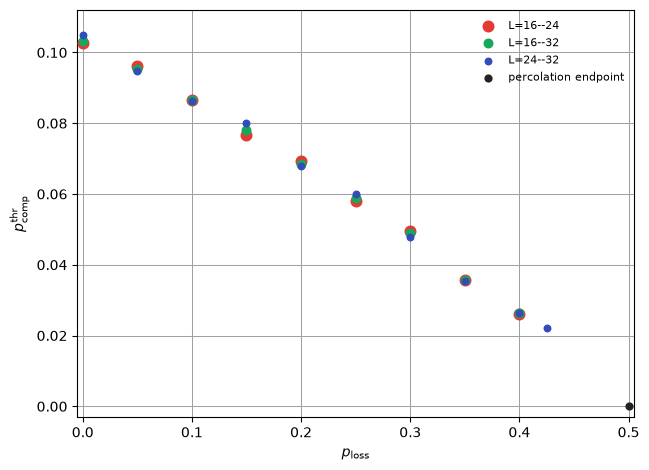

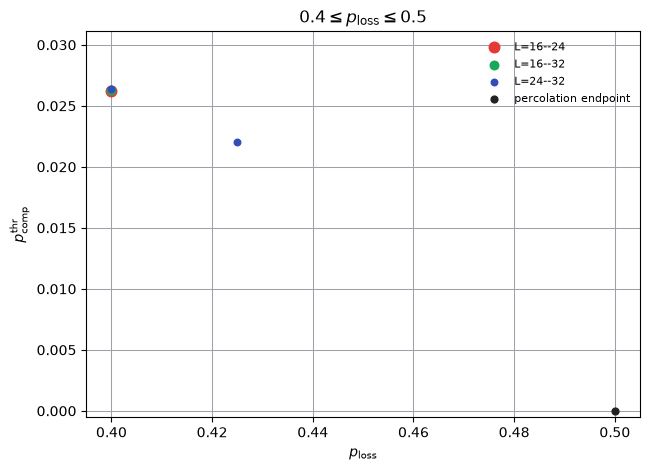

 p_loss  size_pair  p_comp_threshold  inside_sampled_range
  0.000 L=16--L=24          0.102585                  True
  0.000 L=16--L=32          0.103150                  True
  0.000 L=24--L=32          0.104862                  True
  0.050 L=16--L=24          0.096120                  True
  0.050 L=16--L=32          0.095368                  True
  0.050 L=24--L=32          0.094640                  True
  0.100 L=16--L=24          0.086659                  True
  0.100 L=16--L=32          0.086549                  True
  0.100 L=24--L=32          0.086421                  True
  0.150 L=16--L=24          0.076777                  True
  0.150 L=16--L=32          0.077952                  True
  0.150 L=24--L=32          0.080136                  True
  0.200 L=16--L=24          0.069265                  True
  0.200 L=16--L=32          0.068553                  True
  0.200 L=24--L=32          0.067789                  True
  0.250 L=16--L=24          0.058114                  Tr

In [ ]:
# 셀 33: 셀 1~30에서 구현하고 검증한 loss-aware decoder로 Monte Carlo phase diagram을 계산합니다.
# - cell 30의 fast decoder는 reference pipeline과 equivalence check를 통과한 동일 알고리즘입니다.
# - loss sampling, superplaquette, Eq. (1), restored path, physical correction, loss topology, homology를 그대로 사용합니다.
# - L=(16,24,32), 각 (p_loss,L,p_comp)당 5,000 trials를 실행합니다.
# - p_comp 탐색식은 측정 지점만 정하며 threshold 결과에 직접 사용되지 않습니다.
# - threshold는 세 finite-size pair의 실제 p_fail 직선 교차점이며 범위 밖 교차점은 표시하지 않습니다.
# - 각 측정점은 CSV에 저장하므로 셀을 다시 실행하면 완료된 점을 건너뜁니다.

import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


required_exact_names = (
    "ToricLattice",
    "build_fast_loss_aware_decoder_context",
    "run_fast_loss_aware_x_monte_carlo",
)
missing_exact_names = [
    name for name in required_exact_names if name not in globals()
]
if missing_exact_names:
    raise RuntimeError(
        "Run cells 1 through 30 before cell 33. Missing: "
        + ", ".join(missing_exact_names)
    )


def exact_phase_p_comp_grid(p_loss: float) -> tuple[float, ...]:
    """Choose three measurement points; never substitute this guide for data."""
    if p_loss <= 0.4:
        center = max(0.001, 0.103 - 0.154 * p_loss - 0.104 * p_loss**2)
        half_width = 0.008
        lower = max(0.0005, center - half_width)
        upper = min(0.125, center + half_width)
    else:
        distance = (0.5 - p_loss) / 0.1
        center = max(0.00005, 0.025 * distance**2)
        half_width = max(0.00015, 0.60 * center)
        lower = max(0.00002, center - half_width)
        upper = center + half_width
    return tuple(float(value) for value in np.linspace(lower, upper, 3))


def exact_pairwise_crossings(
    sweep_table: pd.DataFrame,
    sizes: tuple[int, ...],
) -> pd.DataFrame:
    """Fit local p_fail lines and return all measured finite-size crossings."""
    crossing_rows = []
    for p_loss, loss_rows in sweep_table.groupby("p_loss", sort=True):
        fit_by_size = {}
        sampled_min = float(loss_rows["p_comp"].min())
        sampled_max = float(loss_rows["p_comp"].max())
        for size in sizes:
            size_rows = loss_rows[loss_rows["L"] == size].sort_values("p_comp")
            if len(size_rows) != 3:
                raise RuntimeError(
                    f"p_loss={p_loss}, L={size} does not have three measurements."
                )
            fit_by_size[size] = np.polyfit(
                size_rows["p_comp"].to_numpy(dtype=float),
                size_rows["p_fail"].to_numpy(dtype=float),
                deg=1,
            )
        for first_index, first in enumerate(sizes):
            for second in sizes[first_index + 1 :]:
                slope_a, intercept_a = fit_by_size[first]
                slope_b, intercept_b = fit_by_size[second]
                slope_difference = slope_a - slope_b
                crossing = (
                    math.nan
                    if math.isclose(slope_difference, 0.0, abs_tol=1e-15)
                    else float((intercept_b - intercept_a) / slope_difference)
                )
                crossing_rows.append(
                    {
                        "p_loss": float(p_loss),
                        "size_pair": f"L={first}--L={second}",
                        "p_comp_threshold": crossing,
                        "inside_sampled_range": bool(
                            math.isfinite(crossing)
                            and sampled_min <= crossing <= sampled_max
                        ),
                    }
                )
    return pd.DataFrame(crossing_rows)


exact_phase_sizes = (16, 24, 32)
exact_phase_loss_values = (
    0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30,
    0.35, 0.40, 0.425, 0.450, 0.475, 0.490,
)
exact_phase_trials_per_point = 5_000
exact_phase_master_seed = 20260803
exact_phase_checkpoint = Path(
    "exact_phase_sweep_L16_24_32_n5000.csv"
)
exact_contexts = {
    size: build_fast_loss_aware_decoder_context(ToricLattice(size))
    for size in exact_phase_sizes
}

checkpoint_columns = (
    "p_loss", "L", "p_comp", "trials", "failures",
    "loss_X_failures", "decoder_X_failures", "p_fail",
    "standard_error", "wilson_ci_low", "wilson_ci_high",
    "Z_loss_unrecoverable", "full_loss_unrecoverable",
)
if exact_phase_checkpoint.exists():
    exact_saved_rows = pd.read_csv(exact_phase_checkpoint)
    missing_columns = set(checkpoint_columns) - set(exact_saved_rows.columns)
    if missing_columns:
        raise RuntimeError(
            "Checkpoint schema mismatch: " + ", ".join(sorted(missing_columns))
        )
else:
    exact_saved_rows = pd.DataFrame(columns=checkpoint_columns)

exact_start = time.perf_counter()
total_points = len(exact_phase_loss_values) * len(exact_phase_sizes) * 3
completed_points = 0
for loss_index, p_loss in enumerate(exact_phase_loss_values):
    p_comp_values = exact_phase_p_comp_grid(p_loss)
    for size_index, size in enumerate(exact_phase_sizes):
        for comp_index, p_comp in enumerate(p_comp_values):
            cached = exact_saved_rows[
                np.isclose(exact_saved_rows["p_loss"].astype(float), p_loss)
                & (exact_saved_rows["L"].astype(int) == size)
                & np.isclose(exact_saved_rows["p_comp"].astype(float), p_comp)
                & (exact_saved_rows["trials"].astype(int) == exact_phase_trials_per_point)
            ]
            completed_points += 1
            if not cached.empty:
                print(
                    f"[{completed_points}/{total_points}] cached "
                    f"p_loss={p_loss:.3f}, L={size}, p_comp={p_comp:.6f}",
                    flush=True,
                )
                continue

            point_start = time.perf_counter()
            point_seed = np.random.SeedSequence(
                [exact_phase_master_seed, loss_index, size_index, comp_index]
            )
            summary = run_fast_loss_aware_x_monte_carlo(
                context=exact_contexts[size],
                p_loss=p_loss,
                p_comp=p_comp,
                num_trials=exact_phase_trials_per_point,
                rng=np.random.default_rng(point_seed),
            )
            failure = summary.logical_failure_estimate
            row = {
                "p_loss": p_loss,
                "L": size,
                "p_comp": p_comp,
                "trials": summary.num_trials,
                "failures": summary.logical_failure_count,
                "loss_X_failures": summary.loss_logical_x_count,
                "decoder_X_failures": summary.decoder_logical_x_count,
                "p_fail": failure.rate,
                "standard_error": math.sqrt(
                    failure.rate * (1.0 - failure.rate) / summary.num_trials
                ),
                "wilson_ci_low": failure.ci_low,
                "wilson_ci_high": failure.ci_high,
                "Z_loss_unrecoverable": summary.z_loss_unrecoverable_count,
                "full_loss_unrecoverable": summary.full_loss_unrecoverable_count,
            }
            if exact_saved_rows.empty:
                exact_saved_rows = pd.DataFrame([row])
            else:
                exact_saved_rows = pd.concat(
                    [exact_saved_rows, pd.DataFrame([row])], ignore_index=True
                )
            exact_saved_rows.to_csv(exact_phase_checkpoint, index=False)
            print(
                f"[{completed_points}/{total_points}] completed "
                f"p_loss={p_loss:.3f}, L={size}, p_comp={p_comp:.6f}: "
                f"p_fail={failure.rate:.4f} in "
                f"{time.perf_counter() - point_start:.1f}s",
                flush=True,
            )

requested_rows = []
for p_loss in exact_phase_loss_values:
    for size in exact_phase_sizes:
        for p_comp in exact_phase_p_comp_grid(p_loss):
            match = exact_saved_rows[
                np.isclose(exact_saved_rows["p_loss"].astype(float), p_loss)
                & (exact_saved_rows["L"].astype(int) == size)
                & np.isclose(exact_saved_rows["p_comp"].astype(float), p_comp)
                & (exact_saved_rows["trials"].astype(int) == exact_phase_trials_per_point)
            ]
            if len(match) != 1:
                raise RuntimeError("Checkpoint contains a missing or duplicate point.")
            requested_rows.append(match.iloc[0].to_dict())

exact_phase_sweep_table = pd.DataFrame(requested_rows)
exact_phase_crossing_table = exact_pairwise_crossings(
    exact_phase_sweep_table, exact_phase_sizes
)
exact_valid_crossings = exact_phase_crossing_table[
    exact_phase_crossing_table["inside_sampled_range"]
    & np.isfinite(exact_phase_crossing_table["p_comp_threshold"])
].copy()

paper_pair_styles = {
    "L=16--L=24": ("#e53935", 58, "L=16--24"),
    "L=16--L=32": ("#18a85b", 38, "L=16--32"),
    "L=24--L=32": ("#324db7", 22, "L=24--32"),
}


def plot_exact_phase_points(axis, crossing_rows, zoom=False):
    """Draw measured crossings with the marker hierarchy used in paper Fig. 4."""
    for pair, (color, marker_size, label) in paper_pair_styles.items():
        rows = crossing_rows[crossing_rows["size_pair"] == pair]
        axis.scatter(
            rows["p_loss"], rows["p_comp_threshold"],
            color=color, s=marker_size, label=label, zorder=3,
        )
    axis.scatter([0.5], [0.0], color="#222222", s=24,
                 label="percolation endpoint", zorder=4)
    axis.set_xlabel(r"$p_{\mathrm{loss}}$")
    axis.set_ylabel(r"$p_{\mathrm{comp}}^{\mathrm{thr}}$")
    axis.grid(True, color="#9da2a8", linewidth=0.75)
    axis.legend(frameon=False, fontsize=8)
    if zoom:
        high_values = crossing_rows.loc[
            crossing_rows["p_loss"] >= 0.4, "p_comp_threshold"
        ].to_numpy(dtype=float)
        zoom_top = (
            max(0.005, 1.18 * float(np.max(high_values)))
            if high_values.size
            else 0.03
        )
        axis.set_xlim(0.395, 0.505)
        axis.set_ylim(-0.0005, zoom_top)
        axis.set_title(r"$0.4 \leq p_{\mathrm{loss}} \leq 0.5$")
    else:
        axis.set_xlim(-0.005, 0.505)
        axis.set_ylim(-0.003, 0.112)


full_figure, full_axis = plt.subplots(figsize=(6.6, 4.8))
plot_exact_phase_points(full_axis, exact_valid_crossings)
full_figure.tight_layout()
plt.show()

zoom_figure, zoom_axis = plt.subplots(figsize=(6.6, 4.8))
plot_exact_phase_points(zoom_axis, exact_valid_crossings, zoom=True)
zoom_figure.tight_layout()
plt.show()

invalid_crossings = exact_phase_crossing_table[
    ~exact_phase_crossing_table["inside_sampled_range"]
]
print(exact_phase_crossing_table.to_string(index=False))
if not invalid_crossings.empty:
    print(
        f"Not plotted: {len(invalid_crossings)} crossings outside their "
        "measured p_comp windows. No fallback value was substituted."
    )
print(
    f"Exact-decoder phase sweep elapsed: "
    f"{(time.perf_counter() - exact_start) / 3600.0:.2f} hours."
)
